# Deteksi Hoaks IndoBERT + BERTopic (Final V4 DBCS)

Notebook ini menjalankan klasifikasi hoax berbasis IndoBERT dan analisis topik berbasis BERTopic. Pipeline IndoBERT dipertahankan sebagai classifier utama, sedangkan BERTopic berjalan setelah training untuk membaca struktur topik pada corpus training pra-oversampling. Evaluasi tambahan mencakup DBCV, coherence, outlier rate, c-TF-IDF, keyword coverage, topic exclusivity, category exclusivity, dan ringkasan angka akhir.


In [1]:
# ================== SEL 1 -- Instalasi Library dan Import Dependensi ==================
# Menginstal library yang diperlukan untuk training model IndoBERT dan analisis hoax.
# - KaggleHub: Download dataset dari Kaggle
# - Transformers: Framework untuk model BERT
# - PyTorch: Deep learning framework
# - Scikit-learn: Utility untuk evaluasi model
# Setelah instalasi selesai, semua library di-import dan versi ditampilkan untuk verifikasi.
# =======================================================================================
!pip install -q kagglehub transformers datasets accelerate sentencepiece scikit-learn seaborn

import gc
import json as _json
import os
import random
import shutil
import warnings
from pathlib import Path
from dataclasses import dataclass
from typing import Any, Dict, List, Tuple

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_curve,
    auc,
    precision_score,
    recall_score,
)

import torch
import transformers
import kagglehub
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    set_seed,
)

print("Semua library berhasil di-import.")
print(f"   PyTorch       : {torch.__version__}")
print(f"   Transformers  : {transformers.__version__}")
print(f"   GPU tersedia  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"   GPU           : {torch.cuda.get_device_name(0)}")
    print(f"   VRAM total    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Semua library berhasil di-import.
   PyTorch       : 2.10.0+cu128
   Transformers  : 5.0.0
   GPU tersedia  : True
   GPU           : Tesla T4
   VRAM total    : 15.6 GB


In [2]:
# ================== SEL 2 -- Instalasi Dependensi BERTopic ==================
# Menginstal library untuk Topic Modeling yang akan dijalankan setelah training selesai.
# BERTopic adalah tahap post-training yang tidak mengubah model classifier IndoBERT.
# =================================================================================
!pip install -q bertopic sentence-transformers umap-learn hdbscan gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 70.6 MB/s eta 0:00:00


**Catatan BERTopic:** BERTopic dijalankan setelah training classifier IndoBERT selesai. Tahap ini tidak mengubah bobot model, tokenizer, split data, threshold classifier, atau metrik evaluasi IndoBERT.


In [3]:
# ================== SEL 3 -- Konfigurasi Hyperparameter Training ==================
# Mendefinisikan semua parameter training untuk IndoBERT dan pengaturan CUDA.
# Hyperparameter:
#   - train_batch_size = 96 (optimal untuk GPU 15GB)
#   - eval_batch_size = 384 (evaluasi cepat)
#   - max_length = 256 (sesuai panjang teks dataset berita)
#   - learning_rate = 2e-5 (standar untuk fine-tuning BERT)
# Pengaturan CUDA membantu meningkatkan reproducibility antar-run.
# ====================================================================================
@dataclass
class Config:
    # Path Dataset
    path_cnn    : str   = "/content/dataset/CNN.csv"
    path_detik  : str   = "/content/dataset/Detik.csv"
    path_kompas : str   = "/content/dataset/Kompas.csv"
    path_tbh    : str   = "/content/dataset/TurnBackHoax.csv"
    # Model
    model_name       : str   = "indolem/indobert-base-uncased"
    # Hyperparameter Training
    max_length       : int   = 256    # Max token length
    train_batch_size : int   = 96     # Optimal untuk GPU 15GB
    eval_batch_size  : int   = 384    # Evaluasi cepat
    grad_accumulation: int   = 2
    learning_rate    : float = 2e-5
    weight_decay     : float = 0.01
    num_epochs       : int   = 3
    seed             : int   = 42
    # Balancing
    balance_minority : bool  = True
    # Threshold inferensi default
    threshold_default: float = 0.5
    # Output
    output_dir       : str   = "indobert_hoax_model_v3"

cfg = Config()
THRESHOLD_DEFAULT = float(cfg.threshold_default)
set_seed(cfg.seed)

# Membantu meningkatkan reproducibility pada operasi CUDA
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device aktif           : {device}")
print(f"cudnn.deterministic    : {torch.backends.cudnn.deterministic}")
print(f"cudnn.benchmark        : {torch.backends.cudnn.benchmark}")
print(f"train_batch_size       : {cfg.train_batch_size}")
print(f"eval_batch_size        : {cfg.eval_batch_size}")
print(f"Efektif batch size     : {cfg.train_batch_size * cfg.grad_accumulation}")
print(f"max_length             : {cfg.max_length}")
print(f"threshold_default      : {THRESHOLD_DEFAULT:.2f}")

Device aktif           : cuda
cudnn.deterministic    : True
cudnn.benchmark        : False
train_batch_size       : 96
eval_batch_size        : 384
Efektif batch size     : 192
max_length             : 256
threshold_default      : 0.50


In [4]:
# ================== SEL 4 -- Konfigurasi BERTopic (Post-Training) ==================
# Parameter Topic Modeling yang dijalankan setelah training classifier selesai.
# Konfigurasi ini tidak mengubah training, bobot, tokenizer, atau evaluasi IndoBERT.
# Guided topic modeling saat ini dinonaktifkan; kategori dipakai pada evaluasi/pelabelan topik.
# =======================================================================================
AKTIFKAN_BERTOPIC        = True
AKTIFKAN_UNGGAH_BERTOPIC = False
AKTIFKAN_GUIDED          = False  # Label kategori tetap dihitung pada evaluasi, bukan dipaksa saat fit

DIR_OUTPUT_BERTOPIC      = "/content/bertopic_model_v3"
MODEL_EMBEDDING_BERTOPIC = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
UKURAN_BATCH_EMBED       = 32
UKURAN_BATCH_EKSTRAK     = 128
MAKS_DOKUMEN_BERTOPIC    = None
REPO_TOPIC_HF            = "fjrmhri/deteksi_hoaks_bertopic"
BERTOPIC_HITUNG_PROB     = True
NR_TOPIK                 = 80
BERTOPIC_UMAP_N_NEIGHBORS = 12
BERTOPIC_UMAP_N_COMPONENTS = 5
BERTOPIC_UMAP_MIN_DIST = 0.0
BERTOPIC_HDBSCAN_MIN_CLUSTER_SIZE = 12
BERTOPIC_HDBSCAN_MIN_SAMPLES = 2
BERTOPIC_HDBSCAN_SELECTION = "leaf"
BERTOPIC_VECTORIZER_MIN_DF = 3
BERTOPIC_VECTORIZER_MAX_DF = 0.75
BERTOPIC_REDUCE_OUTLIERS = True
BERTOPIC_REDUCE_OUTLIERS_THRESHOLD = 0.10
BERTOPIC_AKTIFKAN_MERGE_MANUAL = False

SEED_BERTOPIC = cfg.seed

print(f"BERTopic aktif         : {AKTIFKAN_BERTOPIC}")
print(f"Guided Topic Modeling  : {AKTIFKAN_GUIDED}")
print(f"Hitung probabilitas    : {BERTOPIC_HITUNG_PROB}")
print(f"nr_topics              : {NR_TOPIK}")
print(f"Output dir             : {DIR_OUTPUT_BERTOPIC}")

BERTopic aktif         : True
Guided Topic Modeling  : False
Hitung probabilitas    : True
nr_topics              : 80
Output dir             : /content/bertopic_model_v3


## Kategori Tematik dan `seed_topic_list`

Daftar kata kunci per kategori tetap disiapkan sebagai sumber label/evaluasi topik. Pada konfigurasi terbaru, guided topic modeling dimatikan (`AKTIFKAN_GUIDED=False`), sehingga daftar ini tidak dipaksakan saat fit BERTopic.


In [5]:
# ================== SEL 5 -- Definisi Kategori Tematik (Sinkronisasi) ==================
# Mendefinisikan daftar kategori berita dan kata kunci yang terkait dengan setiap topik.
# Data ini bersumber dari backend/app.py (PETA_KATEGORI) untuk menjaga konsistensi.
# Kategori dipakai untuk label/evaluasi topik; seed_topic_list hanya digunakan jika AKTIFKAN_GUIDED=True.
# ==========================================================================================

PETA_KATEGORI_SHARED = [
    ("Kriminal & Hukum", {
        "polisi", "tersangka", "pengadilan", "hukum", "penjara", "korupsi",
        "kpk", "pembunuhan", "penipuan", "sidang", "vonis", "kriminal",
        "penyidikan", "jaksa", "hakim", "ditangkap", "ditahan", "terdakwa",
        "dakwaan", "kejaksaan", "mahkamah", "peradilan", "pidana", "perdata",
        "polri", "rutan", "lapas", "napi", "tahanan", "bui", "sel",
        "persidangan", "putusan", "hukuman", "denda", "banding", "kasasi",
        "penggeledahan", "penyitaan", "rekonstruksi", "otopsi", "visum",
        "tipikor", "suap", "gratifikasi", "pencucian", "pemalsuan",
        "penganiayaan", "pencurian", "perampokan", "narkoba", "narkotika",
        "pelecehan", "pemerkosaan", "kejahatan", "pelaku", "korban kriminal",
    }),
    ("Politik", {
        "pemilu", "pilkada", "dpr", "partai", "kampanye", "bawaslu", "kpu",
        "pilpres", "caleg", "koalisi", "oposisi", "legislasi", "debat",
        "konstitusi", "suara", "demokrat", "golkar", "pdip", "gerindra",
        "pks", "dpd", "mpr", "fraksi", "legislatif", "senator",
        "dprd", "pilwalkot", "pilgub", "pilbup", "capres", "cawapres",
        "paslon", "petahana", "tim sukses", "quick count", "real count",
        "rekap suara", "money politics", "politik uang", "black campaign",
        "kampanye hitam", "hoaks politik", "propaganda", "agitasi",
        "referendum", "demokrasi", "oligarki", "populisme", "nasionalisme",
        "pkb", "ppp", "pan", "nasdem", "hanura", "perindo", "psi",
        "pemilih", "suara rakyat", "kebijakan publik", "anggaran negara",
    }),
    ("Nasional & Pemerintahan", {
        "kementerian", "menteri", "kebijakan", "asn", "pns", "pemerintah",
        "presiden", "ibukota", "otonomi", "daerah", "regulasi", "proyek",
        "pembangunan", "gubernur", "bupati", "walikota", "dprd", "pemda",
        "anggaran", "apbn", "apbd", "perpres", "perda", "kabinet",
        "wapres", "jokowi", "prabowo",
        "sekretariat", "lembaga", "badan", "komisi", "dirjen", "direktorat",
        "keppres", "inpres", "pp", "uu", "ruu", "peraturan", "undang-undang",
        "ibu kota nusantara", "ikn", "brin", "bpk", "bpn", "bps",
        "kemendag", "kemenhub", "kemenkes", "kemendikbud", "kementan",
        "aparatur", "birokrasi", "reformasi birokrasi", "e-government",
        "pengadaan", "tender", "proyek nasional", "infrastruktur nasional",
        "bansos", "bantuan sosial", "subsidi", "blt", "pkh",
    }),
    ("Ekonomi & Bisnis", {
        "ekonomi", "saham", "investasi", "inflasi", "bank", "keuangan",
        "pajak", "ihsg", "umkm", "harga", "pasar", "ekspor", "impor",
        "startup", "bisnis", "perdagangan", "rupiah", "dolar", "kurs",
        "bank indonesia", "ojk", "bumn", "swasta", "perusahaan", "modal", "aset",
        "defisit", "surplus", "neraca", "pdb", "gdp",
        "inflasi", "deflasi", "resesi", "stagflasi", "suku bunga",
        "kredit", "pinjaman", "utang", "obligasi", "saham", "dividen",
        "bursa efek", "bei", "bursa", "trading", "trader", "stock market",
        "market cap", "kapitalisasi pasar", "pasar modal", "mata uang",
        "pertumbuhan ekonomi", "kemiskinan", "pengangguran", "lapangan kerja",
        "upah", "gaji", "phk", "tenaga kerja", "buruh", "pekerja",
        "industri", "manufaktur", "produksi", "ekspansi", "merger",
        "akuisisi", "ipo", "go public", "e-commerce", "marketplace",
        "fintech", "kripto", "bitcoin", "blockchain", "digital economy",
        "harga bahan pokok", "sembako", "beras", "minyak goreng", "bbm",
    }),
    ("Kesehatan", {
        "kesehatan", "penyakit", "dokter", "virus", "vaksin",
        "obat", "bpjs", "pandemi", "medis", "gejala", "terapi", "pasien",
        "klinis", "covid", "kemenkes", "epidemi", "wabah", "imunisasi",
        "apotek", "farmasi", "faskes", "puskesmas", "nakes",
        "rumah sakit", "rs", "poliklinik", "igd", "icu", "rawat inap",
        "rawat jalan", "operasi", "bedah", "diagnosa", "resep",
        "kanker", "diabetes", "hipertensi", "jantung", "stroke",
        "dbd", "malaria", "tbc", "hiv", "aids", "hepatitis",
        "mpox", "cacar", "flu", "demam", "batuk", "sesak napas",
        "lockdown", "karantina", "isolasi", "klaster", "herd immunity",
        "booster", "dosis", "suntik", "vaksinasi", "pfizer", "sinovac",
        "herbal", "jamu", "suplemen", "vitamin", "nutrisi", "gizi",
        "hamil", "kehamilan", "bayi", "ibu hamil", "melahirkan", "persalinan",
        "kandungan", "janin", "rahim", "usg", "ultrasonografi", "prenatal",
        "postnatal", "antenatal", "neonatal", "pregnancy", "pregnant",
        "childbirth", "delivery", "maternal", "maternity", "obgyn", "obstetri",
        "stunting", "gizi buruk", "obesitas", "kesehatan jiwa",
    }),
    ("Teknologi & Sains", {
        "teknologi", "internet", "aplikasi", "digital", "siber", "hacker",
        "inovasi", "satelit", "algoritma", "data", "ai", "kecerdasan",
        "buatan", "software", "hardware", "smartphone", "kominfo", "server",
        "cloud", "robot",
        "artificial intelligence", "machine learning", "deep learning",
        "big data", "iot", "internet of things", "5g", "metaverse",
        "virtual reality", "vr", "augmented reality", "ar",
        "keamanan siber", "cybersecurity", "ransomware", "phishing",
        "kebocoran data", "privasi digital", "enkripsi", "firewall",
        "coding", "programming", "developer", "startup teknologi",
        "komputasi", "prosesor", "chip", "semikonduktor",
        "drone", "luar angkasa", "antariksa", "space", "space science",
        "planet", "bumi", "matahari", "bulan", "bintang", "tata surya",
        "solar system", "astronomi", "astronomy", "nasa", "roket", "wahana",
        "lapan", "brin",
        "riset", "penelitian", "jurnal", "ilmiah", "laboratorium",
    }),
    ("Bencana & Cuaca", {
        "gempa", "banjir", "cuaca", "bmkg", "tsunami", "longsor", "erupsi",
        "badai", "evakuasi", "korban", "mitigasi", "iklim", "hujan", "angin",
        "kebakaran", "bencana", "bnpb", "bpbd", "kekeringan", "rob", "topan",
        "bencana alam", "force majeure", "tanah bergerak", "abrasi",
        "angin puting beliung", "tornado", "siklon", "hujan es",
        "banjir bandang", "banjir rob", "banjir lahar", "awan panas",
        "gunung berapi", "vulkanik", "aktivitas seismik", "magnitudo",
        "skala richter", "peringatan dini", "sirine", "tsunami warning",
        "pengungsian", "shelter", "posko", "bantuan bencana",
        "cuaca ekstrem", "el nino", "la nina", "perubahan iklim",
    }),
    ("Olahraga", {
        "olahraga", "sepakbola", "futsal", "basket", "bulutangkis", "atlet",
        "turnamen", "medali", "piala", "fifa", "aff", "liga", "stadion",
        "pertandingan", "klub", "pssi", "pbsi", "olimpiade",
        "voli", "tenis", "badminton", "pemain", "pelatih",
        "sea games", "asian games", "world cup", "euro", "copa",
        "premier league", "serie a", "la liga", "bundesliga", "liga 1",
        "timnas", "persib", "persija", "arema", "bali united",
        "gol", "kartu merah", "kartu kuning", "offside", "penalti",
        "skor", "klasemen", "degradasi", "promosi", "transfer pemain",
        "sprint", "maraton", "lari", "renang", "senam", "tinju", "mma",
        "e-sports", "gaming kompetitif", "esports",
    }),
    ("Keamanan & Pertahanan", {
        "militer", "tni", "angkatan darat", "angkatan laut", "angkatan udara",
        "tentara", "prajurit", "pasukan", "batalyon", "komando",
        "pertahanan", "senjata", "amunisi", "peluru", "meriam", "tank",
        "pesawat tempur", "kapal perang", "kapal selam", "frigate",
        "operasi militer", "latihan militer", "manuver", "gelar pasukan",
        "konflik bersenjata", "perang saudara", "gerilya", "insurgensi",
        "teror", "teroris", "bom", "ledakan", "serangan", "penembakan",
        "separatis", "papua", "kkb", "opm", "kelompok bersenjata",
        "natuna", "laut china selatan", "kedaulatan wilayah", "perbatasan",
        "pertahanan nasional", "kemenhan", "mabes tni", "panglima",
        "densus 88", "brimob", "kopassus", "kostrad", "marinir",
        "intel", "intelijen", "bais", "bnpt", "deradikalisasi",
        "pangkalan militer", "alutsista", "alutsista baru",
    }),
    ("Internasional", {
        "diplomasi", "perang", "konflik", "pbb", "nato", "geopolitik",
        "internasional", "sanksi", "asean", "g20", "kedutaan", "wna", "visa",
        "rusia", "russia", "ukraina", "ukraine", "amerika", "amerika serikat", "usa",
        "china", "cina", "tiongkok", "taiwan", "hongkong",
        "eropa", "uni eropa", "inggris", "jerman", "perancis", "italia",
        "jepang", "korea selatan", "korea utara", "india", "pakistan",
        "iran", "arab saudi", "israel", "palestina", "gaza", "lebanon",
        "suriah", "irak", "afghanistan", "turki", "mesir", "nigeria",
        "australia", "kanada", "brazil", "meksiko",
        "hubungan bilateral", "hubungan multilateral", "perjanjian",
        "kerja sama internasional", "kunjungan kenegaraan", "state visit",
        "konferensi internasional", "summit", "ktt",
        "embargo", "blokade", "resolusi pbb", "dewan keamanan pbb",
        "who", "imf", "world bank", "wto", "apec",
        "pengungsi", "imigran", "asylum", "deportasi",
        "hak asasi manusia", "ham internasional", "amnesty international",
        "mata-mata", "espionase", "perang proxy", "perang dagang",
    }),
    ("Pendidikan", {
        "sekolah", "guru", "siswa", "mahasiswa", "kampus", "universitas",
        "beasiswa", "kurikulum", "ujian", "akademik", "riset",
        "kemendikbud", "snbp", "snbt", "sma", "smp", "sekolah dasar", "dosen",
        "rektor", "fakultas",
        "pelajar", "murid", "pengajar", "pendidik", "tenaga pendidik",
        "perguruan tinggi", "prodi", "jurusan", "semester",
        "ipk", "skripsi", "tesis", "disertasi", "wisuda", "ijazah",
        "akreditasi", "bsnp", "kemdikbud", "dikti",
        "un", "ujian nasional", "seleksi masuk", "snmptn", "sbmptn",
        "ppdb", "penerimaan peserta didik", "zonasi", "jalur prestasi",
        "literasi", "numerasi", "kompetensi", "sertifikasi guru",
        "tunjangan guru", "p3k", "cpns guru",
        "bimbel", "les", "kursus", "pelatihan", "vokasi", "smk",
        "pendidikan karakter", "anti bullying", "perundungan",
    }),
    ("Transportasi & Infrastruktur", {
        "jalan", "tol", "kereta", "bandara", "pelabuhan", "transportasi",
        "kendaraan", "mrt", "lrt", "bus", "pesawat", "kapal",
        "terminal", "stasiun", "garuda", "kemenhub",
        "krl", "kereta cepat", "whoosh", "kai", "damri", "transjakarta",
        "ojek online", "gojek", "grab", "taksi", "angkutan umum",
        "jalan tol", "tol trans jawa", "tol trans sumatera",
        "jembatan", "flyover", "underpass", "terowongan",
        "bandara soetta", "bandara internasional", "runway",
        "maskapai", "lion air", "batik air", "citilink", "airasia",
        "kapal laut", "pelni", "asdp", "ferry",
        "kecelakaan lalu lintas", "kemacetan", "tilang",
        "sim", "stnk", "kir", "emisi kendaraan",
        "bbm", "spbu", "subsidi bbm", "pertamax", "pertalite",
    }),
    ("Lingkungan & Energi", {
        "lingkungan", "energi", "listrik", "minyak", "gas", "emisi",
        "polusi", "tambang", "pln", "pertamina", "karbon",
        "hutan", "deforestasi", "sawit", "sampah",
        "perubahan iklim", "climate change", "pemanasan global",
        "emisi karbon", "co2", "gas rumah kaca", "net zero",
        "energi terbarukan", "panel surya", "turbin angin", "pltm",
        "pltu", "pltn", "nuklir", "geothermal", "panas bumi",
        "batu bara", "batubara", "gas alam", "lng", "lpg",
        "illegal logging", "pembalakan liar", "kebakaran hutan",
        "asap", "kabut asap", "karhutla",
        "pencemaran", "polusi udara", "polusi air", "polusi tanah",
        "limbah", "limbah industri", "limbah b3", "sampah plastik",
        "daur ulang", "zero waste", "bank sampah",
        "konservasi", "satwa liar", "biodiversitas", "ekosistem",
        "mangrove", "terumbu karang", "laut bersih",
        "tambang nikel", "tambang emas", "tambang batu bara",
    }),
    ("Hiburan & Gaya Hidup", {
        "artis", "film", "musik", "konser", "selebritas", "bioskop", "drama",
        "viral", "sinetron", "festival", "influencer", "lifestyle", "seleb",
        "youtube", "instagram", "tiktok", "kuliner", "wisata",
        "aktor", "aktris", "penyanyi", "band", "idol", "kpop", "bts",
        "blackpink", "boyband", "girlband", "anime", "manga", "marvel",
        "dc", "dc comics", "batman", "joker", "superhero", "movie", "cinema",
        "streaming", "netflix", "disney", "spotify", "podcast",
        "game", "gaming", "esports", "twitch",
        "fashion", "mode", "tren", "beauty", "skincare", "makeup",
        "diet", "fitness", "gym", "olahraga gaya hidup",
        "restoran", "kafe", "cafe", "food vlogger", "street food",
        "destinasi wisata", "hotel", "resort", "villa",
        "selebgram", "youtuber", "content creator", "buzzer",
        "gosip", "scandal", "perceraian", "pernikahan seleb",
        "award", "festival film", "box office",
    }),
]

# Transformasi ke format BERTopic: List[List[str]]
kategori_nama_list = [name for name, _ in PETA_KATEGORI_SHARED]
daftar_tema_utama = [list(keywords) for _, keywords in PETA_KATEGORI_SHARED]

if AKTIFKAN_GUIDED:
    print(f"  [V3] seed_topic_list aktif (dari PETA_KATEGORI_SHARED): {len(daftar_tema_utama)} kategori")
    for i, (nama, tema) in enumerate(zip(kategori_nama_list, daftar_tema_utama), 1):
        print(f"    {i:02d}. {nama:35s} ({len(tema):2d} keyword)")
else:
    print("  [V3] AKTIFKAN_GUIDED=False — seed_topic_list tidak akan digunakan")

  [V3] AKTIFKAN_GUIDED=False — seed_topic_list tidak akan digunakan


In [6]:
# ================== SEL 6 -- Unduh Dataset dari Kaggle ==================
# Mengunduh dataset berita dari Kaggle menggunakan API KaggleHub.
# Dataset Kaggle: fjrmhri/dataset-skripsi, terdiri dari 4 file CSV:
#   1. CNN: Berita dari CNN Indonesia (label: non-hoax)
#   2. Detik: Berita dari Detik (label: non-hoax)
#   3. Kompas: Berita dari Kompas (label: non-hoax)
#   4. Turn Back Hoax: Berita hoax terverifikasi (label: hoax)
# File-file yang sudah diunduh disalin ke direktori /content/dataset.
# ===========================================================================
kaggle_cache_dir = kagglehub.dataset_download("fjrmhri/dataset-skripsi")
print("Path dataset (cache kagglehub):", kaggle_cache_dir)

direktori_dataset = Path("/content/dataset")
direktori_dataset.mkdir(parents=True, exist_ok=True)

pemetaan_berkas = {
    "CNN.csv":          ["CNN.csv", "dataset/CNN.csv"],
    "Detik.csv":        ["Detik.csv", "dataset/Detik.csv"],
    "Kompas.csv":       ["Kompas.csv", "dataset/Kompas.csv"],
    "TurnBackHoax.csv": ["TurnBackHoax.csv", "dataset/TurnBackHoax.csv"],
}

for nama_tujuan, kandidat_path in pemetaan_berkas.items():
    ditemukan = None
    for kandidat in kandidat_path:
        path_kandidat = Path(kaggle_cache_dir) / kandidat  # Cari berkas di cache Kaggle
        if path_kandidat.exists():
            ditemukan = path_kandidat
            break
    if ditemukan is None:
        raise FileNotFoundError(f"Berkas tidak ditemukan: {nama_tujuan}")
    shutil.copy(ditemukan, direktori_dataset / nama_tujuan)  # Salin ke /content/dataset
    print(f"  Disalin: {ditemukan.name} -> {direktori_dataset / nama_tujuan}")

print("\nDataset siap di /content/dataset")

Using Colab cache for faster access to the 'dataset-skripsi' dataset.
Path dataset (cache kagglehub): /kaggle/input/dataset-skripsi
  Disalin: CNN.csv -> /content/dataset/CNN.csv
  Disalin: Detik.csv -> /content/dataset/Detik.csv
  Disalin: Kompas.csv -> /content/dataset/Kompas.csv
  Disalin: TurnBackHoax.csv -> /content/dataset/TurnBackHoax.csv

Dataset siap di /content/dataset


In [7]:
# ================== SEL 7 -- Pemuatan Data dari File CSV ==================
# Membaca semua dataset CSV dan menggabungkannya menjadi satu DataFrame.
# Proses:
#   1. Membaca setiap file CSV menggunakan muat_satu_dataset()
#   2. Memastikan semua kolom yang diperlukan ada (dengan value default jika kosong)
#   3. Menambahkan kolom "source" untuk melacak asal data (cnn, detik, kompas, turnbackhoax)
#   4. Menggabungkan semua dataset dengan pd.concat()
# Output: DataFrame dengan kolom standar dan total baris dataset mentah.
# ===========================================================================
KOLOM_DASAR = [
    "url", "judul", "tanggal", "isi_berita",
    "Narasi", "Clean Narasi", "hoax", "summary",
]


def muat_satu_dataset(path: str, nama_sumber: str) -> pd.DataFrame:
    if not os.path.exists(path):
        raise FileNotFoundError(f"File tidak ditemukan: {path}")
    print(f"\nMembaca: {path}  (sumber={nama_sumber})")
    df = pd.read_csv(path)
    print("  Kolom tersedia:", list(df.columns))
    for kol in KOLOM_DASAR:
        if kol not in df.columns:
            df[kol] = "" if kol != "hoax" else np.nan
    df = df[KOLOM_DASAR].copy()
    df["source"] = nama_sumber
    return df


def muat_semua_dataset(cfg: Config) -> pd.DataFrame:
    kumpulan: List[pd.DataFrame] = []
    kumpulan.append(muat_satu_dataset(cfg.path_cnn,    "cnn"))
    kumpulan.append(muat_satu_dataset(cfg.path_detik,  "detik"))
    kumpulan.append(muat_satu_dataset(cfg.path_kompas, "kompas"))
    kumpulan.append(muat_satu_dataset(cfg.path_tbh,    "turnbackhoax"))
    df_gabung = pd.concat(kumpulan, ignore_index=True)
    print(f"\nTotal baris (mentah): {len(df_gabung):,}")
    return df_gabung

In [8]:
# ================== SEL 8 -- Pra-pemrosesan Data dan Pelabelan ==================
# Membersihkan dataset dari baris yang tidak lengkap dan tidak valid.
# Proses:
#   1. Memilih kolom teks terbaik dengan prioritas: Clean Narasi → Narasi → isi_berita → summary → judul
#   2. Menghapus baris tanpa teks
#   3. Mengkonversi label hoax ke format numerik (0=non-hoax, 1=hoax)
#   4. Mengisi label kosong berdasarkan sumber: CNN/Detik/Kompas=non-hoax, TurnBackHoax=hoax
#   5. Menghapus baris dengan label di luar {0,1} dan duplikat berdasarkan (text, label)
#   6. Menghapus teks dengan label konflik dan mencatat potensi bias source-label
# Output: DataFrame bersih siap untuk pembagian train/val/test.
# ===================================================================================

def bangun_dataframe_training(df_mentah: pd.DataFrame) -> pd.DataFrame:
    df = df_mentah.copy()

    def pilih_teks(baris):
        # Prioritas: Clean Narasi -> Narasi -> isi_berita -> summary -> judul
        for kol in ["Clean Narasi", "Narasi", "isi_berita", "summary", "judul"]:
            nilai = baris.get(kol, "")
            if isinstance(nilai, str) and nilai.strip():
                return nilai.strip()
        return ""

    df["text"] = df.apply(pilih_teks, axis=1).astype(str).str.strip()

    n = len(df)
    df = df[df["text"] != ""].reset_index(drop=True)
    print(f"Baris tanpa teks dibuang       : {n - len(df):,}")

    df["hoax_num"] = pd.to_numeric(df["hoax"], errors="coerce")
    mask_nan = df["hoax_num"].isna()
    df.loc[(df["source"].isin(["cnn","detik","kompas"])) & mask_nan, "hoax_num"] = 0
    df.loc[(df["source"] == "turnbackhoax") & mask_nan, "hoax_num"] = 1

    n = len(df)
    df = df[df["hoax_num"].isin([0, 1])].reset_index(drop=True)
    print(f"Baris label NaN dibuang        : {n - len(df):,}")

    df["label"] = df["hoax_num"].astype(int)
    df = df.drop(columns=["hoax_num"])

    n = len(df)
    df = df.drop_duplicates(subset=["text", "label"])
    print(f"Duplikat (text+label) dibuang  : {n - len(df):,}")

    # Hapus teks dengan label konflik
    unik_per_label = df.groupby("text")["label"].nunique()
    teks_konflik   = unik_per_label[unik_per_label > 1].index
    n = len(df)
    df = df[~df["text"].isin(teks_konflik)].reset_index(drop=True)
    print(f"Teks label-konflik dibuang     : {n - len(df):,} baris "
          f"({len(teks_konflik):,} teks unik)")

    print(f"\nTotal baris bersih: {len(df):,}")
    print(df["label"].value_counts().to_string())
    print(df.groupby("source")["label"].value_counts().unstack(fill_value=0).to_string())
    return df

In [9]:
# ================== SEL 9 -- Pembagian Data & Penyeimbangan Kelas ==================
# Membagi dataset menjadi train, validation, dan test menggunakan stratified split.
# Juga melakukan oversampling pada kelas minoritas di train set jika balance_minority=True.
# Proses:
#   1. Stratified split 70:30 untuk train dan temp (val + test)
#   2. Stratified split 50:50 pada temp untuk val dan test masing-masing 15%
#   3. Oversampling pada kelas yang lebih sedikit di training set
# Stratification memastikan distribusi label yang seimbang di setiap split.
# =======================================================================================
def bagi_data_stratified(df: pd.DataFrame, seed: int = 42
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    train_df, temp_df = train_test_split(
        df, test_size=0.30, stratify=df["label"], random_state=seed)
    val_df, test_df = train_test_split(
        temp_df, test_size=0.50, stratify=temp_df["label"], random_state=seed)
    print(f"  Train : {len(train_df):,} | Val : {len(val_df):,} | Test : {len(test_df):,}")
    return (train_df.reset_index(drop=True),
            val_df.reset_index(drop=True),
            test_df.reset_index(drop=True))


def seimbangkan_kelas_minoritas(train_df: pd.DataFrame, seed: int = 42) -> pd.DataFrame:
    jumlah = train_df["label"].value_counts()
    print("Distribusi TRAIN sebelum balancing:"); print(jumlah.to_string())
    if len(jumlah) != 2:
        print("Label tidak biner, balancing dilewati."); return train_df
    n_maks = jumlah.max()
    kumpulan = []
    for lbl, df_lbl in train_df.groupby("label"):
        if len(df_lbl) < n_maks:
            df_lbl = resample(df_lbl, replace=True, n_samples=n_maks, random_state=seed)
        kumpulan.append(df_lbl)
    hasil = pd.concat(kumpulan, ignore_index=True)
    hasil = hasil.sample(frac=1.0, random_state=seed).reset_index(drop=True)
    print("Distribusi TRAIN setelah balancing:"); print(hasil["label"].value_counts().to_string())
    return hasil

## Visualisasi Distribusi Dataset [A1]

Grafik distribusi label, sampel per sumber, panjang teks, dan label per sumber. Visualisasi dipanggil setelah `df_bersih` tersedia dari pipeline training. Perlu dicatat bahwa sumber data tidak seimbang per label: CNN/Detik/Kompas berisi non-hoax, sedangkan TurnBackHoax berisi hoax.


In [10]:
# ================== SEL 10 -- Visualisasi Distribusi Dataset ==================
# Membuat 4 grafik untuk melihat distribusi data secara visual:
#   1. Distribusi label global (Non-Hoax vs Hoax)
#   2. Jumlah sampel per sumber (CNN, Detik, Kompas, TurnBackHoax)
#   3. Distribusi panjang teks (karakter) untuk setiap label
#   4. Stacked bar chart: label per sumber
# Membantu membaca keseimbangan label, karakteristik teks, dan potensi bias source-label.
# ==================================================================================
def visualisasi_distribusi_dataset(df: pd.DataFrame, judul_prefix: str = ""):
    df = df.copy()
    df["panjang_teks"] = df["text"].astype(str).str.len()
    nama_label = {0: "Non-Hoax", 1: "Hoax"}

    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    fig.suptitle(
        f"Distribusi Dataset Deteksi Hoaks{' -- ' + judul_prefix if judul_prefix else ''}",
        fontsize=14, fontweight="bold", y=1.01)

    # Plot 1: Distribusi Label Global
    hitung_label = df["label"].value_counts().sort_index()
    warna_label  = ["#16A34A", "#DC2626"]
    batang = axes[0,0].bar(
        [nama_label[i] for i in hitung_label.index],
        hitung_label.values, color=warna_label, edgecolor="white")
    for b, v in zip(batang, hitung_label.values):
        axes[0,0].text(b.get_x()+b.get_width()/2, b.get_height()+20,
                        f"{v:,}", ha="center", va="bottom", fontsize=11, fontweight="bold")
    axes[0,0].set_title("Distribusi Label Global", fontsize=11, fontweight="bold")
    axes[0,0].set_ylabel("Jumlah Sampel")
    axes[0,0].set_ylim(0, hitung_label.max()*1.15)
    axes[0,0].grid(axis="y", alpha=0.3)

    # Plot 2: Jumlah Sampel per Sumber
    hitung_sumber = df["source"].value_counts()
    warna_sumber  = plt.cm.Set2(np.linspace(0, 1, len(hitung_sumber)))
    batang2 = axes[0,1].bar(hitung_sumber.index, hitung_sumber.values,
                              color=warna_sumber, edgecolor="white")
    for b, v in zip(batang2, hitung_sumber.values):
        axes[0,1].text(b.get_x()+b.get_width()/2, b.get_height()+10,
                        f"{v:,}", ha="center", va="bottom", fontsize=9)
    axes[0,1].set_title("Jumlah Sampel per Sumber", fontsize=11, fontweight="bold")
    axes[0,1].set_ylabel("Jumlah Sampel")
    axes[0,1].tick_params(axis="x", rotation=20)
    axes[0,1].grid(axis="y", alpha=0.3)

    # Plot 3: Distribusi Panjang Teks
    for lbl, warna in [(0,"#16A34A"),(1,"#DC2626")]:
        subset = df[df["label"]==lbl]["panjang_teks"]
        axes[1,0].hist(subset, bins=50, alpha=0.65, color=warna,
                        label=nama_label[lbl], edgecolor="none")
    axes[1,0].axvline(df["panjang_teks"].median(), color="#1D4ED8",
                       ls="--", lw=1.5,
                       label=f"Median = {df['panjang_teks'].median():.0f}")
    axes[1,0].set_title("Distribusi Panjang Teks (karakter)", fontsize=11, fontweight="bold")
    axes[1,0].set_xlabel("Panjang Teks"); axes[1,0].set_ylabel("Frekuensi")
    axes[1,0].legend(fontsize=9); axes[1,0].grid(axis="y", alpha=0.3)

    # Plot 4: Label per Sumber (Stacked Bar)
    tabel = df.groupby(["source","label"]).size().unstack(fill_value=0)
    tabel.columns = [nama_label[c] for c in tabel.columns]
    tabel.plot(kind="bar", ax=axes[1,1], color=["#16A34A","#DC2626"],
               edgecolor="white", linewidth=0.8)
    axes[1,1].set_title("Distribusi Label per Sumber", fontsize=11, fontweight="bold")
    axes[1,1].set_xlabel(""); axes[1,1].set_ylabel("Jumlah Sampel")
    axes[1,1].tick_params(axis="x", rotation=20)
    axes[1,1].legend(title="Label"); axes[1,1].grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.savefig("distribusi_dataset.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Grafik disimpan ke: distribusi_dataset.png")
    print(f"\nStatistik Panjang Teks:")
    print(df["panjang_teks"].describe().round(1).to_string())
    print(f"\nRasio Hoax: {df['label'].mean()*100:.1f}%")

In [11]:
# ================== SEL 11 -- Login ke Hugging Face ==================
# Melakukan autentikasi interaktif dengan Hugging Face jika akses Hub diperlukan.
# Upload model berada di cell terpisah dan saat ini dinonaktifkan.
# ========================================================================
from huggingface_hub import login
login()

In [12]:
# ================== SEL 12 -- Tokenisasi dan Konversi ke HuggingFace Dataset ==================
# Mengkonversi teks menjadi token input untuk model BERT.
# Proses:
#   1. Load tokenizer dari pre-trained IndoBERT model
#   2. Fungsi tokenisasi mengubah teks menjadi input_ids dan attention_mask
#   3. Konversi DataFrame pandas menjadi HuggingFace Dataset
#   4. Hapus kolom index yang tidak perlu
#   5. Format dataset untuk PyTorch (tensor type)
# Output: Dataset train, val, test siap untuk training.
# =================================================================================================
tokenizer = AutoTokenizer.from_pretrained(cfg.model_name)


def tokenisasi_batch(batch):
    return tokenizer(batch["text"], truncation=True, max_length=cfg.max_length)


def hapus_kolom_index(ds: Dataset) -> Dataset:
    cols_idx = [c for c in ds.column_names if c.startswith("__index_level")]
    return ds.remove_columns(cols_idx) if cols_idx else ds


def siapkan_dataset_hf(
    train_df: pd.DataFrame, val_df: pd.DataFrame, test_df: pd.DataFrame
) -> Tuple[Dataset, Dataset, Dataset]:
    kol = ["text", "label", "source"]
    ds_train = hapus_kolom_index(Dataset.from_pandas(train_df[kol]))
    ds_val   = hapus_kolom_index(Dataset.from_pandas(val_df[kol]))
    ds_test  = hapus_kolom_index(Dataset.from_pandas(test_df[kol]))

    ds_train = ds_train.map(tokenisasi_batch, batched=True)
    ds_val   = ds_val.map(tokenisasi_batch,   batched=True)
    ds_test  = ds_test.map(tokenisasi_batch,  batched=True)

    kol_m = ["input_ids","attention_mask","label"]
    ds_train.set_format(type="torch", columns=kol_m)
    ds_val.set_format(type="torch",   columns=kol_m)
    ds_test.set_format(type="torch",  columns=kol_m)

    print(f"Train: {len(ds_train):,} | Val: {len(ds_val):,} | Test: {len(ds_test):,}")
    return ds_train, ds_val, ds_test

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/42.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [13]:
# ================== SEL 13 -- Definisi Model, Metrik, dan Konfigurasi Training ==================
# Setup lengkap untuk training model BERT:
#   1. Load pre-trained IndoBERT model dengan 2 label output (binary classification)
#   2. Definisi fungsi compute_metrics untuk menghitung: accuracy, precision, recall, F1 (binary & weighted)
#   3. Konfigurasi hyperparameter training dengan TrainingArguments
# Hyperparameter kunci:
#   - eval_strategy="epoch": Evaluasi setiap epoch
#   - save_strategy="epoch": Simpan checkpoint terbaik setiap epoch
#   - metric_for_best_model="f1": Pilih checkpoint dengan F1 terbaik (hoax label)
#   - load_best_model_at_end=True: Load best checkpoint untuk inference akhir
#   - group_by_length=True: Optimasi kecepatan training
#   - dataloader_pin_memory=True: Transfer CPU→GPU lebih cepat
# ==================================================================================================
label_ke_id = {"not_hoax": 0, "hoax": 1}
id_ke_label = {v: k for k, v in label_ke_id.items()}

model = AutoModelForSequenceClassification.from_pretrained(
    cfg.model_name,
    num_labels=2,
    id2label=id_ke_label,
    label2id={v: k for k, v in id_ke_label.items()},
).to(device)

collator_padding = DataCollatorWithPadding(tokenizer=tokenizer)


def hitung_metrik(eval_pred):
    logits, labels = eval_pred
    prediksi = np.argmax(logits, axis=-1)
    akurasi  = accuracy_score(labels, prediksi)
    prec_b, rec_b, f1_b, _ = precision_recall_fscore_support(
        labels, prediksi, average="binary", pos_label=1)
    prec_w, rec_w, f1_w, _ = precision_recall_fscore_support(
        labels, prediksi, average="weighted")
    return {
        "accuracy":           float(akurasi),
        "precision":          float(prec_b),
        "recall":             float(rec_b),
        "f1":                 float(f1_b),
        "precision_weighted": float(prec_w),
        "recall_weighted":    float(rec_w),
        "f1_weighted":        float(f1_w),
    }


# Hitung total steps untuk warmup (pengganti warmup_ratio yang deprecated)
_steps_per_epoch = max(1, len(getattr(cfg, "train_size", 1)) // (cfg.train_batch_size * cfg.grad_accumulation)) if hasattr(cfg, "train_size") else None
# warmup_steps akan dihitung ulang setelah dataset tersedia

argumen_training = TrainingArguments(
    output_dir                  = cfg.output_dir,
    per_device_train_batch_size = cfg.train_batch_size,   # 96 CONSTRAINT
    per_device_eval_batch_size  = cfg.eval_batch_size,    # 384 CONSTRAINT
    gradient_accumulation_steps = cfg.grad_accumulation,
    num_train_epochs            = cfg.num_epochs,
    learning_rate               = cfg.learning_rate,
    weight_decay                = cfg.weight_decay,
    warmup_ratio                = 0.06,
    lr_scheduler_type           = "linear",
    eval_strategy               = "epoch",
    save_strategy               = "epoch",
    load_best_model_at_end      = True,
    metric_for_best_model       = "f1",
    greater_is_better           = True,
    logging_steps               = 50,
    save_total_limit            = 2,
    fp16                        = torch.cuda.is_available(),
    dataloader_num_workers      = 0,
    dataloader_pin_memory       = True,
    group_by_length             = True,
    do_train                    = True,
    do_eval                     = True,
    seed                        = cfg.seed,
    report_to                   = "none",
)

print("Model & argumen_training siap.")
print(f"   eval_strategy         : {argumen_training.eval_strategy}")
print(f"   Best model criterion  : {argumen_training.metric_for_best_model}")
print(f"   group_by_length       : {argumen_training.group_by_length}")
print(f"   dataloader_num_workers: {argumen_training.dataloader_num_workers}")

pytorch_model.bin:   0%|          | 0.00/445M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Exception in thread Thread-auto_conversion:
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.12/dist-packages/transformers/safetensors_conversion.py", line 116, in auto_conversion
    raise e
  File "/usr/local/lib/python3.12/dist-packages/transformers/safetensors_conversion.py", line 95, in auto_conversion
    sha = get_conversion_pr_reference(api, pretrained_model_name_or_path, **cached_file_kwargs)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/transformers/safetensors_conversion.py", line 71, in get_conversion_pr_reference
    spawn_conversion(token, private, model_id)
  File "/usr/local/lib/python3.12/dist-packages/transformers/safetensors_conversion.py", line 48, in spawn_con

Model & argumen_training siap.
   eval_strategy         : IntervalStrategy.EPOCH
   Best model criterion  : f1
   group_by_length       : True
   dataloader_num_workers: 0



Membaca: /content/dataset/CNN.csv  (sumber=cnn)
  Kolom tersedia: ['url', 'judul', 'tanggal', 'isi_berita', 'Narasi', 'Clean Narasi', 'hoax', 'summary']

Membaca: /content/dataset/Detik.csv  (sumber=detik)
  Kolom tersedia: ['url', 'judul', 'tanggal', 'isi_berita', 'Narasi', 'Clean Narasi', 'hoax', 'summary']

Membaca: /content/dataset/Kompas.csv  (sumber=kompas)
  Kolom tersedia: ['url', 'judul', 'tanggal', 'isi_berita', 'Narasi', 'Clean Narasi', 'hoax', 'summary']

Membaca: /content/dataset/TurnBackHoax.csv  (sumber=turnbackhoax)
  Kolom tersedia: ['url', 'judul', 'tanggal', 'isi_berita', 'Narasi', 'Clean Narasi', 'hoax', 'summary']

Total baris (mentah): 24,675
Baris tanpa teks dibuang       : 0
Baris label NaN dibuang        : 0
Duplikat (text+label) dibuang  : 77
Teks label-konflik dibuang     : 0 baris (0 teks unik)

Total baris bersih: 24,598
label
0    12645
1    11953
label            0      1
source                   
cnn           4216      0
detik         4213      0
kompa

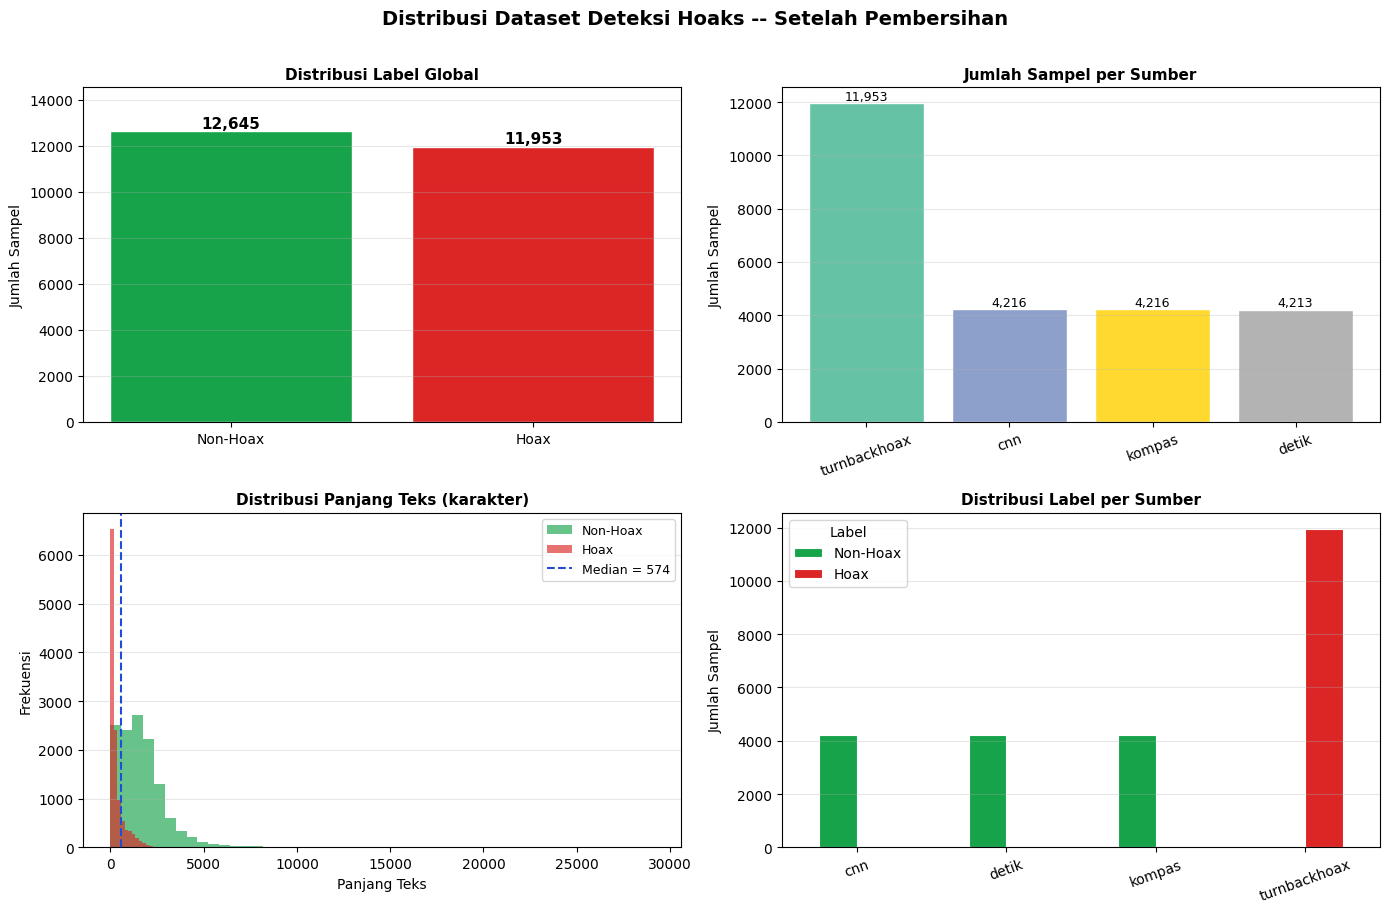

Grafik disimpan ke: distribusi_dataset.png

Statistik Panjang Teks:
count    24598.0
mean      1029.0
std       1172.7
min          1.0
25%        176.0
50%        573.5
75%       1592.0
max      29140.0

Rasio Hoax: 48.6%
  Train : 17,218 | Val : 3,690 | Test : 3,690

Corpus BERTopic (pra-oversampling): 17,218
Distribusi TRAIN sebelum balancing:
label
0    8851
1    8367
Distribusi TRAIN setelah balancing:
label
1    8851
0    8851


Map:   0%|          | 0/17702 [00:00<?, ? examples/s]

Map:   0%|          | 0/3690 [00:00<?, ? examples/s]

Map:   0%|          | 0/3690 [00:00<?, ? examples/s]

Train: 17,702 | Val: 3,690 | Test: 3,690
Trainer siap  — train: 17,702  |  val: 3,690

Memulai training IndoBERT...


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


Training selesai.
   Checkpoint terbaik : indobert_hoax_model_v3/checkpoint-186
   Metrik terbaik (f1): 0.9952

Cache prediksi direset setelah training baru selesai.

Evaluasi VALIDATION SET


{'eval_loss': 0.017077025026082993, 'eval_accuracy': 0.9953929539295393, 'eval_precision': 0.998876404494382, 'eval_recall': 0.9916341327384273, 'eval_f1': 0.9952420934788693, 'eval_precision_weighted': 0.9954166632789335, 'eval_recall_weighted': 0.9953929539295393, 'eval_f1_weighted': 0.9953924387769628, 'eval_runtime': 10.0864, 'eval_samples_per_second': 365.837, 'eval_steps_per_second': 0.991, 'epoch': 3.0}

Evaluasi TEST SET
{'eval_loss': 0.01644001714885235, 'eval_accuracy': 0.9967479674796748, 'eval_precision': 0.9994391475042064, 'eval_recall': 0.9938650306748467, 'eval_f1': 0.9966442953020134, 'eval_precision_weighted': 0.9967620795930703, 'eval_recall_weighted': 0.9967479674796748, 'eval_f1_weighted': 0.9967476949450331, 'eval_runtime': 10.5361, 'eval_samples_per_second': 350.226, 'eval_steps_per_second': 0.949, 'epoch': 3.0}


In [14]:
# ================== SEL 14 -- Pipeline End-to-End: Load → Proses → Train → Evaluasi ==================
# Menjalankan seluruh pipeline training dalam satu cell:
#   1. Muat semua dataset dari file CSV
#   2. Bersihkan data menggunakan bangun_dataframe_training()
#   3. Visualisasi distribusi data
#   4. Bagi data stratified ke train/val/test (70/15/15)
#   5. Simpan corpus train pra-oversampling untuk BERTopic nanti
#   6. Seimbangkan kelas minoritas di training set jika diaktifkan
#   7. Tokenisasi dan konversi ke HuggingFace Dataset
#   8. Buat Trainer dengan konfigurasi training yang telah ditentukan
#   9. Jalankan training dan catat log history
#   10. Evaluasi pada validation dan test set
# Output: Model terlatih dengan metrik evaluasi lengkap.
# ==========================================================================================================

df_mentah = muat_semua_dataset(cfg)
df_bersih = bangun_dataframe_training(df_mentah)

# Visualisasi distribusi dataset
visualisasi_distribusi_dataset(df_bersih, judul_prefix="Setelah Pembersihan")

train_df, val_df, test_df = bagi_data_stratified(df_bersih, seed=cfg.seed)

# Simpan corpus pra-oversampling untuk BERTopic
train_df_pra_oversampling = train_df.copy()
print(f"\nCorpus BERTopic (pra-oversampling): {len(train_df_pra_oversampling):,}")

if cfg.balance_minority:
    train_df = seimbangkan_kelas_minoritas(train_df, seed=cfg.seed)

ds_train, ds_val, ds_test = siapkan_dataset_hf(train_df, val_df, test_df)

# Buat Trainer setelah dataset tersedia
trainer = Trainer(
    model           = model,
    args            = argumen_training,
    train_dataset   = ds_train,
    eval_dataset    = ds_val,
    data_collator   = collator_padding,
    compute_metrics = hitung_metrik,
)
print(f"Trainer siap  — train: {len(ds_train):,}  |  val: {len(ds_val):,}")

print("\n" + "="*60)
print("Memulai training IndoBERT...")
print("="*60)
hasil_training = trainer.train()

print(f"\nTraining selesai.")
print(f"   Checkpoint terbaik : {trainer.state.best_model_checkpoint}")
print(f"   Metrik terbaik (f1): {trainer.state.best_metric:.4f}")

log_history_training = list(trainer.state.log_history)

# Reset cache prediksi
_cache_prediksi: Dict[str, object] = {}
print("\nCache prediksi direset setelah training baru selesai.")

print("\n" + "="*60 + "\nEvaluasi VALIDATION SET\n" + "="*60)
metrik_val = trainer.evaluate(ds_val); print(metrik_val)

print("\n" + "="*60 + "\nEvaluasi TEST SET\n" + "="*60)
metrik_test = trainer.evaluate(ds_test); print(metrik_test)

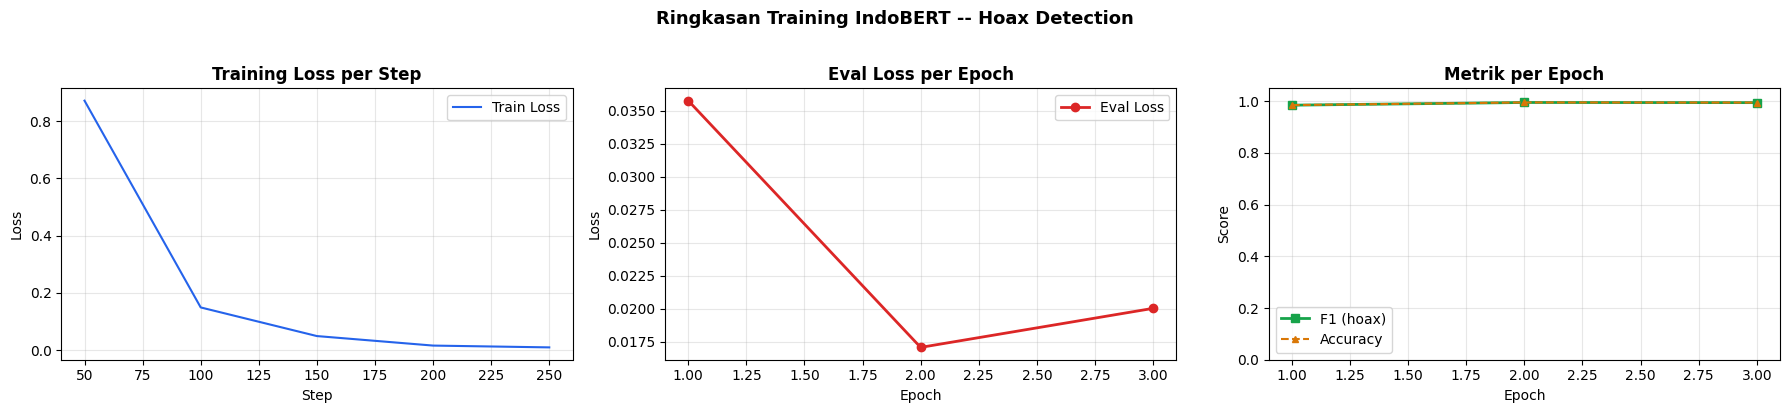

Grafik disimpan ke: kurva_training.png


In [15]:
# ================== SEL 15 -- Visualisasi Loss Curve dan Metrik per Epoch ==================
# Membuat tiga grafik untuk menganalisis proses training:
#   1. Training Loss per Step: loss saat training berlangsung
#   2. Eval Loss per Epoch: loss pada data validasi setiap epoch
#   3. Metrik per Epoch: F1-score (hoax) dan Accuracy setiap epoch
# Grafik ini membantu mendeteksi overfitting, underfitting, dan performa model akhir.
# ============================================================================================
def plot_kurva_loss(log_history: list):
    l_step, l_loss = [], []
    e_step, e_loss, e_epoch, e_f1, e_acc = [], [], [], [], []
    for entri in log_history:
        if "loss" in entri and "eval_loss" not in entri:
            l_step.append(entri["step"]); l_loss.append(entri["loss"])
        if "eval_loss" in entri:
            e_step.append(entri["step"]); e_loss.append(entri["eval_loss"])
            if "epoch"        in entri: e_epoch.append(entri["epoch"])
            if "eval_f1"      in entri: e_f1.append(entri["eval_f1"])
            if "eval_accuracy"in entri: e_acc.append(entri["eval_accuracy"])

    if not l_step and not e_step:
        print("Log history kosong."); return

    n_plot = 1 + int(bool(e_step)) + int(bool(e_f1))
    fig, axes = plt.subplots(1, n_plot, figsize=(6*n_plot, 4))
    if n_plot == 1: axes = [axes]

    if l_step:
        axes[0].plot(l_step, l_loss, color="#2563EB", lw=1.5, label="Train Loss")
        axes[0].set_title("Training Loss per Step", fontweight="bold"); axes[0].set_xlabel("Step")
        axes[0].set_ylabel("Loss"); axes[0].legend(); axes[0].grid(True, alpha=0.3)

    if e_step:
        x, xl = (e_epoch,"Epoch") if e_epoch else (e_step,"Step")
        axes[1].plot(x, e_loss, "o-", color="#DC2626", lw=2, ms=6, label="Eval Loss")
        axes[1].set_title("Eval Loss per Epoch", fontweight="bold"); axes[1].set_xlabel(xl)
        axes[1].set_ylabel("Loss"); axes[1].legend(); axes[1].grid(True, alpha=0.3)

    if e_f1:
        x, xl = (e_epoch,"Epoch") if e_epoch else (list(range(1,len(e_f1)+1)),"Checkpoint")
        axes[2].plot(x, e_f1, "s-", color="#16A34A", lw=2, ms=6, label="F1 (hoax)")
        if e_acc:
            axes[2].plot(x, e_acc, "^--", color="#D97706", lw=1.5, ms=5, label="Accuracy")
        axes[2].set_title("Metrik per Epoch", fontweight="bold"); axes[2].set_xlabel(xl)
        axes[2].set_ylabel("Score"); axes[2].set_ylim(0, 1.05)
        axes[2].legend(); axes[2].grid(True, alpha=0.3)

    plt.suptitle("Ringkasan Training IndoBERT -- Hoax Detection", fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig("kurva_training.png", dpi=150, bbox_inches="tight"); plt.show()
    print("Grafik disimpan ke: kurva_training.png")


plot_kurva_loss(log_history_training)


  Laporan Klasifikasi -- Validation (default/argmax)
Mode evaluasi: default/argmax logits, belum memakai threshold optimal.
              precision    recall  f1-score   support

    not_hoax     0.9921    0.9989    0.9955      1897
        hoax     0.9989    0.9916    0.9952      1793

    accuracy                         0.9954      3690
   macro avg     0.9955    0.9953    0.9954      3690
weighted avg     0.9954    0.9954    0.9954      3690



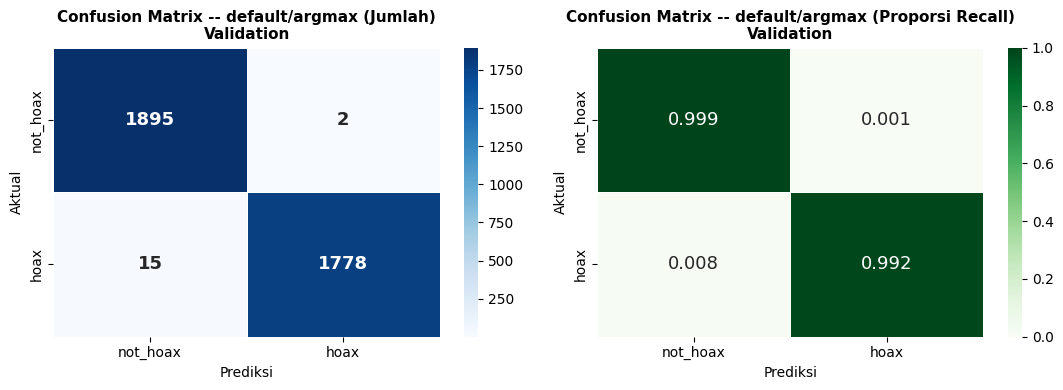

Confusion matrix default/argmax disimpan ke: confusion_matrix_validation.png



  Laporan Klasifikasi -- Test (default/argmax)
Mode evaluasi: default/argmax logits, belum memakai threshold optimal.
              precision    recall  f1-score   support

    not_hoax     0.9942    0.9995    0.9968      1897
        hoax     0.9994    0.9939    0.9966      1793

    accuracy                         0.9967      3690
   macro avg     0.9968    0.9967    0.9967      3690
weighted avg     0.9968    0.9967    0.9967      3690



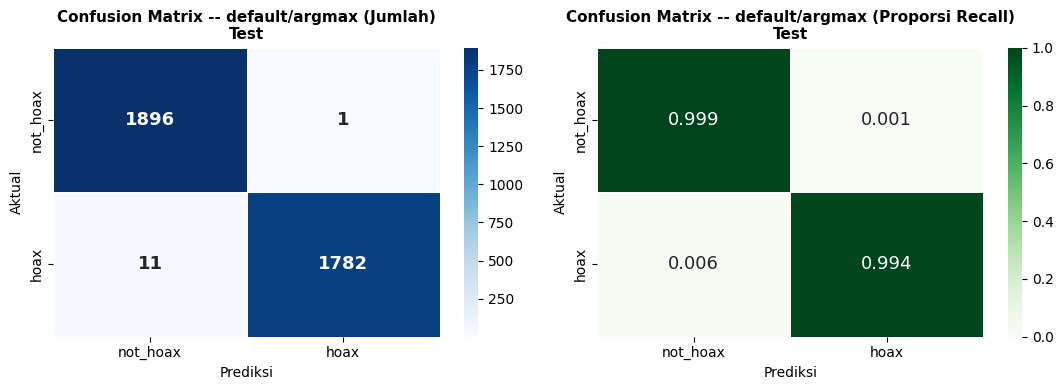

Confusion matrix default/argmax disimpan ke: confusion_matrix_test.png


In [16]:
# ================== SEL 16 -- Laporan Klasifikasi Detail dan Confusion Matrix ==================
# Menghasilkan laporan evaluasi default/argmax classifier.
# Evaluasi ini memakai argmax logits dari Trainer, bukan threshold optimal hasil kalibrasi.
# Output:
#   1. Classification report default/argmax
#   2. Confusion Matrix -- default/argmax (jumlah prediksi benar/salah)
#   3. Confusion Matrix -- default/argmax (proporsi recall)
# Confusion matrix membantu analisis error: jumlah false positive vs false negative.
# ============================================================================================

def dapatkan_prediksi(trainer: Trainer, dataset: Dataset, nama_split: str):
    if nama_split not in _cache_prediksi:
        _cache_prediksi[nama_split] = trainer.predict(dataset)
    return _cache_prediksi[nama_split]


def _normalisasi_confusion_matrix(cm: np.ndarray) -> np.ndarray:
    return np.divide(
        cm.astype(float),
        cm.sum(axis=1, keepdims=True),
        out=np.zeros_like(cm, dtype=float),
        where=cm.sum(axis=1, keepdims=True) != 0,
    )


def _auc_dari_probabilitas(y_asli, prob_hoax):
    try:
        fpr, tpr, _ = roc_curve(y_asli, prob_hoax)
        return float(auc(fpr, tpr))
    except Exception:
        return "UNKNOWN"


def laporan_detail(trainer: Trainer, dataset: Dataset, nama_split: str):
    out    = dapatkan_prediksi(trainer, dataset, nama_split)
    y_asli = out.label_ids
    y_pred = np.argmax(out.predictions, axis=-1)
    kelas  = ["not_hoax", "hoax"]

    print(f"\n{'='*60}\n  Laporan Klasifikasi -- {nama_split} (default/argmax)\n{'='*60}")
    print("Mode evaluasi: default/argmax logits, belum memakai threshold optimal.")
    print(classification_report(y_asli, y_pred, target_names=kelas, digits=4))

    cm      = confusion_matrix(y_asli, y_pred)
    cm_norm = _normalisasi_confusion_matrix(cm)
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=kelas, yticklabels=kelas, ax=axes[0],
                linewidths=0.5, annot_kws={"size":13,"weight":"bold"})
    axes[0].set_title(f"Confusion Matrix -- default/argmax (Jumlah)\n{nama_split}", fontsize=11, fontweight="bold")
    axes[0].set_xlabel("Prediksi"); axes[0].set_ylabel("Aktual")

    sns.heatmap(cm_norm, annot=True, fmt=".3f", cmap="Greens",
                xticklabels=kelas, yticklabels=kelas, ax=axes[1],
                linewidths=0.5, vmin=0, vmax=1, annot_kws={"size":13})
    axes[1].set_title(f"Confusion Matrix -- default/argmax (Proporsi Recall)\n{nama_split}", fontsize=11, fontweight="bold")
    axes[1].set_xlabel("Prediksi"); axes[1].set_ylabel("Aktual")

    plt.tight_layout()
    fname = f"confusion_matrix_{nama_split.lower().replace(' ','_')}.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight"); plt.show()
    print(f"Confusion matrix default/argmax disimpan ke: {fname}")

    probs = torch.softmax(torch.tensor(out.predictions, dtype=torch.float32), dim=-1).numpy()
    p_hoax = probs[:, 1]
    return {
        "split": nama_split,
        "mode": "default_argmax",
        "y_true": y_asli,
        "y_pred": y_pred,
        "prob_hoax": p_hoax,
        "confusion_matrix": cm,
        "accuracy": float(accuracy_score(y_asli, y_pred)),
        "precision": float(precision_score(y_asli, y_pred, pos_label=1, zero_division=0)),
        "recall": float(recall_score(y_asli, y_pred, pos_label=1, zero_division=0)),
        "f1": float(f1_score(y_asli, y_pred, pos_label=1, zero_division=0)),
        "auc": _auc_dari_probabilitas(y_asli, p_hoax),
    }


hasil_argmax_val  = laporan_detail(trainer, ds_val,  "Validation")
hasil_argmax_test = laporan_detail(trainer, ds_test, "Test")

ringkasan_argmax = pd.DataFrame([
    {"Split": r["split"], "Mode": "default/argmax", "Accuracy": r["accuracy"],
     "Precision": r["precision"], "Recall": r["recall"], "F1": r["f1"], "AUC": r["auc"]}
    for r in [hasil_argmax_val, hasil_argmax_test]
])


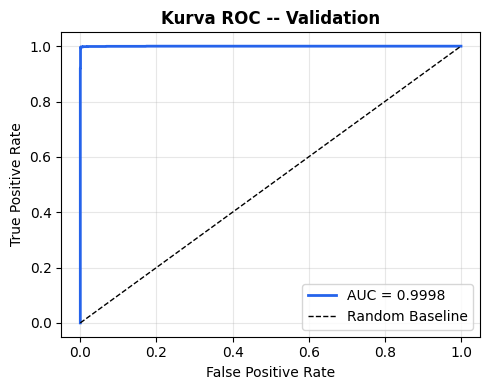

ROC curve disimpan ke: roc_curve_validation.png  |  AUC = 0.9998


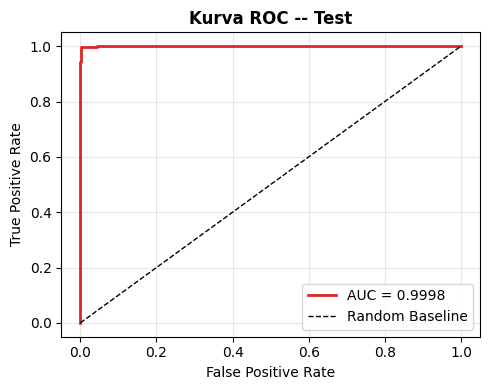

ROC curve disimpan ke: roc_curve_test.png  |  AUC = 0.9998


In [17]:
# ================== SEL 17 -- Kurva ROC dan Perhitungan AUC ==================
# Menampilkan Receiver Operating Characteristic (ROC) curve untuk setiap split.
# ROC curve menunjukkan trade-off antara True Positive Rate dan False Positive Rate
# pada berbagai threshold probabilitas.
# AUC (Area Under Curve) mengukur seberapa baik model memisahkan kelas:
#   - AUC mendekati 1.0: pemisahan kelas sangat kuat
#   - AUC = 0.5: Random classifier
#   - AUC > 0.7: indikasi pemisahan kelas yang baik
# ============================================================================
def plot_kurva_roc(trainer, dataset, nama_split, warna="#2563EB"):
    out   = dapatkan_prediksi(trainer, dataset, nama_split)
    probs = torch.softmax(torch.tensor(out.predictions, dtype=torch.float32), dim=-1).numpy()
    fpr, tpr, _ = roc_curve(out.label_ids, probs[:,1], pos_label=1)
    nilai_auc = auc(fpr, tpr)

    plt.figure(figsize=(5, 4))
    plt.plot(fpr, tpr, color=warna, lw=2, label=f"AUC = {nilai_auc:.4f}")
    plt.plot([0,1],[0,1],"k--", lw=1, label="Random Baseline")
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.title(f"Kurva ROC -- {nama_split}", fontsize=12, fontweight="bold")
    plt.legend(loc="lower right"); plt.grid(True, alpha=0.3); plt.tight_layout()
    fname = f"roc_curve_{nama_split.lower().replace(' ','_')}.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight"); plt.show()
    print(f"ROC curve disimpan ke: {fname}  |  AUC = {nilai_auc:.4f}")
    return nilai_auc


auc_val  = plot_kurva_roc(trainer, ds_val,  "Validation", warna="#2563EB")
auc_test = plot_kurva_roc(trainer, ds_test, "Test",       warna="#DC2626")

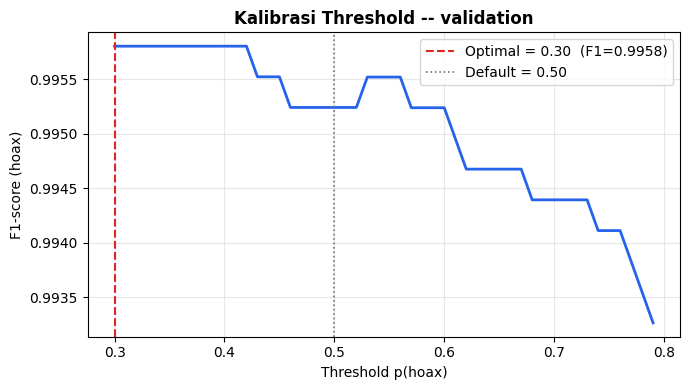

[validation] Threshold optimal : 0.30
[validation] F1 hoax @optimal  : 0.9958
[validation] F1 hoax @default  : 0.9952 (threshold=0.50)


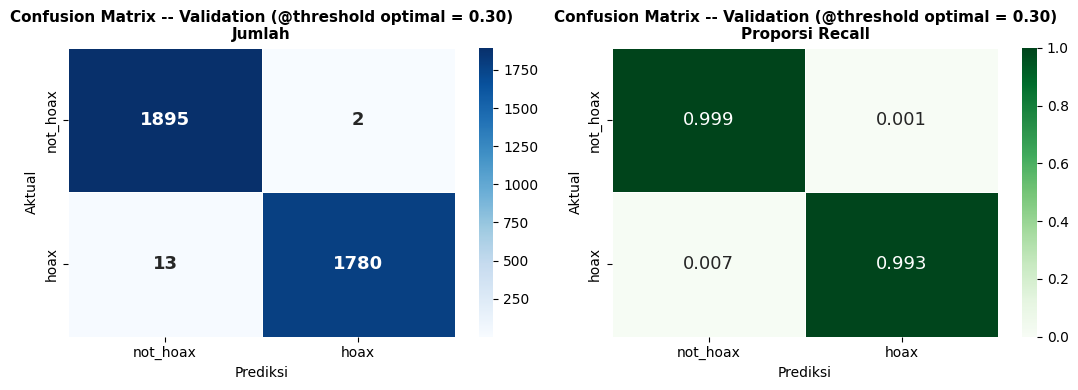


[Validation] Evaluasi threshold optimal = 0.30
{'Split': 'Validation', 'Mode': 'threshold_optimal', 'Threshold': 0.3, 'Accuracy': 0.9959349593495935, 'Precision': 0.9988776655443322, 'Recall': 0.992749581706637, 'F1': 0.9958041958041958, 'AUC': 0.9998040467218472, 'TP': 1780, 'FP': 2, 'FN': 13, 'TN': 1895, 'file_confusion_matrix': 'confusion_matrix_threshold_optimal_validation.png'}


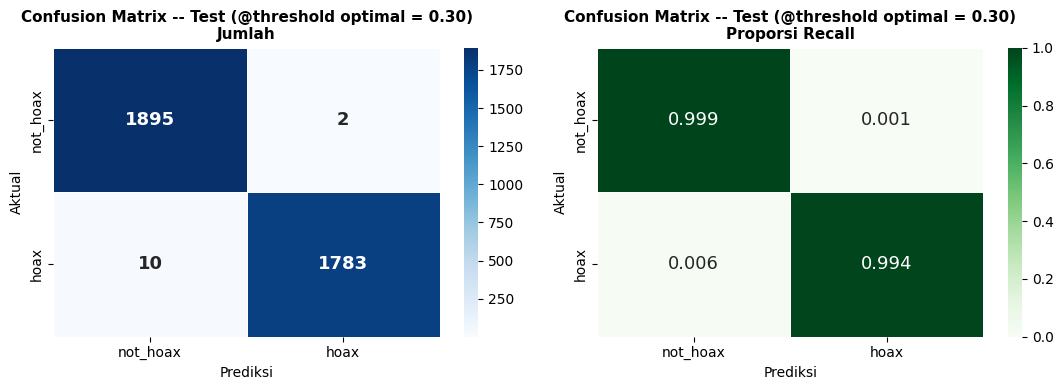


[Test] Evaluasi threshold optimal = 0.30
{'Split': 'Test', 'Mode': 'threshold_optimal', 'Threshold': 0.3, 'Accuracy': 0.9967479674796748, 'Precision': 0.9988795518207283, 'Recall': 0.9944227551589515, 'F1': 0.9966461710452766, 'AUC': 0.9998171298739518, 'TP': 1783, 'FP': 2, 'FN': 10, 'TN': 1895, 'file_confusion_matrix': 'confusion_matrix_threshold_optimal_test.png'}

THRESHOLD_DEFAULT = 0.50
THRESHOLD_OPTIMAL = 0.30


,Split,Mode,Threshold,Accuracy,Precision,Recall,F1,AUC,TP,FP,FN,TN
0,Validation,threshold_optimal,0.3,0.995935,0.998878,0.992750,0.995804,0.999804,1780,2,13,1895
1,Test,threshold_optimal,0.3,0.996748,0.998880,0.994423,0.996646,0.999817,1783,2,10,1895


In [18]:
# ================== SEL 18 -- Kalibrasi Threshold Probabilitas Optimal ==================
# Menentukan threshold optimal untuk klasifikasi berdasarkan F1-score maksimal pada validation set.
# Threshold default diambil dari THRESHOLD_DEFAULT/cfg.threshold_default.
# Proses:
#   1. Sweep threshold probabilitas hoax pada validation set
#   2. Hitung F1-score untuk setiap threshold
#   3. Pilih threshold dengan F1-score tertinggi
#   4. Evaluasi validation dan test menggunakan threshold optimal secara terpisah dari argmax
# Threshold optimal disimpan di THRESHOLD_OPTIMAL dan inference_config.
# =======================================================================================

def _threshold_default_runtime() -> float:
    if "THRESHOLD_DEFAULT" in globals():
        return float(THRESHOLD_DEFAULT)
    return float(getattr(cfg, "threshold_default"))


def _probabilitas_hoax(trainer, dataset, nama_split: str):
    out = dapatkan_prediksi(trainer, dataset, nama_split)
    probs = torch.softmax(torch.tensor(out.predictions, dtype=torch.float32), dim=-1).numpy()
    return out.label_ids, probs[:, 1]


def kalibrasi_threshold(trainer, dataset, nama_split="val") -> float:
    threshold_default = _threshold_default_runtime()
    y_asli, p_hoax = _probabilitas_hoax(trainer, dataset, nama_split)

    sweep    = np.arange(0.30, 0.80, 0.01)
    riwayat  = [(float(t), float(f1_score(y_asli,(p_hoax>=t).astype(int),
                                           pos_label=1, zero_division=0)))
                for t in sweep]
    t_best, f1_best = max(riwayat, key=lambda x: x[1])

    tv, fv = zip(*riwayat)
    plt.figure(figsize=(7, 4))
    plt.plot(tv, fv, color="#2563EB", lw=2)
    plt.axvline(t_best, color="#DC2626", ls="--", lw=1.5,
                label=f"Optimal = {t_best:.2f}  (F1={f1_best:.4f})")
    plt.axvline(threshold_default, color="#6B7280", ls=":", lw=1.2,
                label=f"Default = {threshold_default:.2f}")
    plt.xlabel("Threshold p(hoax)"); plt.ylabel("F1-score (hoax)")
    plt.title(f"Kalibrasi Threshold -- {nama_split}", fontsize=12, fontweight="bold")
    plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
    plt.savefig(f"kalibrasi_threshold_{nama_split}.png", dpi=150, bbox_inches="tight")
    plt.show()

    f1_def = f1_score(y_asli, (p_hoax>=threshold_default).astype(int), pos_label=1, zero_division=0)
    print(f"[{nama_split}] Threshold optimal : {t_best:.2f}")
    print(f"[{nama_split}] F1 hoax @optimal  : {f1_best:.4f}")
    print(f"[{nama_split}] F1 hoax @default  : {f1_def:.4f} (threshold={threshold_default:.2f})")
    return float(t_best)


def evaluasi_threshold_optimal(trainer, dataset, nama_split: str, threshold_optimal: float) -> Dict[str, object]:
    y_asli, p_hoax = _probabilitas_hoax(trainer, dataset, nama_split)
    pred = (p_hoax >= threshold_optimal).astype(int)
    cm = confusion_matrix(y_asli, pred)
    cm_norm = _normalisasi_confusion_matrix(cm)
    kelas = ["not_hoax", "hoax"]

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=kelas, yticklabels=kelas, ax=axes[0],
                linewidths=0.5, annot_kws={"size":13,"weight":"bold"})
    axes[0].set_title(
        f"Confusion Matrix -- {nama_split} (@threshold optimal = {threshold_optimal:.2f})\nJumlah",
        fontsize=11, fontweight="bold",
    )
    axes[0].set_xlabel("Prediksi"); axes[0].set_ylabel("Aktual")

    sns.heatmap(cm_norm, annot=True, fmt=".3f", cmap="Greens",
                xticklabels=kelas, yticklabels=kelas, ax=axes[1],
                linewidths=0.5, vmin=0, vmax=1, annot_kws={"size":13})
    axes[1].set_title(
        f"Confusion Matrix -- {nama_split} (@threshold optimal = {threshold_optimal:.2f})\nProporsi Recall",
        fontsize=11, fontweight="bold",
    )
    axes[1].set_xlabel("Prediksi"); axes[1].set_ylabel("Aktual")

    plt.tight_layout()
    fname = f"confusion_matrix_threshold_optimal_{nama_split.lower().replace(' ','_')}.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight"); plt.show()

    hasil = {
        "Split": nama_split,
        "Mode": "threshold_optimal",
        "Threshold": float(threshold_optimal),
        "Accuracy": float(accuracy_score(y_asli, pred)),
        "Precision": float(precision_score(y_asli, pred, pos_label=1, zero_division=0)),
        "Recall": float(recall_score(y_asli, pred, pos_label=1, zero_division=0)),
        "F1": float(f1_score(y_asli, pred, pos_label=1, zero_division=0)),
        "AUC": _auc_dari_probabilitas(y_asli, p_hoax),
        "TP": int(((pred == 1) & (y_asli == 1)).sum()),
        "FP": int(((pred == 1) & (y_asli == 0)).sum()),
        "FN": int(((pred == 0) & (y_asli == 1)).sum()),
        "TN": int(((pred == 0) & (y_asli == 0)).sum()),
        "confusion_matrix": cm,
        "file_confusion_matrix": fname,
    }
    print(f"\n[{nama_split}] Evaluasi threshold optimal = {threshold_optimal:.2f}")
    print({k: v for k, v in hasil.items() if k not in {"confusion_matrix"}})
    return hasil


THRESHOLD_DEFAULT = _threshold_default_runtime()
THRESHOLD_OPTIMAL = kalibrasi_threshold(trainer, ds_val, "validation")

hasil_threshold_optimal_val = evaluasi_threshold_optimal(trainer, ds_val, "Validation", THRESHOLD_OPTIMAL)
hasil_threshold_optimal_test = evaluasi_threshold_optimal(trainer, ds_test, "Test", THRESHOLD_OPTIMAL)

ringkasan_threshold_optimal = pd.DataFrame([
    {k: v for k, v in hasil.items() if k not in {"confusion_matrix"}}
    for hasil in [hasil_threshold_optimal_val, hasil_threshold_optimal_test]
])

print(f"\nTHRESHOLD_DEFAULT = {THRESHOLD_DEFAULT:.2f}")
print(f"THRESHOLD_OPTIMAL = {THRESHOLD_OPTIMAL:.2f}")
display(ringkasan_threshold_optimal.drop(columns=["file_confusion_matrix"], errors="ignore"))


## Tabel Perbandingan Multi-Threshold [A2]

Tabel Precision/Recall/F1 pada berbagai threshold untuk memilih trade-off false positive vs. false negative.

In [19]:
# ================== SEL 19 -- Tabel Perbandingan Multi-Threshold ==================
# Menampilkan tabel dengan metrik klasifikasi pada berbagai threshold.
# Tabel ini membantu memilih threshold optimal berdasarkan trade-off:
#   - Precision tinggi: Kurangi false positive (peringatan salah)
#   - Recall tinggi: Kurangi false negative (hoax terlewat)
#   - F1 seimbang: Balanced trade-off antara precision dan recall
# TP (True Positive), FP (False Positive), FN (False Negative) ditampilkan untuk insight detail.
# =======================================================================================
def tabel_perbandingan_threshold(trainer, dataset, nama_split, threshold_optimal,
                                  threshold_list=None):
    threshold_default = float(globals().get("THRESHOLD_DEFAULT", getattr(cfg, "threshold_default")))
    if threshold_list is None:
        threshold_list = [0.30, 0.35, 0.40, 0.45, threshold_default,
                          0.55, 0.60, 0.65, 0.70, threshold_optimal]
    threshold_list = sorted(set(round(t, 2) for t in threshold_list))

    out   = dapatkan_prediksi(trainer, dataset, nama_split)
    y     = out.label_ids
    probs = torch.softmax(torch.tensor(out.predictions, dtype=torch.float32), dim=-1).numpy()
    p_h   = probs[:,1]

    baris = []
    for t in threshold_list:
        pred = (p_h >= t).astype(int)
        prec = precision_score(y, pred, pos_label=1, zero_division=0)
        rec  = recall_score(y, pred,    pos_label=1, zero_division=0)
        f1   = f1_score(y, pred,        pos_label=1, zero_division=0)
        tp   = int(((pred==1)&(y==1)).sum())
        fp   = int(((pred==1)&(y==0)).sum())
        fn   = int(((pred==0)&(y==1)).sum())
        ket  = ""
        if abs(t - threshold_default) < 0.005: ket = "<- default"
        if abs(t - threshold_optimal) < 0.005: ket = "<- OPTIMAL"
        baris.append({"Threshold": f"{t:.2f}", "Precision": f"{prec:.4f}",
                       "Recall": f"{rec:.4f}", "F1-Hoax": f"{f1:.4f}",
                       "TP": tp, "FP": fp, "FN": fn, "Keterangan": ket})

    df_t = pd.DataFrame(baris)
    print(f"\n{'='*70}\n  Tabel Perbandingan Threshold -- {nama_split}\n{'='*70}")
    print(df_t.to_string(index=False))
    print("="*70)
    return df_t


tabel_val  = tabel_perbandingan_threshold(trainer, ds_val,  "Validation", THRESHOLD_OPTIMAL)
tabel_test = tabel_perbandingan_threshold(trainer, ds_test, "Test",       THRESHOLD_OPTIMAL)


  Tabel Perbandingan Threshold -- Validation
Threshold Precision Recall F1-Hoax   TP  FP  FN Keterangan
     0.30    0.9989 0.9927  0.9958 1780   2  13 <- OPTIMAL
     0.35    0.9989 0.9927  0.9958 1780   2  13           
     0.40    0.9989 0.9927  0.9958 1780   2  13           
     0.45    0.9989 0.9922  0.9955 1779   2  14           
     0.50    0.9989 0.9916  0.9952 1778   2  15 <- default
     0.55    0.9994 0.9916  0.9955 1778   1  15           
     0.60    0.9994 0.9911  0.9952 1777   1  16           
     0.65    0.9994 0.9900  0.9947 1775   1  18           
     0.70    0.9994 0.9894  0.9944 1774   1  19           

  Tabel Perbandingan Threshold -- Test
Threshold Precision Recall F1-Hoax   TP  FP  FN Keterangan
     0.30    0.9989 0.9944  0.9966 1783   2  10 <- OPTIMAL
     0.35    0.9989 0.9944  0.9966 1783   2  10           
     0.40    0.9989 0.9944  0.9966 1783   2  10           
     0.45    0.9989 0.9939  0.9964 1782   2  11           
     0.50    0.9994 0.9939  0

In [20]:
# ================== SEL 20 -- Simpan Model IndoBERT dan Metadata ==================
# Menyimpan model terlatih, tokenizer, dan konfigurasi inferensi.
# File yang disimpan:
#   1. Model weights (pytorch_model.bin)
#   2. Model config (config.json)
#   3. Tokenizer vocab (vocab.txt, special_tokens_map.json, dll)
#   4. inference_config.json: threshold optimal, threshold default runtime, versi library, dan metadata label
# Output disimpan di direktori output_dir (default: "indobert_hoax_model_v3")
# =================================================================================
os.makedirs(cfg.output_dir, exist_ok=True)
trainer.model.save_pretrained(cfg.output_dir)
tokenizer.save_pretrained(cfg.output_dir)

metadata_inferensi = {
    "threshold_optimal":     float(THRESHOLD_OPTIMAL),
    "threshold_default":     float(THRESHOLD_DEFAULT),
    "metric_for_best_model": "f1",
    "model_name":            cfg.model_name,
    "max_length":            cfg.max_length,
    "label2id":              label_ke_id,
    "id2label":              {str(k): v for k, v in id_ke_label.items()},
    "transformers_version":  transformers.__version__,
    "torch_version":         torch.__version__,
    "training_date":         pd.Timestamp.now().strftime("%Y-%m-%d"),
}
with open(os.path.join(cfg.output_dir, "inference_config.json"), "w",
          encoding="utf-8") as _f:
    _json.dump(metadata_inferensi, _f, indent=2, ensure_ascii=False)

print(f"Model & metadata disimpan ke: {cfg.output_dir}/")
print(f"   Best checkpoint      : {trainer.state.best_model_checkpoint}")
print(f"   THRESHOLD_OPTIMAL    : {THRESHOLD_OPTIMAL:.2f}")
print(f"   transformers_version : {transformers.__version__}")
print(f"   training_date        : {metadata_inferensi['training_date']}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model & metadata disimpan ke: indobert_hoax_model_v3/
   Best checkpoint      : indobert_hoax_model_v3/checkpoint-186
   THRESHOLD_OPTIMAL    : 0.30
   transformers_version : 5.0.0
   training_date        : 2026-05-14


## Inferensi Multi-Paragraf (Sentence-Level + Topic)

**Tidak mengubah training classifier IndoBERT.** Semua proses adalah post-processing: memisahkan teks menjadi paragraf dan kalimat, mengklasifikasikan setiap kalimat, mengagregasi label, dan mengekstraksi topik TF-IDF ringan.

- Menggunakan `THRESHOLD_OPTIMAL` dari validation set; threshold default diambil dari konfigurasi runtime sebagai pembanding.
- `torch.inference_mode()` digunakan untuk inference yang lebih efisien.


In [21]:
# ================== SEL 21 -- Utilitas Inferensi Multi-Paragraf dan Topic Extraction ==================
# Fungsi-fungsi untuk inferensi pada teks multi-paragraf dengan detail kalimat dan ekstraksi topik.
# Fitur:
#   1. prediksi_batch(): Batch prediction dengan threshold optimal
#   2. ekstrak_topik_tfidf(): Ekstraksi topik TF-IDF per paragraf
#   3. analisis_multi_paragraf(): Analisis lengkap dokumen (doc-level, paragraph-level, sentence-level)
# Menggunakan torch.inference_mode() untuk efisiensi memori dan kecepatan inference.
# Output: JSON terstruktur dengan pemetaan risiko (high/medium/low).
# ===================================================================================================
import re
from collections import defaultdict
from sklearn.feature_extraction.text import TfidfVectorizer

REGEX_PISAH_PARAGRAF = re.compile(r"(?:\r?\n){2,}")
REGEX_PISAH_KALIMAT  = re.compile(r'[^.!?]+(?:[.!?]+(?:[")\]]+)?)|[^.!?]+$')
REGEX_SPASI          = re.compile(r"\s+")
REGEX_TOKEN          = re.compile(r"[a-zA-Z]{3,}")

STOPWORDS_ID = {
    "yang","dan","atau","di","ke","dari","untuk","dengan","pada",
    "adalah","itu","ini","dalam","sebagai","karena","juga","agar",
    "oleh","saat","akan","telah","sudah","tidak","iya","ya","kita",
    "mereka","kami","anda","hingga","lebih","masih","dapat","bisa",
    "setelah","sebelum","tersebut","terhadap","disebut","menurut",
}


def normalisasi_teks(teks: str) -> str:
    return REGEX_SPASI.sub(" ", str(teks)).strip()


def pisahkan_paragraf(teks: str) -> List[str]:
    mentah = str(teks).strip()
    if not mentah: return []
    par = [p.strip() for p in REGEX_PISAH_PARAGRAF.split(mentah) if p.strip()]
    return par if par else [mentah]


def pisahkan_kalimat(paragraf: str) -> List[str]:
    d = normalisasi_teks(paragraf)
    if not d: return []
    kal = [m.group(0).strip() for m in REGEX_PISAH_KALIMAT.finditer(d)]
    return [k for k in kal if k] or [d]


def prediksi_batch(teks_list: List[str], ukuran_batch: int = 64) -> List[Dict]:
    if not teks_list: return []
    th = THRESHOLD_OPTIMAL if "THRESHOLD_OPTIMAL" in globals() else THRESHOLD_DEFAULT
    semua_probs = []
    model.eval()
    for i in range(0, len(teks_list), ukuran_batch):
        potongan = [normalisasi_teks(t) or "[EMPTY]" for t in teks_list[i:i+ukuran_batch]]
        enc = tokenizer(potongan, truncation=True, max_length=cfg.max_length,
                        padding=True, return_tensors="pt")
        enc = {k: v.to(device) for k, v in enc.items()}
        with torch.inference_mode():
            probs = torch.softmax(model(**enc).logits, dim=-1).cpu().numpy()
        semua_probs.extend(probs)

    hasil = []
    for baris in semua_probs:
        p_n, p_h = float(baris[0]), float(baris[1])
        label = "hoax" if p_h >= th else "not_hoax"
        conf  = max(p_h, p_n)
        warna = "red" if label=="hoax" else ("amber" if conf<0.70 else "green")
        hasil.append({
            "label": label,
            "probabilities": {"not_hoax": round(p_n,6), "hoax": round(p_h,6)},
            "hoax_probability": round(p_h, 6),
            "confidence":       round(conf, 6),
            "color":            warna,
            "threshold_used":   round(th, 2),
        })
    return hasil


def ekstrak_topik_tfidf(teks_par: List[str], top_k: int = 3, maks_fitur: int = 1500) -> List[Dict]:
    if not teks_par: return []
    vec = TfidfVectorizer(lowercase=True, ngram_range=(1,2), max_features=maks_fitur,
                           token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z]+\b",
                           stop_words=list(STOPWORDS_ID))
    out_t = []
    try:
        M = vec.fit_transform(teks_par); F = vec.get_feature_names_out()
        for i in range(M.shape[0]):
            br = M.getrow(i)
            if br.nnz == 0:
                tok = [t for t in REGEX_TOKEN.findall(teks_par[i].lower()) if t not in STOPWORDS_ID]
                kk  = list(dict.fromkeys(tok))[:top_k] or ["topik_umum"]
                skor = 0.0
            else:
                pas  = sorted(zip(br.indices, br.data), key=lambda x:(-x[1],F[x[0]]))[:top_k]
                kk   = [F[idx] for idx,_ in pas]
                skor = float(np.mean([v for _,v in pas])) if pas else 0.0
            out_t.append({"label": " / ".join(kk[:2]) if kk else "topik_umum",
                           "score": round(skor,6), "keywords": kk[:top_k]})
    except Exception:
        for t in teks_par:
            tok = [x for x in REGEX_TOKEN.findall(t.lower()) if x not in STOPWORDS_ID]
            kk  = list(dict.fromkeys(tok))[:top_k] or ["topik_umum"]
            out_t.append({"label": " / ".join(kk[:2]) if kk else "topik_umum",
                           "score": 0.0, "keywords": kk[:top_k]})
    return out_t


def analisis_multi_paragraf(teks: str, ukuran_batch_kalimat: int = 64) -> Dict[str,Any]:
    teks_m = str(teks).strip()
    th = THRESHOLD_OPTIMAL if "THRESHOLD_OPTIMAL" in globals() else THRESHOLD_DEFAULT
    if not teks_m:
        return {"document":{"label":"not_hoax","hoax_probability":0.0,"confidence":0.0,
                             "risk_level":"low","sentence_aggregate_label":"not_hoax",
                             "threshold_used":th,
                             "summary":{"paragraph_count":0,"sentence_count":0,
                                        "hoax_sentence_count":0,"not_hoax_sentence_count":0}},
                "paragraphs":[],"shared_topics":[]}

    pred_doc = prediksi_batch([teks_m], ukuran_batch=1)[0]
    par_list = pisahkan_paragraf(teks_m)
    t_kal, p_kal = [], []
    for pi, par in enumerate(par_list):
        for si, k in enumerate(pisahkan_kalimat(par)):
            t_kal.append(k); p_kal.append((pi,si))

    pred_kal = prediksi_batch(t_kal, ukuran_batch=ukuran_batch_kalimat)
    obj_par  = [{"paragraph_index":i,"text":p,"sentences":[]} for i,p in enumerate(par_list)]
    for (pi,si),tk,pred in zip(p_kal,t_kal,pred_kal):
        obj_par[pi]["sentences"].append({"sentence_index":si,"text":tk,**pred})

    topik_list = ekstrak_topik_tfidf([p["text"] for p in obj_par])
    jh = jnh = 0
    for i,op in enumerate(obj_par):
        kal = op["sentences"]
        if not kal:
            op.update({"label":"not_hoax","hoax_probability":0.0,"confidence":0.0})
        else:
            op["label"]            = "hoax" if any(k["label"]=="hoax" for k in kal) else "not_hoax"
            op["hoax_probability"] = round(max(k["hoax_probability"] for k in kal),6)
            op["confidence"]       = round(max(k["confidence"]       for k in kal),6)
            jh  += sum(1 for k in kal if k["label"]=="hoax")
            jnh += sum(1 for k in kal if k["label"]!="hoax")
        op["topic"] = topik_list[i]

    tmap = defaultdict(list)
    for p in obj_par: tmap[p["topic"]["label"]].append(p["paragraph_index"])
    topik_bersama = sorted([{"label":l,"paragraph_indices":v} for l,v in tmap.items() if len(v)>1],
                            key=lambda x:(x["paragraph_indices"][0],x["label"]))

    return {
        "document": {
            "label":                    pred_doc["label"],
            "hoax_probability":         pred_doc["hoax_probability"],
            "confidence":               pred_doc["confidence"],
            "threshold_used":           pred_doc["threshold_used"],
            "risk_level": ("high" if pred_doc["hoax_probability"]>0.98 else
                           "medium" if pred_doc["hoax_probability"]>0.60 else "low"),
            "sentence_aggregate_label": "hoax" if jh>0 else "not_hoax",
            "summary":{"paragraph_count":len(obj_par),"sentence_count":len(pred_kal),
                        "hoax_sentence_count":jh,"not_hoax_sentence_count":jnh},
        },
        "paragraphs":obj_par, "shared_topics":topik_bersama,
    }


print("Utilitas inferensi multi-paragraf siap.")
print(f"   Threshold aktif  : {THRESHOLD_OPTIMAL:.2f}")

Utilitas inferensi multi-paragraf siap.
   Threshold aktif  : 0.30


## Demo Inferensi V1

Deteksi multi-paragraf dengan threshold yang sudah dikalibrasi.

In [22]:
# ================== SEL 22 -- Demo Inferensi Multi-Paragraf ==================
# Contoh penggunaan fungsi analisis_multi_paragraf() pada teks multi-paragraf.
# Mendemonstrasikan:
#   1. Parsing paragraf dan kalimat
#   2. Klasifikasi setiap kalimat dengan threshold optimal
#   3. Agregasi label per paragraf
#   4. Ekstraksi topik TF-IDF per paragraf
#   5. Identifikasi topik bersama antar-paragraf
# =============================================================================
contoh_teks = """
Beredar unggahan media sosial yang menyebut pemerintah membagikan bantuan tunai langsung tanpa syarat lewat tautan tertentu. Banyak akun meminta warga mengisi data pribadi dan OTP agar dana cair hari itu juga.

Kementerian terkait kemudian merilis klarifikasi bahwa informasi tersebut tidak benar dan meminta masyarakat tidak membagikan tautan yang tidak berasal dari kanal resmi. Warga diminta cek pengumuman hanya lewat situs resmi pemerintah.

Sejumlah komentar pengguna juga menuliskan pengalaman bahwa tautan serupa berujung pada permintaan data rekening. Pakar keamanan digital menyarankan verifikasi sumber sebelum menyebarkan pesan berantai.
"""

hasil = analisis_multi_paragraf(contoh_teks, ukuran_batch_kalimat=64)

print("=" * 60 + "\nHASIL DOKUMEN:")
for k, v in hasil["document"].items():
    if k != "summary": print(f"  {k:30s}: {v}")
print(f"  {'summary':30s}: {hasil['document']['summary']}")
print("=" * 60)

for par in hasil["paragraphs"]:
    print(f"\n[Paragraf {par['paragraph_index']}]  label={par['label']}")
    print(f"  Topik : {par['topic']['label']} (score={par['topic']['score']})")
    for k in par["sentences"]:
        print(f"  . ({k['sentence_index']}) {k['label']} | p_hoax={k['hoax_probability']:.4f} | conf={k['confidence']:.4f}")

if hasil["shared_topics"]:
    print("\nTopik Bersama:", hasil["shared_topics"])

HASIL DOKUMEN:
  label                         : hoax
  hoax_probability              : 0.933066
  confidence                    : 0.933066
  threshold_used                : 0.3
  risk_level                    : medium
  sentence_aggregate_label      : hoax
  summary                       : {'paragraph_count': 3, 'sentence_count': 6, 'hoax_sentence_count': 6, 'not_hoax_sentence_count': 0}

[Paragraf 0]  label=hoax
  Topik : akun / akun meminta (score=0.14461)
  . (0) hoax | p_hoax=0.9983 | conf=0.9983
  . (1) hoax | p_hoax=0.9987 | conf=0.9987

[Paragraf 1]  label=hoax
  Topik : resmi / bahwa informasi (score=0.196977)
  . (0) hoax | p_hoax=0.9988 | conf=0.9988
  . (1) hoax | p_hoax=0.9976 | conf=0.9976

[Paragraf 2]  label=hoax
  Topik : bahwa tautan / berantai (score=0.1591)
  . (0) hoax | p_hoax=0.9978 | conf=0.9978
  . (1) hoax | p_hoax=0.9971 | conf=0.9971


## No-Regression Guarantee

1. **Training core tidak diubah secara semantik** -- alur `70/15/15 split -> balancing hanya di train -> classifier biner IndoBERT` dipertahankan.
2. **BERTopic murni post-training** -- tidak menyentuh bobot model classifier, tokenizer, checkpoint, threshold, atau evaluasi classifier.
3. **Perbaikan BERTopic bersifat lokal** -- hanya preprocessing khusus topik, stopword artefak, evaluasi topik, dan seleksi strategi outlier.
4. **Threshold dikalibrasi dari validation set** -- test set tetap digunakan untuk evaluasi akhir.


## BERTopic Topic Modeling (Post-Training)

Berjalan **setelah** training classifier selesai. Tidak masuk ke loop training dan tidak mengubah bobot IndoBERT.

**Konfigurasi aktif:**
- Corpus = `train_df_pra_oversampling` (sebelum oversampling)
- Embedding = `sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2`
- UMAP + HDBSCAN dipakai untuk reduksi dimensi dan clustering berbasis densitas
- `NR_TOPIK = 80` sebagai target topic reduction BERTopic; nilai ini tidak dapat menambah cluster jika HDBSCAN hanya membentuk sedikit cluster
- `calculate_probabilities=True` untuk mendukung evaluasi strategi reduksi outlier
- Guided topic modeling dimatikan; kategori dihitung pada evaluasi topik
- Topic `-1` adalah outlier BERTopic; Topic `0` adalah topik valid
- Outlier tidak ditargetkan menjadi 0% karena HDBSCAN dapat mempertahankan dokumen ambigu sebagai outlier

Evaluasi tambahan memakai DBCV sebagai pengganti elbow method untuk clustering berbasis densitas. DBCV final masih negatif tipis, tetapi merupakan nilai paling mendekati nol dibanding kandidat lain, sehingga strategi final dipilih sebagai kompromi terbaik.


In [23]:
# ================== SEL 23 -- Import Library BERTopic dan Dependensi ==================
# Mengimpor library untuk Topic Modeling menggunakan BERTopic.
# BERTopic menggunakan pipeline berikut:
#   1. Embedding: SentenceTransformer untuk mengubah teks menjadi vektor
#   2. Dimensionality Reduction: UMAP untuk menurunkan dimensi embedding
#   3. Clustering: HDBSCAN untuk mengelompokkan dokumen
#   4. Vectorizer: CountVectorizer + stopword artefak untuk ekstraksi kata penting
# Stopword dan preprocessing khusus BERTopic membersihkan artefak seperti ditampilkan, breaking, traduction, sic, turnbackhoax, dan mafindo.
# ====================================================================================
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer
import re as _re

STOPWORDS_BERTOPIC_ID = {
    "yang", "dan", "atau", "di", "ke", "dari", "untuk", "dengan", "pada",
    "adalah", "itu", "ini", "dalam", "sebagai", "karena", "juga", "agar",
    "oleh", "saat", "akan", "telah", "sudah", "tidak", "iya", "ya", "kita",
    "mereka", "kami", "anda", "hingga", "lebih", "masih", "dapat", "bisa",
    "setelah", "sebelum", "tersebut", "terhadap", "disebut", "menurut",
    "para", "dalam", "pihak", "bagi", "jadi", "kata", "ujar", "ungkap",
    "yakni", "serta", "karena", "sudah", "belum", "akan", "langsung",
}

STOPWORDS_BERTOPIC_EN = {
    "the", "and", "or", "of", "to", "in", "on", "for", "with", "by",
    "from", "at", "as", "is", "are", "was", "were", "be", "been", "being",
    "this", "that", "these", "those", "it", "its", "into", "about", "than",
    "after", "before", "not", "no", "yes", "you", "your", "their", "they",
    "we", "our", "us", "more", "most", "can", "could", "would", "should",
}

STOPWORDS_BERTOPIC = STOPWORDS_BERTOPIC_ID | STOPWORDS_BERTOPIC_EN
CUSTOM_NOISE_WORDS = {
    "extra", "com", "news", "gra", "bahasa", "saja", "baru", "per",
    "get", "day", "war", "red", "tbk", "archive", "arsip",
    "ada", "hari", "jakarta", "indonesia", "presiden", "saya", "orang",
    "tahun", "korban", "warga", "jokowi", "prabowo",
    "ditampilkan", "breaking", "traduction", "traduit", "par", "sic",
    "turnbackhoax", "mafindo", "pemeriksaan", "pemeriksa", "fakta",
    "terdapat", "terjemahan", "berikut",
}
STOPWORDS_BERTOPIC = STOPWORDS_BERTOPIC | CUSTOM_NOISE_WORDS

KATEGORI_TAMBAHAN_BERTOPIC = {
    "Agama & Sosial": {
        "muslim", "islam", "masjid", "allah", "umat", "halal", "salat", "arab", "saudi",
        "puasa", "ibadah", "zakat", "gereja", "katedral", "paskah", "kristen",
    },
    "Klaim & Pemeriksaan Fakta": {
        "hoax", "klaim", "narasi", "video", "gambar", "unggahan", "akun", "facebook",
        "whatsapp", "tautan", "otp", "phishing", "cek fakta", "klarifikasi",
    },
    "Politik": {"anies", "gibran", "paslon", "pramono", "megawati", "capres", "cawapres"},
    "Olahraga": {"timnas", "megawati", "sparks", "pink", "spiders", "liverpool", "city", "manchester", "arsenal", "motogp", "marquez", "bagnaia", "voli"},
    "Ekonomi & Bisnis": {"uang", "triliun", "juta", "bank", "transfer", "pajak", "bni", "dana", "donasi", "taspen", "lowongan", "karyawan"},
    "Kesehatan": {"dokter", "ppds", "masker", "sanitizer", "rokok", "vape", "bpjs", "bergizi", "daging"},
    "Bencana & Cuaca": {"kebakaran", "terbakar", "api", "tabung", "pohon", "tumbang", "banjir", "gempa"},
    "Internasional": {"yoon", "suk", "yeol", "jepang", "korea", "china", "saudi", "arab", "visa"},
    "Teknologi & Sains": {"iphone", "apple", "telkom", "telkomsel", "sim", "ponsel", "samsung", "technology"},
    "Transportasi & Infrastruktur": {"sepeda", "motor", "kendaraan", "bersepeda", "bandara", "kereta"},
    "Hiburan & Gaya Hidup": {"wisata", "tmii", "taman", "libur", "tradisi", "sirkus", "circus", "selebritas"},
    "Kriminal & Hukum": {"tewas", "kerangka", "korupsi", "gratifikasi", "seksual", "tersangka", "polisi"},
    "Lingkungan & Energi": {"ular", "serangga", "pohon", "penanaman", "hutan", "sampah"},
}

BOILERPLATE_BERTOPIC = [
    "ditampilkan ditampilkan",
    "breaking breaking",
    "traduction traduction",
    "traduit par",
    "par traduit",
    "sic sic",
    "pemeriksaan fakta",
    "pemeriksa fakta",
    "fakta mafindo",
    "mafindo turnbackhoax",
    "fakta tim pemeriksa",
    "tim pemeriksa fakta",
    "turnbackhoax mafindo",
    "terdapat narasi",
    "terdapat gambar",
    "baca berita sedikit iklan klik sini",
    "scroll bawah melanjutkan membaca",
    "baca berita",
    "klik di sini",
    "klik disini",
    "klik sini",
    "scroll bawah",
    "melanjutkan membaca",
    "selengkapnya",
    "lihat juga",
    "baca juga",
    "simak juga",
    "pilihan editor",
    "artikel selengkapnya",
    "baca selengkapnya",
    "sedikit iklan",
]

REGEX_URL_BERTOPIC = _re.compile(r"https?://\S+|www\.\S+")
REGEX_ANGKA_BERTOPIC = _re.compile(r"\b\d+(?:[\.,:/-]\d+)*\b")
REGEX_SIMBOL_BERTOPIC = _re.compile(r"[^a-z\s]")
REGEX_SPASI_BERTOPIC = _re.compile(r"\s+")


def kandidat_teks_bertopic(baris: pd.Series) -> List[str]:
    kandidat: List[str] = []
    for kol in ["summary", "isi_berita"]:
        nilai = baris.get(kol, "")
        if isinstance(nilai, str) and nilai.strip():
            kandidat.append(nilai.strip())
    return kandidat


def preprocess_teks_bertopic(teks: str) -> str:
    teks = str(teks or "").lower().strip()
    if not teks:
        return ""

    teks = REGEX_URL_BERTOPIC.sub(" ", teks)
    for frase in BOILERPLATE_BERTOPIC:
        teks = teks.replace(frase, " ")

    teks = REGEX_ANGKA_BERTOPIC.sub(" ", teks)
    teks = REGEX_SIMBOL_BERTOPIC.sub(" ", teks)
    teks = REGEX_SPASI_BERTOPIC.sub(" ", teks).strip()
    if not teks:
        return ""

    token_bersih = [
        tok for tok in teks.split(" ")
        if tok and tok not in STOPWORDS_BERTOPIC and len(tok) > 2
    ]
    return " ".join(token_bersih).strip()


def siapkan_corpus_bertopic(df_sumber: pd.DataFrame) -> List[str]:
    corpus: List[str] = []
    for _, baris in df_sumber.iterrows():
        teks_final = ""
        for teks_sumber in kandidat_teks_bertopic(baris):
            teks_final = preprocess_teks_bertopic(teks_sumber)
            if teks_final:
                break
        corpus.append(teks_final if teks_final else "topik umum")
    return corpus

print("Import BERTopic stack selesai.")

Import BERTopic stack selesai.


In [24]:
# ================== SEL 24 -- Fit BERTopic pada Corpus Training (Post-Training) ==================
# Menjalankan BERTopic pada corpus training pra-oversampling.
# Tahapan:
#   1. Embedding dokumen menggunakan SentenceTransformer (multilingual model)
#   2. Reduce dimensionalitas dengan UMAP
#   3. Cluster dokumen dengan HDBSCAN
#   4. Ekstraksi kata penting dengan CountVectorizer dan stopword artefak
# Guided topic modeling saat ini nonaktif; kategori dipakai untuk evaluasi/pelabelan topik.
# Output: model_topik, id_topik final, prob_topik, dan tabel kandidat outlier reduction.
# =====================================================================================================

if not AKTIFKAN_BERTOPIC:
    model_topik = None; dokumen_topik = []; id_topik = []; prob_topik = None
    print("AKTIFKAN_BERTOPIC=False, proses BERTopic dilewati.")
else:
    # Gunakan corpus khusus BERTopic: summary -> isi_berita, lalu preprocessing terpisah
    dokumen_topik = siapkan_corpus_bertopic(train_df_pra_oversampling)
    if MAKS_DOKUMEN_BERTOPIC and len(dokumen_topik) > MAKS_DOKUMEN_BERTOPIC:
        rng = random.Random(SEED_BERTOPIC)
        dokumen_topik = rng.sample(dokumen_topik, MAKS_DOKUMEN_BERTOPIC)

    print(f"Dokumen BERTopic (pra-oversampling): {len(dokumen_topik):,}")
    dev = "cuda" if torch.cuda.is_available() else "cpu"
    if torch.cuda.is_available():
        print(f"VRAM sebelum encode: {torch.cuda.memory_allocated()/1e6:.1f} MB")

    # Normalize ringan setelah preprocessing untuk menjaga konsistensi input embedding
    dokumen_topik_clean = [
        REGEX_SPASI_BERTOPIC.sub(" ", str(d)).strip() for d in dokumen_topik
    ]

    embedder = SentenceTransformer(MODEL_EMBEDDING_BERTOPIC, device=dev)
    try:
        emb = embedder.encode(
            dokumen_topik_clean, batch_size=UKURAN_BATCH_EMBED,
            show_progress_bar=True, convert_to_numpy=True, normalize_embeddings=True,
        )
    except ValueError as _e:
        print(f"[WARN] Encoding error: {_e}, retry dengan escape mode...")
        dokumen_topik_clean = [REGEX_SPASI_BERTOPIC.sub(" ", str(d)).strip() for d in dokumen_topik]
        emb = embedder.encode(
            dokumen_topik_clean, batch_size=UKURAN_BATCH_EMBED,
            show_progress_bar=True, convert_to_numpy=True, normalize_embeddings=True,
        )
    print(f"Shape embeddings: {emb.shape}")

    # Hapus embedder segera setelah encoding untuk menghemat VRAM
    del embedder; gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        print(f"VRAM setelah hapus embedder: {torch.cuda.memory_allocated()/1e6:.1f} MB")

    umap_m = UMAP(n_neighbors=BERTOPIC_UMAP_N_NEIGHBORS, n_components=BERTOPIC_UMAP_N_COMPONENTS, min_dist=BERTOPIC_UMAP_MIN_DIST, metric="cosine",
                   random_state=SEED_BERTOPIC, low_memory=True)
    hdb_m  = HDBSCAN(min_cluster_size=BERTOPIC_HDBSCAN_MIN_CLUSTER_SIZE, min_samples=BERTOPIC_HDBSCAN_MIN_SAMPLES, metric="euclidean",
                      cluster_selection_method=BERTOPIC_HDBSCAN_SELECTION, prediction_data=True, gen_min_span_tree=True)
    vec_m  = CountVectorizer(
        ngram_range=(1,2),
        min_df=BERTOPIC_VECTORIZER_MIN_DF,
        max_df=BERTOPIC_VECTORIZER_MAX_DF,
        max_features=20000,
        stop_words=sorted(STOPWORDS_BERTOPIC),
    )

    # Fit BERTopic; seed_topic_list hanya dikirim jika AKTIFKAN_GUIDED=True
    model_topik = BERTopic(
        language                 = "multilingual",
        calculate_probabilities  = BERTOPIC_HITUNG_PROB,
        nr_topics                = NR_TOPIK,
        seed_topic_list          = daftar_tema_utama if AKTIFKAN_GUIDED else None,
        verbose                  = True,
        embedding_model          = None,
        umap_model               = umap_m,
        hdbscan_model            = hdb_m,
        vectorizer_model         = vec_m,
    )
    id_topik, prob_topik = model_topik.fit_transform(dokumen_topik_clean, emb)
    id_topik_fit_awal = list(id_topik)


    def _ambil_relative_validity_bertopic() -> object:
        hdbscan_model_tmp = getattr(model_topik, "hdbscan_model", None)
        try:
            return float(getattr(hdbscan_model_tmp, "relative_validity_"))
        except Exception as exc:
            return f"UNKNOWN: {exc}"

    def _angka_kandidat(nilai, default=np.nan) -> float:
        try:
            if isinstance(nilai, str):
                return default
            return float(nilai)
        except Exception:
            return default

    def _pasangan_kategori_bertopic() -> List[tuple]:
        pasangan = [(nama, set(keywords)) for nama, keywords in PETA_KATEGORI_SHARED]
        for nama, keywords in globals().get("KATEGORI_TAMBAHAN_BERTOPIC", {}).items():
            for idx, (nama_existing, keyword_existing) in enumerate(pasangan):
                if nama_existing == nama:
                    pasangan[idx] = (nama_existing, set(keyword_existing) | set(keywords))
                    break
            else:
                pasangan.append((nama, set(keywords)))
        return pasangan

    def _mapping_kategori_kandidat(info_valid: pd.DataFrame, top_n_words: int = 20) -> Dict[int, str]:
        lexicon_per_kategori = []
        for nama_kategori, seed_keywords in _pasangan_kategori_bertopic():
            seed_set = {kw.lower().strip() for kw in seed_keywords if str(kw).strip()}
            token_set = {token for kw in seed_set for token in kw.split() if token}
            lexicon_per_kategori.append({"nama": nama_kategori, "seed_set": seed_set, "token_set": token_set})

        mapping = {}
        for _, row in info_valid.iterrows():
            topic_id = int(row["Topic"])
            top_words = model_topik.get_topic(topic_id) or []
            topic_terms = [
                (str(w).lower().strip(), float(score))
                for w, score in top_words[:top_n_words]
                if str(w).strip()
            ]
            if not topic_terms:
                mapping[topic_id] = "Topik Umum"
                continue

            best_idx = -1
            best_exact = 0
            best_score = 0.0
            for idx, lexicon in enumerate(lexicon_per_kategori):
                exact = 0
                skor = 0.0
                for term, score in topic_terms:
                    tokens = [token for token in term.split() if token]
                    if term in lexicon["seed_set"]:
                        exact += 1
                        skor += score
                    token_hits = sum(1 for token in tokens if token in lexicon["token_set"])
                    if token_hits:
                        skor += score * token_hits
                if exact > best_exact or (exact == best_exact and skor > best_score):
                    best_idx = idx
                    best_exact = exact
                    best_score = skor

            if best_idx != -1 and (best_exact >= 1 or best_score >= 0.02):
                mapping[topic_id] = lexicon_per_kategori[best_idx]["nama"]
            else:
                mapping[topic_id] = "Topik Umum"
        return mapping

    def _stat_keyword_kandidat(info_valid: pd.DataFrame, kategori_mapping: Dict[int, str]) -> Dict[str, object]:
        peta_kategori_keywords = {nama: set(keywords) for nama, keywords in PETA_KATEGORI_SHARED}
        for nama, keywords in globals().get("KATEGORI_TAMBAHAN_BERTOPIC", {}).items():
            peta_kategori_keywords.setdefault(nama, set()).update(set(keywords))

        rows = []
        coverage_values = []
        for _, row in info_valid.iterrows():
            topic_id = int(row["Topic"])
            kategori = kategori_mapping.get(topic_id, "Topik Umum")
            kata_skor = model_topik.get_topic(topic_id) or []
            kategori_keywords = {kw.lower() for kw in peta_kategori_keywords.get(kategori, set())}
            top_words = [str(kata).lower().strip() for kata, _ in kata_skor[:10]]
            top_tokens = {token for kata in top_words for token in kata.split() if token}
            keyword_ditemukan = {
                keyword for keyword in kategori_keywords
                if keyword in top_words or any(token in top_tokens for token in keyword.split())
            }
            if kategori_keywords:
                coverage_values.append(len(keyword_ditemukan) / len(kategori_keywords))
            for rank, (kata, skor) in enumerate(kata_skor[:10], start=1):
                rows.append({"Topik_ID": topic_id, "Kata": str(kata), "Rank": rank, "Skor_cTFIDF": float(skor), "Kategori": kategori})

        df_tmp = pd.DataFrame(rows)
        if len(df_tmp) > 0:
            kata_per_topik = df_tmp.groupby("Kata")["Topik_ID"].nunique()
            topic_exclusivity = float((kata_per_topik == 1).mean())
        else:
            topic_exclusivity = "UNKNOWN"

        return {
            "topic_exclusivity": topic_exclusivity,
            "keyword_coverage": float(np.nanmean(coverage_values)) if coverage_values else "UNKNOWN",
            "jumlah_topik_umum": int(sum(1 for kategori in kategori_mapping.values() if kategori == "Topik Umum")),
        }

    try:
        from gensim.corpora import Dictionary as _DictionaryBertopic
        from gensim.models import CoherenceModel as _CoherenceModelBertopic
        docs_coherence_kandidat = [str(d).split() for d in dokumen_topik_clean if str(d).strip()]
        docs_coherence_kandidat = [d for d in docs_coherence_kandidat if d]
        if len(docs_coherence_kandidat) > 8000:
            rng_coh_kandidat = random.Random(SEED_BERTOPIC)
            idx_coh = sorted(rng_coh_kandidat.sample(range(len(docs_coherence_kandidat)), 8000))
            docs_coherence_kandidat = [docs_coherence_kandidat[i] for i in idx_coh]
        dictionary_coh_kandidat = _DictionaryBertopic(docs_coherence_kandidat)
    except Exception as exc:
        _CoherenceModelBertopic = None
        dictionary_coh_kandidat = None
        docs_coherence_kandidat = []
        print(f"[WARN] Coherence kandidat tidak tersedia: {exc}")

    def _coherence_kandidat(info_valid: pd.DataFrame) -> object:
        if _CoherenceModelBertopic is None or dictionary_coh_kandidat is None:
            return "UNKNOWN"
        try:
            topic_word_lists = []
            for topic_id in info_valid["Topic"].tolist():
                kandidat_kata = []
                for kata, _ in (model_topik.get_topic(int(topic_id)) or [])[:15]:
                    kata = str(kata).strip().lower()
                    if kata and " " not in kata and kata in dictionary_coh_kandidat.token2id:
                        kandidat_kata.append(kata)
                if len(kandidat_kata) >= 2:
                    topic_word_lists.append(kandidat_kata[:10])
            if len(topic_word_lists) < 2:
                return "UNKNOWN"
            coherence_model = _CoherenceModelBertopic(
                topics=topic_word_lists,
                texts=docs_coherence_kandidat,
                dictionary=dictionary_coh_kandidat,
                coherence="c_v",
            )
            return float(coherence_model.get_coherence())
        except Exception as exc:
            return f"UNKNOWN: {exc}"

    def _dbcv_kandidat(topik: List[int]) -> object:
        try:
            from hdbscan.validity import validity_index
            if not hasattr(umap_m, "embedding_"):
                return "UNKNOWN: UMAP embedding tidak tersedia"
            X = np.asarray(umap_m.embedding_)
            y = np.asarray(topik)
            if len(X) != len(y):
                return "UNKNOWN: jumlah embedding dan label tidak sama"

            maks_sample = 3000
            idx_eval = np.arange(len(y))
            if len(y) > maks_sample:
                rng_eval = np.random.default_rng(SEED_BERTOPIC)
                pilihan = []
                cluster_labels = [lab for lab in np.unique(y) if lab != -1]
                per_cluster = max(5, maks_sample // max(len(cluster_labels), 1))
                for lab in cluster_labels:
                    idx_lab = np.flatnonzero(y == lab)
                    ambil = min(len(idx_lab), per_cluster)
                    if ambil:
                        pilihan.extend(rng_eval.choice(idx_lab, size=ambil, replace=False).tolist())
                sisa = maks_sample - len(pilihan)
                idx_noise = np.flatnonzero(y == -1)
                if sisa > 0 and len(idx_noise) > 0:
                    pilihan.extend(rng_eval.choice(idx_noise, size=min(len(idx_noise), sisa), replace=False).tolist())
                idx_eval = np.array(sorted(set(pilihan)), dtype=int)
                if len(idx_eval) > maks_sample:
                    idx_eval = np.sort(rng_eval.choice(idx_eval, size=maks_sample, replace=False))

            y_raw = y[idx_eval]
            valid_labels = [lab for lab in np.unique(y_raw) if lab != -1]
            if len(valid_labels) < 2:
                return "UNKNOWN: cluster valid kurang dari 2"
            label_map = {lab: idx for idx, lab in enumerate(sorted(valid_labels))}
            y_eval = np.array([label_map.get(lab, -1) for lab in y_raw], dtype=int)
            return float(validity_index(np.asarray(X[idx_eval], dtype=np.float64), y_eval, metric="euclidean"))
        except Exception as exc:
            return f"UNKNOWN: {exc}"

    def _ringkas_kandidat_bertopic(nama: str, topik: List[int]) -> Dict[str, object]:
        topik = [int(t) for t in topik]
        arr = np.asarray(topik)
        valid = arr[arr != -1]
        vc = pd.Series(valid).value_counts() if len(valid) else pd.Series(dtype=int)
        topik_terbesar_id = int(vc.index[0]) if len(vc) else "UNKNOWN"
        topik_terbesar_count = int(vc.iloc[0]) if len(vc) else 0

        model_topik.update_topics(dokumen_topik_clean, topics=topik, vectorizer_model=vec_m)
        if hasattr(model_topik, "topics_"):
            model_topik.topics_ = topik
        info_kandidat = model_topik.get_topic_info().copy()
        info_valid_kandidat = info_kandidat[info_kandidat["Topic"] != -1].copy()
        kategori_mapping_kandidat = _mapping_kategori_kandidat(info_valid_kandidat)
        keyword_stats = _stat_keyword_kandidat(info_valid_kandidat, kategori_mapping_kandidat)
        top_words_terbesar = ""
        if topik_terbesar_id != "UNKNOWN":
            top_words_terbesar = ", ".join([w for w, _ in (model_topik.get_topic(int(topik_terbesar_id)) or [])[:8]])

        return {
            "nama_konfigurasi": nama,
            "jumlah_topik_valid": int(pd.Series(valid).nunique()) if len(valid) else 0,
            "jumlah_outlier": int((arr == -1).sum()),
            "outlier_rate": float((arr == -1).mean()) if len(arr) else np.nan,
            "topik_terbesar_id": topik_terbesar_id,
            "topik_terbesar_count": topik_terbesar_count,
            "persentase_topik_terbesar": float(topik_terbesar_count / len(arr)) if len(arr) else np.nan,
            "coherence_c_v": _coherence_kandidat(info_valid_kandidat),
            "DBCV": _dbcv_kandidat(topik),
            "hdbscan_relative_validity": _ambil_relative_validity_bertopic(),
            "topic_exclusivity": keyword_stats["topic_exclusivity"],
            "keyword_coverage": keyword_stats["keyword_coverage"],
            "jumlah_topik_umum": keyword_stats["jumlah_topik_umum"],
            "top_words_topik_terbesar": top_words_terbesar,
        }

    kandidat_topik_bertopic = {"fit_awal_hdbscan": id_topik_fit_awal}

    if BERTOPIC_REDUCE_OUTLIERS:
        if prob_topik is not None:
            try:
                topik_prob = model_topik.reduce_outliers(
                    dokumen_topik_clean,
                    id_topik_fit_awal,
                    probabilities=prob_topik,
                    strategy="probabilities",
                    threshold=BERTOPIC_REDUCE_OUTLIERS_THRESHOLD,
                )
                kandidat_topik_bertopic["reduce_probabilities"] = list(topik_prob)
            except Exception as exc:
                print(f"[WARN] reduce_outliers probabilities dilewati: {exc}")

        try:
            topik_emb = model_topik.reduce_outliers(
                dokumen_topik_clean,
                id_topik_fit_awal,
                embeddings=emb,
                strategy="embeddings",
                threshold=BERTOPIC_REDUCE_OUTLIERS_THRESHOLD,
            )
            kandidat_topik_bertopic["reduce_embeddings"] = list(topik_emb)
        except Exception as exc:
            print(f"[WARN] reduce_outliers embeddings dilewati: {exc}")

    ringkasan_kandidat_rows = [
        _ringkas_kandidat_bertopic(nama, topik)
        for nama, topik in kandidat_topik_bertopic.items()
    ]

    baseline_ringkas = ringkasan_kandidat_rows[0]
    baseline_valid = max(1, int(baseline_ringkas["jumlah_topik_valid"]))
    ada_dbcv_ge_0 = any(_angka_kandidat(r.get("DBCV")) >= 0 for r in ringkasan_kandidat_rows)

    def _skor_kandidat(r: Dict[str, object]) -> float:
        outlier_rate = _angka_kandidat(r.get("outlier_rate"), 1.0)
        dbcv = _angka_kandidat(r.get("DBCV"), -1.0)
        coherence = _angka_kandidat(r.get("coherence_c_v"), 0.0)
        exclusivity = _angka_kandidat(r.get("topic_exclusivity"), 0.0)
        coverage = _angka_kandidat(r.get("keyword_coverage"), 0.0)
        topik_umum = _angka_kandidat(r.get("jumlah_topik_umum"), baseline_valid)
        topik_valid = max(1.0, _angka_kandidat(r.get("jumlah_topik_valid"), 1.0))
        topik_terbesar = _angka_kandidat(r.get("persentase_topik_terbesar"), 1.0)

        skor = 0.0
        skor += 6.0 if 0.05 <= outlier_rate <= 0.30 else -min(abs(outlier_rate - 0.18) * 12.0, 6.0)
        if outlier_rate == 0:
            skor -= 10.0
        skor += (5.0 + dbcv * 4.0) if dbcv >= 0 else (-7.0 + dbcv * 4.0)
        skor += coherence * 2.0
        skor += exclusivity * 1.5
        skor += coverage * 10.0
        skor -= (topik_umum / topik_valid) * 2.5
        if topik_terbesar > 0.20:
            skor -= 4.0 + (topik_terbesar - 0.20) * 12.0
        if topik_valid < max(20, baseline_valid * 0.80):
            skor -= 5.0
        return float(skor)

    for row in ringkasan_kandidat_rows:
        row["skor_seleksi"] = _skor_kandidat(row)
        alasan = []
        outlier_rate = _angka_kandidat(row.get("outlier_rate"), 1.0)
        dbcv = _angka_kandidat(row.get("DBCV"), -1.0)
        topik_terbesar = _angka_kandidat(row.get("persentase_topik_terbesar"), 1.0)
        if 0.05 <= outlier_rate <= 0.30:
            alasan.append("outlier_wajar")
        if outlier_rate == 0:
            alasan.append("penalti_outlier_0")
        if dbcv < 0:
            alasan.append("DBCV_negatif_tipis_mendekati_nol" if dbcv > -0.05 else "penalti_dbcv_sangat_negatif")
        if topik_terbesar > 0.20:
            alasan.append("penalti_topik_terbesar_dominan")
        row["catatan_seleksi"] = "; ".join(alasan) if alasan else "OK"

    kandidat_primer = [
        r for r in ringkasan_kandidat_rows
        if 0.05 <= _angka_kandidat(r.get("outlier_rate"), 1.0) <= 0.30
        and _angka_kandidat(r.get("DBCV"), -1.0) >= 0
        and _angka_kandidat(r.get("persentase_topik_terbesar"), 1.0) <= 0.20
        and _angka_kandidat(r.get("jumlah_topik_valid"), 0.0) >= max(20, baseline_valid * 0.80)
    ]
    kandidat_sekunder = [
        r for r in ringkasan_kandidat_rows
        if _angka_kandidat(r.get("outlier_rate"), 1.0) > 0
        and (_angka_kandidat(r.get("DBCV"), -1.0) >= 0 or not ada_dbcv_ge_0)
        and _angka_kandidat(r.get("jumlah_topik_valid"), 0.0) >= max(20, baseline_valid * 0.80)
    ]
    kandidat_fallback = [
        r for r in ringkasan_kandidat_rows
        if not (
            _angka_kandidat(r.get("outlier_rate"), 1.0) == 0
            and _angka_kandidat(r.get("DBCV"), -1.0) < 0
            and len(ringkasan_kandidat_rows) > 1
        )
    ]
    pool_kandidat = kandidat_primer or kandidat_sekunder or kandidat_fallback or ringkasan_kandidat_rows
    kandidat_final = max(pool_kandidat, key=lambda r: r["skor_seleksi"])
    BERTOPIC_OUTLIER_STRATEGY_TERPILIH = kandidat_final["nama_konfigurasi"]
    if BERTOPIC_OUTLIER_STRATEGY_TERPILIH == "reduce_probabilities":
        BERTOPIC_ALASAN_STRATEGI_FINAL = (
            "Semua kandidat memiliki DBCV negatif atau mendekati nol; strategi reduce_probabilities dipilih karena memberikan kompromi terbaik: "
            "outlier berada pada rentang wajar, coherence tertinggi, DBCV paling mendekati nol dibanding kandidat lain, "
            "dan tidak memaksa seluruh outlier menjadi topik valid. Strategi final dipilih bukan karena DBCV sudah ideal secara absolut, "
            "tetapi karena secara komparatif reduce_probabilities memiliki kombinasi terbaik antara outlier rate, coherence, DBCV, "
            "keyword coverage, dan distribusi topik. DBCV bernilai negatif tipis menunjukkan struktur density cluster belum ideal, "
            "tetapi kandidat ini tetap dipilih karena menjadi kompromi terbaik dibanding kandidat lain dan tidak menyebabkan outlier 0%."
        )
    elif kandidat_primer:
        BERTOPIC_ALASAN_STRATEGI_FINAL = "primer: outlier 5-30%, DBCV layak secara komparatif, topik terbesar tidak dominan"
    elif kandidat_sekunder:
        BERTOPIC_ALASAN_STRATEGI_FINAL = "sekunder: kandidat terbaik secara komparatif dengan outlier tidak nol"
    else:
        BERTOPIC_ALASAN_STRATEGI_FINAL = "fallback: kandidat terbaik setelah penalti outlier 0/DBCV negatif"

    for row in ringkasan_kandidat_rows:
        row["status_seleksi"] = "TERPILIH" if row["nama_konfigurasi"] == BERTOPIC_OUTLIER_STRATEGY_TERPILIH else "tidak_dipilih"

    id_topik = [int(t) for t in kandidat_topik_bertopic[BERTOPIC_OUTLIER_STRATEGY_TERPILIH]]
    model_topik.update_topics(dokumen_topik_clean, topics=id_topik, vectorizer_model=vec_m)
    if hasattr(model_topik, "topics_"):
        model_topik.topics_ = id_topik
    print(f"[INFO] Outlier strategy terpilih: {BERTOPIC_OUTLIER_STRATEGY_TERPILIH}")
    print(f"[INFO] Alasan seleksi: {BERTOPIC_ALASAN_STRATEGI_FINAL}")

    tabel_perbandingan_bertopic = pd.DataFrame(ringkasan_kandidat_rows)
    display(tabel_perbandingan_bertopic)
    jumlah_topic_sebelum_merge = len(model_topik.get_topics())
    print("Jumlah topic sebelum merge:", jumlah_topic_sebelum_merge)

    # ================== MERGE TOPIC MANUAL OPSIONAL (DINONAKTIFKAN DEFAULT) ==================
    topics_to_merge = [
        [3, 19],   # contoh pasangan topik lama; hanya dipakai jika keduanya tersedia
        [20, 65],  # contoh pasangan topik lama; hanya dipakai jika keduanya tersedia
        [10, 68],  # contoh pasangan topik lama; hanya dipakai jika keduanya tersedia
        [27, 67],  # contoh pasangan topik lama; hanya dipakai jika keduanya tersedia
    ]

    if BERTOPIC_AKTIFKAN_MERGE_MANUAL:
        topic_tersedia = set(model_topik.get_topic_info()["Topic"].astype(int).tolist())
        topics_to_merge = [grp for grp in topics_to_merge if all(t in topic_tersedia for t in grp)]
        if topics_to_merge:
            print("\n[INFO] Melakukan merge topic konservatif...")
            model_topik.merge_topics(dokumen_topik_clean, topics_to_merge=topics_to_merge)
            if hasattr(model_topik, "topics_") and model_topik.topics_ is not None:
                id_topik = list(model_topik.topics_)
            print("[SUCCESS] Merge topic berhasil dilakukan.")
        else:
            print("\n[INFO] Merge topic dilewati: tidak ada pasangan topic ID yang valid.")
    else:
        print("\n[INFO] Merge topic manual dinonaktifkan.")

    jumlah_topic_setelah_merge = len(model_topik.get_topics())
    print("Jumlah topic setelah merge:", jumlah_topic_setelah_merge)

    info = model_topik.get_topic_info()
    n_valid = len(info[info["Topic"] != -1])
    print(f"\nBERTopic selesai.")
    print(f"   Topik valid : {n_valid}")
    print(f"   Outlier (-1): {sum(1 for t in id_topik if t==-1):,}")
    print("\n10 topik teratas:")
    print(info.head(10).to_string(index=False))


Dokumen BERTopic (pra-oversampling): 17,218
VRAM sebelum encode: 1347.6 MB


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

VRAM setelah hapus embedder: 1347.6 MB


2026-05-14 07:36:18,688 - BERTopic - Dimensionality - Completed ✓
2026-05-14 07:36:18,690 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-14 07:37:47,545 - BERTopic - Cluster - Completed ✓
2026-05-14 07:37:47,547 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-05-14 07:37:49,300 - BERTopic - Representation - Completed ✓
2026-05-14 07:37:49,301 - BERTopic - Topic reduction - Reducing number of topics
2026-05-14 07:37:49,366 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-14 07:37:50,999 - BERTopic - Representation - Completed ✓
2026-05-14 07:37:51,004 - BERTopic - Topic reduction - Reduced number of topics from 357 to 80
2026-05-14 07:37:52,622 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be

[INFO] Outlier strategy terpilih: reduce_probabilities
[INFO] Alasan seleksi: Semua kandidat memiliki DBCV negatif atau mendekati nol; strategi reduce_probabilities dipilih karena memberikan kompromi terbaik: outlier berada pada rentang wajar, coherence tertinggi, DBCV paling mendekati nol dibanding kandidat lain, dan tidak memaksa seluruh outlier menjadi topik valid. Strategi final dipilih bukan karena DBCV sudah ideal secara absolut, tetapi karena secara komparatif reduce_probabilities memiliki kombinasi terbaik antara outlier rate, coherence, DBCV, keyword coverage, dan distribusi topik. DBCV bernilai negatif tipis menunjukkan struktur density cluster belum ideal, tetapi kandidat ini tetap dipilih karena menjadi kompromi terbaik dibanding kandidat lain dan tidak menyebabkan outlier 0%.


,nama_konfigurasi,jumlah_topik_valid,jumlah_outlier,outlier_rate,topik_terbesar_id,topik_terbesar_count,persentase_topik_terbesar,coherence_c_v,DBCV,hdbscan_relative_validity,topic_exclusivity,keyword_coverage,jumlah_topik_umum,top_words_topik_terbesar,skor_seleksi,catatan_seleksi,status_seleksi
0,fit_awal_hdbscan,79,7658,0.444767,0,1087,0.063132,0.512869,-0.039258,0.21855,0.919890,0.068254,2,"amin, anies, semoga, trending, semua, pak, cir...",-7.309411,DBCV_negatif_tipis_mendekati_nol,tidak_dipilih
1,reduce_probabilities,79,3771,0.219015,0,2787,0.161865,0.520257,-0.013278,0.21855,0.913889,0.068779,2,"anies, pak, apa, amin, semoga, ganjar, gibran,...",1.982729,outlier_wajar; DBCV_negatif_tipis_mendekati_nol,TERPILIH
2,reduce_embeddings,79,0,0.000000,0,2502,0.145313,0.503777,-0.748805,0.21855,0.895184,0.073368,2,"anies, semoga, pak, amin, gibran, ganjar, raky...",-19.134503,penalti_outlier_0; penalti_dbcv_sangat_negatif,tidak_dipilih


Jumlah topic sebelum merge: 80

[INFO] Merge topic manual dinonaktifkan.
Jumlah topic setelah merge: 80

BERTopic selesai.
   Topik valid : 79
   Outlier (-1): 3,771

10 topik teratas:
 Topic  Count                                   Name                                                                                                   Representation                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          


[Visualisasi Topik] Total dokumen analisis utama: 13,447
  Dokumen outlier (-1): 3,771 [tidak divisualisasikan]
Sampling 2500 dokumen (stratified by label)...
  Setelah sampling: 2,500 dokumen
    - Hoax: 1,250
    - Non-Hoax: 1,250


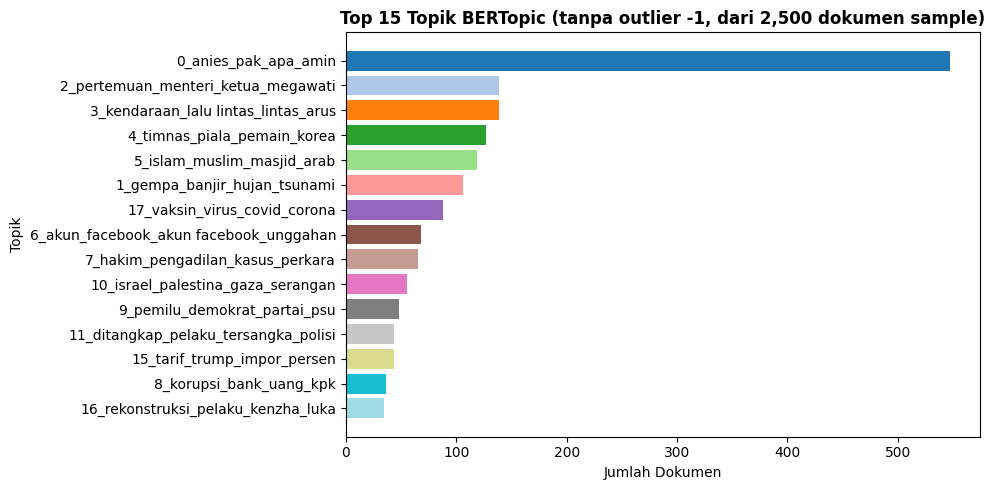

✓ Grafik distribusi topik disimpan: distribusi_topik_bertopic.png


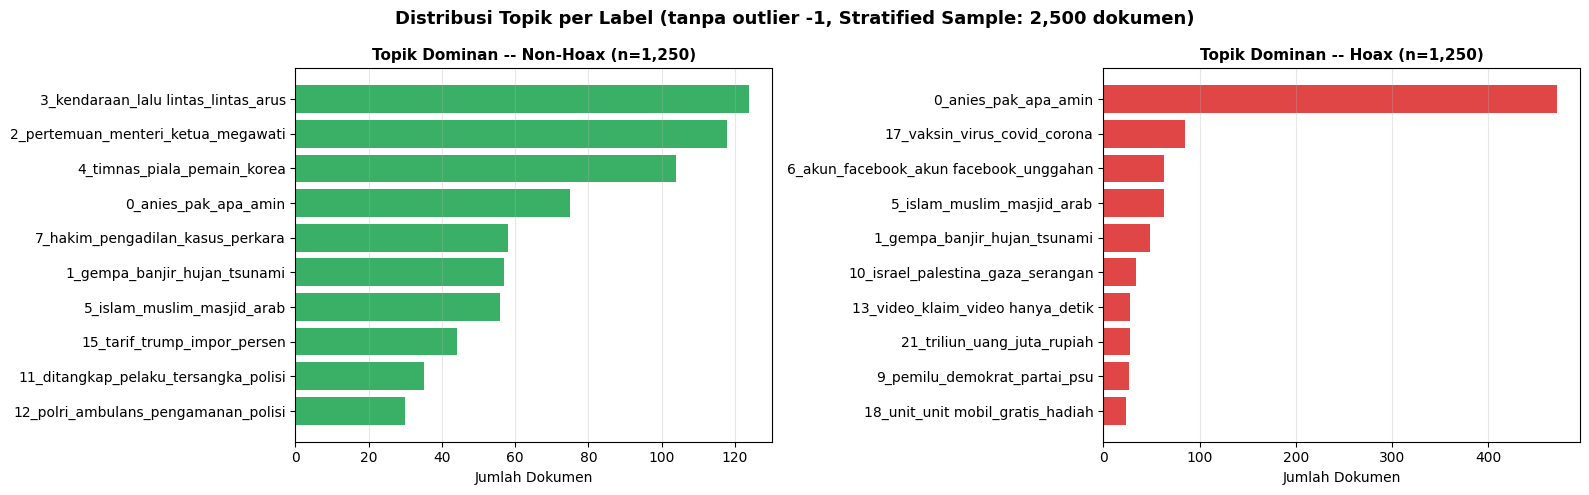

✓ Analisis topik per label disimpan: topik_per_label.png


In [25]:
# ================== SEL 25 -- Visualisasi Topik dan Analisis per Label ==================
# Membuat visualisasi distribusi topik final BERTopic setelah seleksi strategi outlier.
#   1. Grafik Top-N topik valid berdasarkan jumlah dokumen (outlier -1 dikeluarkan)
#   2. Analisis topik dominan per label (hoax vs non-hoax)
# Memberikan insights tentang topik yang sering dikaitkan dengan hoax vs non-hoax.
# Batasan dokumen untuk visualisasi: 2500 dokumen, dengan stratified sampling jika jumlah data lebih besar.
# =======================================================================================
if AKTIFKAN_BERTOPIC and model_topik is not None:
    info_viz   = model_topik.get_topic_info().copy()
    info_valid = info_viz[info_viz["Topic"] != -1].copy()
    info_valid_main = info_valid.copy()

    # Siapkan data untuk visualisasi dengan batasan 2500 dokumen
    df_analisis = train_df_pra_oversampling[["text","label"]].copy()
    n_cocok = min(len(df_analisis), len(id_topik))
    df_analisis = df_analisis.iloc[:n_cocok].copy()
    df_analisis["topic_id"] = id_topik[:n_cocok]
    jumlah_outlier_dokumen = int((df_analisis["topic_id"] == -1).sum())
    df_analisis = df_analisis[df_analisis["topic_id"] != -1].copy()
    peta_nama_semua = dict(zip(info_valid["Topic"], info_valid["Name"]))
    df_analisis["topic_name"] = df_analisis["topic_id"].map(peta_nama_semua)

    # Stratified sampling untuk visualisasi (max 2500 dokumen)
    MAKS_DOKUMEN_VIZ = 2500
    print(f"\n[Visualisasi Topik] Total dokumen analisis utama: {len(df_analisis):,}")
    print(f"  Dokumen outlier (-1): {jumlah_outlier_dokumen:,} [tidak divisualisasikan]")
    if len(df_analisis) > MAKS_DOKUMEN_VIZ:
        print(f"Sampling {MAKS_DOKUMEN_VIZ} dokumen (stratified by label)...")
        # Stratified sampling: pertahankan proporsi hoax:non-hoax menggunakan groupby
        sample_hoax = df_analisis[df_analisis["label"] == 1].sample(
            n=min(len(df_analisis[df_analisis["label"] == 1]), MAKS_DOKUMEN_VIZ // 2),
            random_state=42
        )
        sample_non_hoax = df_analisis[df_analisis["label"] == 0].sample(
            n=min(len(df_analisis[df_analisis["label"] == 0]), MAKS_DOKUMEN_VIZ // 2),
            random_state=42
        )
        df_analisis = pd.concat([sample_hoax, sample_non_hoax], ignore_index=True)
        print(f"  Setelah sampling: {len(df_analisis):,} dokumen")
        print(f"    - Hoax: {len(df_analisis[df_analisis['label'] == 1]):,}")
        print(f"    - Non-Hoax: {len(df_analisis[df_analisis['label'] == 0]):,}")

    # Plot 1: Top-N topik berdasarkan jumlah dokumen (dari sample)
    if len(df_analisis) > 0 and len(info_valid_main) > 0:
        peta_nama = dict(zip(info_valid_main["Topic"], info_valid_main["Name"]))
        df_analisis["topic_name"] = df_analisis["topic_id"].map(peta_nama)

        # Hitung distribusi topik dari sample
        topic_counts = df_analisis["topic_name"].value_counts()
        top_n = min(15, len(topic_counts))
        top_topics = topic_counts.head(top_n)

        plt.figure(figsize=(10, max(5, top_n * 0.3)))
        plt.barh(top_topics.index.str[:45], top_topics.values,
                  color=plt.cm.tab20(np.linspace(0,1,len(top_topics))))
        plt.xlabel("Jumlah Dokumen"); plt.ylabel("Topik")
        plt.title(f"Top {top_n} Topik BERTopic (tanpa outlier -1, dari {len(df_analisis):,} dokumen sample)",
                  fontsize=12, fontweight="bold")
        plt.gca().invert_yaxis(); plt.tight_layout()
        plt.savefig("distribusi_topik_bertopic.png", dpi=150, bbox_inches="tight")
        plt.show()
        print(f"✓ Grafik distribusi topik disimpan: distribusi_topik_bertopic.png")

        # Plot 2: Analisis topik per label hoax/non-hoax
        top_k_a = min(10, len(info_valid_main))
        fig, axes = plt.subplots(1, 2, figsize=(16, 5))
        fig.suptitle(f"Distribusi Topik per Label (tanpa outlier -1, Stratified Sample: {len(df_analisis):,} dokumen)",
                     fontsize=13, fontweight="bold")

        for ax, lbl, judul, warna in [
            (axes[0], 0, "Topik Dominan -- Non-Hoax", "#16A34A"),
            (axes[1], 1, "Topik Dominan -- Hoax",     "#DC2626"),
        ]:
            subset = df_analisis[df_analisis["label"]==lbl]
            if len(subset) == 0:
                ax.text(0.5, 0.5, "Tidak ada data", ha="center"); continue
            hitung = subset["topic_name"].value_counts().head(top_k_a)
            ax.barh(hitung.index.str[:40], hitung.values, color=warna, alpha=0.85)
            ax.set_title(f"{judul} (n={len(subset):,})", fontsize=11, fontweight="bold")
            ax.set_xlabel("Jumlah Dokumen")
            ax.invert_yaxis(); ax.grid(axis="x", alpha=0.3)

        plt.tight_layout()
        plt.savefig("topik_per_label.png", dpi=150, bbox_inches="tight")
        plt.show()
        print(f"✓ Analisis topik per label disimpan: topik_per_label.png")
else:
    print("Model BERTopic belum tersedia, visualisasi dilewati.")

## Evaluasi BERTopic dan c-TF-IDF [SEL 25b]

Menampilkan hasil kuantitatif topic modeling:
- Jumlah topik valid, jumlah outlier `-1`, dan outlier rate
- Topic `0` diperlakukan sebagai topik valid, bukan noise
- Distribusi dokumen per topik
- Top-10 kata per topik beserta skor c-TF-IDF
- Mapping kategori topik berdasarkan keyword overlap dan fallback scoring
- Coherence score sebagai pelengkap kualitas representasi kata topik
- DBCV dan `hdbscan_relative_validity` untuk membaca kualitas cluster berbasis densitas
- Topic exclusivity, category exclusivity, dan keyword coverage dari hasil c-TF-IDF
- Ekspor CSV/grafik untuk analisis dan dokumentasi hasil

Elbow method klasik tidak digunakan karena pipeline memakai BERTopic + UMAP + HDBSCAN, bukan KMeans/inertia. DBCV lebih sesuai untuk mengevaluasi cluster berbasis densitas; coherence tetap dipakai untuk membaca kualitas representasi kata topik.


  Evaluasi c-TF-IDF BERTopic
Topik valid utama : 79
Total dokumen     : 17,218
Dokumen outlier   : 3,771  (21.9%)

Distribusi Dokumen per Topik (analisis utama)
 Topic  Count                                                    Name
     0   2787                                    0_anies_pak_apa_amin
     1    541                            1_gempa_banjir_hujan_tsunami
     2    663                      2_pertemuan_menteri_ketua_megawati
     3    752                     3_kendaraan_lalu lintas_lintas_arus
     4    658                             4_timnas_piala_pemain_korea
     5    587                              5_islam_muslim_masjid_arab
     6    419                  6_akun_facebook_akun facebook_unggahan
     7    373                        7_hakim_pengadilan_kasus_perkara
     8    237                                 8_korupsi_bank_uang_kpk
     9    226                            9_pemilu_demokrat_partai_psu
    10    290                       10_israel_palestina_gaza_serangan

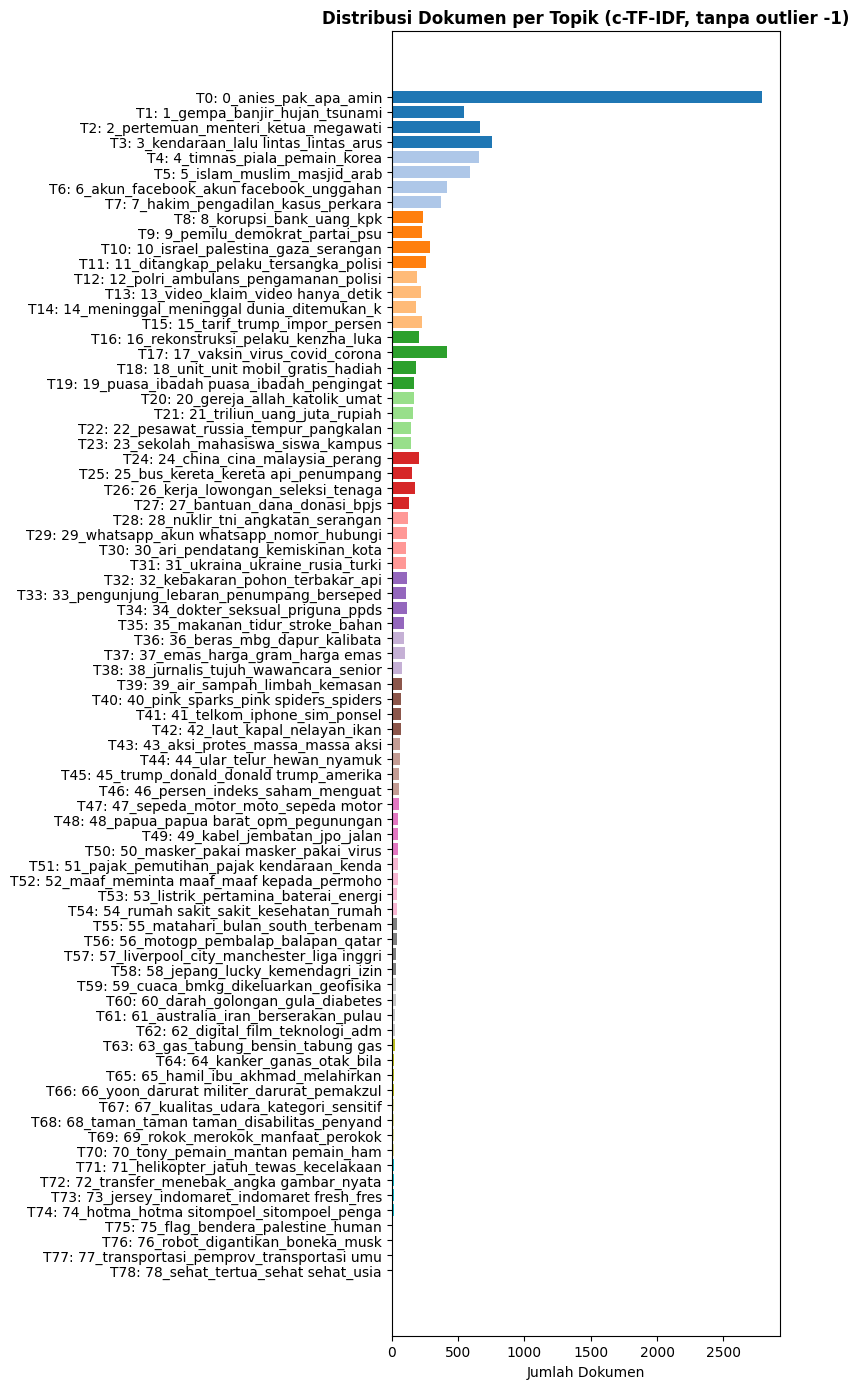

Grafik disimpan: ctfidf_distribusi_topik.png
Topik berlabel Topik Umum: 3/79

  MAPPING: Topic ID → Kategori
  Topic  0 → Politik                             | Top words: anies, pak, apa, amin, semoga
  Topic  1 → Bencana & Cuaca                     | Top words: gempa, banjir, hujan, tsunami, wilayah
  Topic  2 → Nasional & Pemerintahan             | Top words: pertemuan, menteri, ketua, megawati, wakil
  Topic  3 → Transportasi & Infrastruktur        | Top words: kendaraan, lalu lintas, lintas, arus, tol
  Topic  4 → Olahraga                            | Top words: timnas, piala, pemain, korea, megawati
  Topic  5 → Agama & Sosial                      | Top words: islam, muslim, masjid, arab, saudi
  Topic  6 → Klaim & Pemeriksaan Fakta           | Top words: akun, facebook, akun facebook, unggahan, tautan
  Topic  7 → Kriminal & Hukum                    | Top words: hakim, pengadilan, kasus, perkara, suap
  Topic  8 → Kriminal & Hukum                    | Top words: korupsi, bank, ua

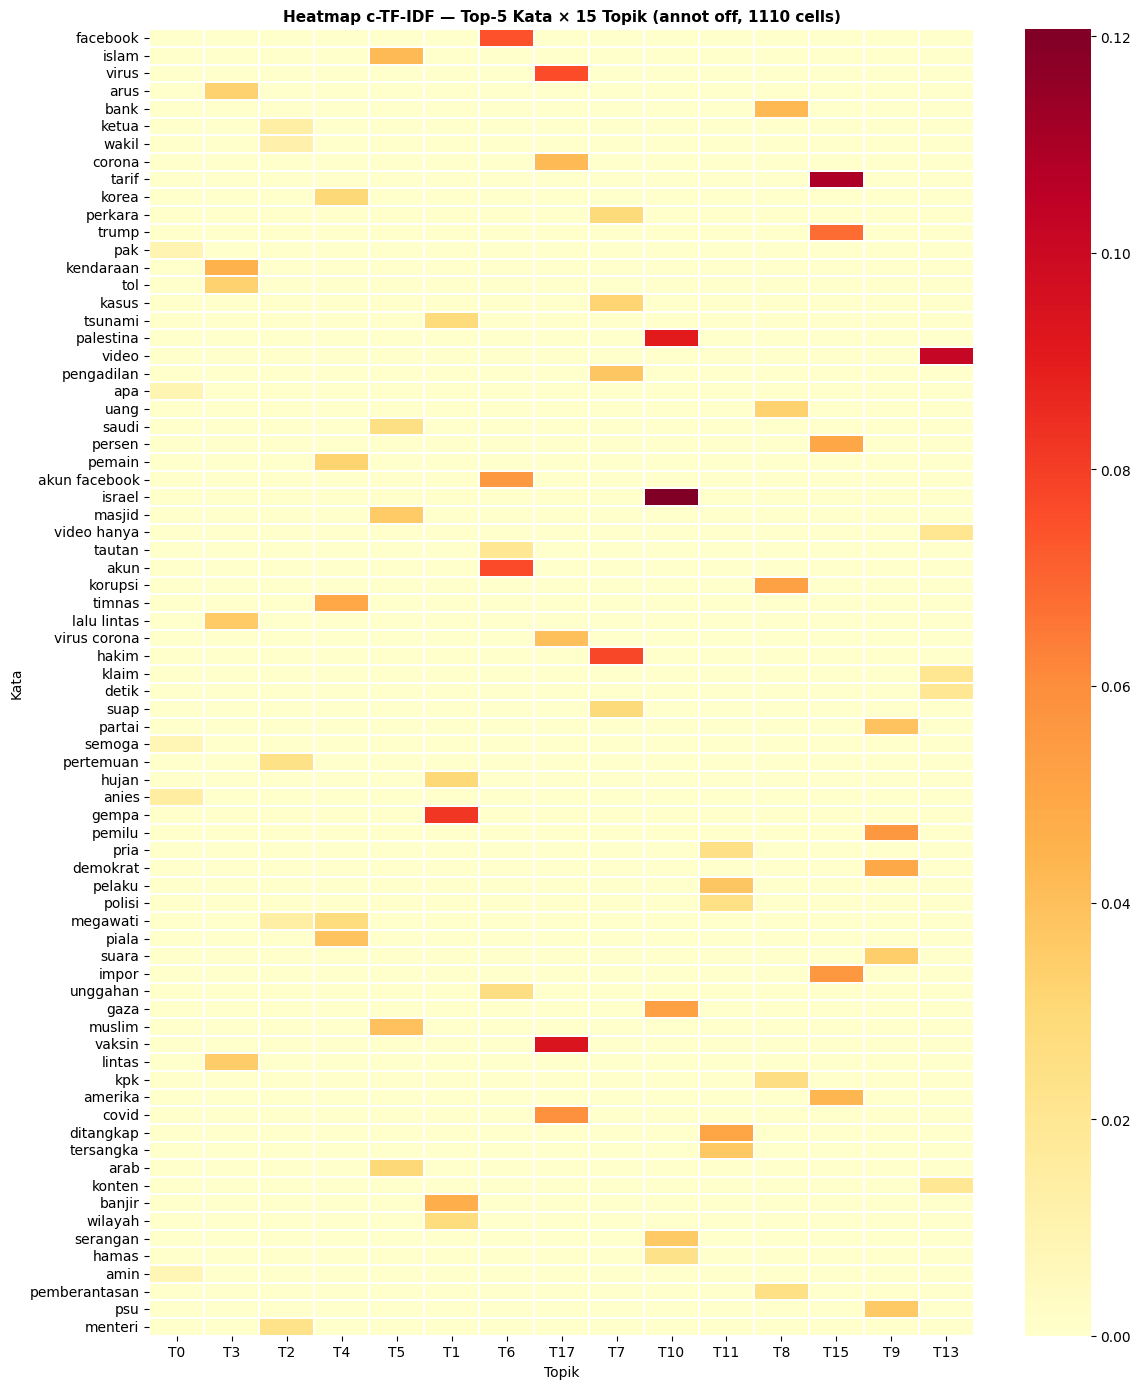

Heatmap c-TF-IDF disimpan: ctfidf_heatmap.png


In [26]:
# ================== SEL 26 -- Evaluasi c-TF-IDF BERTopic (OOM-Safe) ==================
# Menampilkan evaluasi kuantitatif Topic Modeling:
#   1. Statistik topik valid dan outlier -1; Topic 0 tetap topik valid
#   2. Distribusi dokumen per topik
#   3. Kata-kata penting per topik dengan skor c-TF-IDF
#   4. Mapping topik ke kategori berdasarkan keyword overlap dan fallback scoring
#   5. Heatmap c-TF-IDF dengan OOM-safe optimizations
#   6. Export CSV/grafik untuk analisis lebih lanjut
# Kategori mapping menggunakan PETA_KATEGORI_SHARED + KATEGORI_TAMBAHAN_BERTOPIC.
# =======================================================================================
if AKTIFKAN_BERTOPIC and model_topik is not None:
    info_topik      = model_topik.get_topic_info().copy()
    id_topik_arr    = np.array(id_topik)
    info_valid_eval = info_topik[info_topik["Topic"] != -1].copy()
    info_valid_eval_main = info_valid_eval.copy()
    jumlah_topik_valid = len(info_valid_eval_main)
    jumlah_outlier     = int((id_topik_arr == -1).sum())

    print("=" * 65)
    print("  Evaluasi c-TF-IDF BERTopic")
    print("=" * 65)
    print(f"Topik valid utama : {jumlah_topik_valid}")
    print(f"Total dokumen     : {len(dokumen_topik):,}")
    print(f"Dokumen outlier   : {jumlah_outlier:,}  ({jumlah_outlier/len(dokumen_topik)*100:.1f}%)")

    # Distribusi dokumen per topik
    print("\nDistribusi Dokumen per Topik (analisis utama)")
    print(info_valid_eval_main[["Topic", "Count", "Name"]].to_string(index=False))

    tinggi_bar = min(max(4, jumlah_topik_valid * 0.4), 14)
    fig, ax = plt.subplots(figsize=(8, tinggi_bar))
    bar_colors = plt.cm.tab20(np.linspace(0, 1, len(info_valid_eval_main)))
    ax.barh(
        [f"T{r['Topic']}: {str(r['Name'])[:40]}" for _, r in info_valid_eval_main.iterrows()],
        info_valid_eval_main["Count"].values,
        color=bar_colors,
    )
    ax.set_xlabel("Jumlah Dokumen")
    ax.set_title("Distribusi Dokumen per Topik (c-TF-IDF, tanpa outlier -1)", fontweight="bold")
    ax.invert_yaxis(); plt.tight_layout()
    plt.savefig("ctfidf_distribusi_topik.png", dpi=120, bbox_inches="tight")
    plt.show(); plt.close(); gc.collect()
    print("Grafik disimpan: ctfidf_distribusi_topik.png")

    # Mapping Topic ID ke Kategori berdasarkan keyword overlap + fallback scoring ringan
    def buat_mapping_topic_ke_kategori(
        model_topik,
        kategori_nama_list: List[str],
        daftar_tema_utama: List[List[str]],
        min_overlap: int = 1,
        top_n_words: int = 20,
        min_fallback_score: float = 0.02,
        tie_tolerance: float = 1e-9,
    ) -> Dict[int, str]:
        """Map BERTopic topic_id ke kategori terdekat dengan overlap exact + fallback scoring ringan.

        Decision rule:
        1. Exact overlap tetap prioritas utama.
        2. Mapping exact hanya valid jika overlap minimal 2 keyword.
        3. Jika overlap lemah (0 atau 1), gunakan fallback token scoring.
        4. Fallback hanya valid jika skornya cukup kuat; jika tidak, jatuh ke Topik Umum.
        5. Jika kandidat terbaik imbang/ambigu, jatuh ke Topik Umum agar tidak forced mapping.
        """
        info = model_topik.get_topic_info()
        info_valid = info[info["Topic"] != -1].copy()
        overlap_floor = max(1, int(min_overlap))

        kategori_pairs = [
            (nama, set(keywords))
            for nama, keywords in zip(kategori_nama_list, daftar_tema_utama)
        ]
        for nama, keywords in globals().get("KATEGORI_TAMBAHAN_BERTOPIC", {}).items():
            for idx, (nama_existing, keyword_existing) in enumerate(kategori_pairs):
                if nama_existing == nama:
                    kategori_pairs[idx] = (nama_existing, set(keyword_existing) | set(keywords))
                    break
            else:
                kategori_pairs.append((nama, set(keywords)))

        lexicon_per_kategori = []
        for nama_kategori, seed_keywords in kategori_pairs:
            seed_set = {kw.lower().strip() for kw in seed_keywords if str(kw).strip()}
            token_set = {
                token
                for kw in seed_set
                for token in kw.split()
                if token
            }
            lexicon_per_kategori.append({
                "nama": nama_kategori,
                "seed_set": seed_set,
                "token_set": token_set,
            })

        mapping = {}
        for _, row in info_valid.iterrows():
            topic_id = int(row["Topic"])
            top_words = model_topik.get_topic(topic_id)

            if not top_words:
                mapping[topic_id] = "Topik Umum"
                continue

            topic_terms = [
                (w.lower().strip(), float(score))
                for w, score in top_words[:top_n_words]
                if str(w).strip()
            ]

            best_kategori_idx = -1
            best_overlap = 0
            best_overlap_score = 0.0
            overlap_is_tie = False

            for kat_idx, lexicon in enumerate(lexicon_per_kategori):
                overlap_count = 0
                overlap_score = 0.0
                for term, score in topic_terms:
                    if term in lexicon["seed_set"]:
                        overlap_count += 1
                        overlap_score += score

                if (
                    overlap_count > best_overlap
                    or (overlap_count == best_overlap and overlap_score > best_overlap_score + tie_tolerance)
                ):
                    best_overlap = overlap_count
                    best_overlap_score = overlap_score
                    best_kategori_idx = kat_idx
                    overlap_is_tie = False
                elif (
                    overlap_count == best_overlap
                    and abs(overlap_score - best_overlap_score) <= tie_tolerance
                    and overlap_count > 0
                ):
                    overlap_is_tie = True

            if best_kategori_idx != -1 and best_overlap >= overlap_floor and not overlap_is_tie:
                mapping[topic_id] = lexicon_per_kategori[best_kategori_idx]["nama"]
                continue

            best_fallback_idx = -1
            best_fallback_score = 0.0
            fallback_is_tie = False
            for kat_idx, lexicon in enumerate(lexicon_per_kategori):
                fallback_score = 0.0
                for term, score in topic_terms:
                    term_tokens = [token for token in term.split() if token]
                    token_hits = sum(
                        1 for token in term_tokens
                        if token in lexicon["token_set"]
                    )
                    if token_hits > 0:
                        fallback_score += score * token_hits

                if fallback_score > best_fallback_score + tie_tolerance:
                    best_fallback_score = fallback_score
                    best_fallback_idx = kat_idx
                    fallback_is_tie = False
                elif fallback_score > 0 and abs(fallback_score - best_fallback_score) <= tie_tolerance:
                    fallback_is_tie = True

            if best_fallback_idx != -1 and not fallback_is_tie and best_fallback_score >= min_fallback_score:
                mapping[topic_id] = lexicon_per_kategori[best_fallback_idx]["nama"]
            else:
                mapping[topic_id] = "Topik Umum"

        return mapping

    # Buat mapping topik
    kategori_mapping = buat_mapping_topic_ke_kategori(
        model_topik,
        kategori_nama_list,
        daftar_tema_utama,
        min_overlap=1,
        top_n_words=20,
        min_fallback_score=0.02,
    )
    jumlah_topik_umum = sum(1 for kategori in kategori_mapping.values() if kategori == "Topik Umum")
    print(f"Topik berlabel Topik Umum: {jumlah_topik_umum}/{len(kategori_mapping)}")

    print("\n" + "=" * 70)
    print("  MAPPING: Topic ID → Kategori")
    print("=" * 70)
    for topic_id in sorted(kategori_mapping.keys()):
        kategori = kategori_mapping[topic_id]
        top_words = model_topik.get_topic(topic_id) or []
        top_words_str = ", ".join([w for w, _ in top_words[:5]])
        print(f"  Topic {topic_id:2d} → {kategori:35s} | Top words: {top_words_str[:60]}")
    print("=" * 70)

    # Kata penting per topik dengan kategori coverage
    print("\nKata Penting per Topik (Top-10, c-TF-IDF)")

    peta_kategori_keywords = {
        name: set(keywords) for name, keywords in PETA_KATEGORI_SHARED
    }
    for nama, keywords in globals().get("KATEGORI_TAMBAHAN_BERTOPIC", {}).items():
        peta_kategori_keywords.setdefault(nama, set()).update(set(keywords))

    baris_ctfidf = []
    for _, baris_info in info_valid_eval.iterrows():
        t_id = int(baris_info["Topic"])
        nama_topik = str(baris_info["Name"])
        kategori = kategori_mapping.get(t_id, "Topik Umum")
        kata_skor = model_topik.get_topic(t_id) or []

        # Ambil keyword kategori lengkap
        kategori_keywords = peta_kategori_keywords.get(kategori, set())
        kategori_keywords_lower = {kw.lower() for kw in kategori_keywords}

        # Hitung keyword ditemukan di top 10 words
        top_words_list = [str(kata).lower().strip() for kata, _ in kata_skor[:10]]
        top_words_token = {token for kata in top_words_list for token in kata.split() if token}
        keyword_ditemukan = {
            keyword for keyword in kategori_keywords_lower
            if keyword in top_words_list
            or any(token in top_words_token for token in keyword.split())
        }

        # Hitung coverage
        coverage_count = len(keyword_ditemukan)
        total_keyword = len(kategori_keywords)
        coverage_str = f"{coverage_count}/{total_keyword}"

        # String untuk CSV
        keyword_kategori_str = "|".join(sorted(kategori_keywords))
        keyword_ditemukan_str = "|".join(sorted(keyword_ditemukan))

        # Add detail rows untuk setiap kata
        for rank, (kata, skor) in enumerate(kata_skor[:10], start=1):
            baris_ctfidf.append({
                "Topik_ID": t_id,
                "Kategori": kategori,
                "Nama_Topik": nama_topik[:40],
                "Rank": rank,
                "Kata": kata,
                "Skor_cTFIDF": round(float(skor), 6),
                "Keyword_Ditemukan": keyword_ditemukan_str,
                "Coverage": coverage_str,
                "Keyword_Kategori_Lengkap": keyword_kategori_str,
            })
    df_ctfidf = pd.DataFrame(baris_ctfidf)

    df_ctfidf = df_ctfidf[[
        "Topik_ID", "Kategori", "Nama_Topik", "Rank", "Kata", "Skor_cTFIDF",
        "Keyword_Ditemukan", "Coverage", "Keyword_Kategori_Lengkap"
    ]]
    df_ctfidf = df_ctfidf.sort_values(["Topik_ID", "Rank"])

    print(df_ctfidf.head(30).to_string(index=False))
    df_ctfidf.to_csv("evaluasi_ctfidf_topik.csv", index=False, encoding="utf-8-sig")
    del baris_ctfidf
    gc.collect()

    print(f"\nCSV disimpan: evaluasi_ctfidf_topik.csv")
    print(f"  Total baris: {len(df_ctfidf):,}")

    # Heatmap skor c-TF-IDF dengan OOM-safe optimizations
    MAKS_TOPIK_HEATMAP = 15
    if jumlah_topik_valid > 0:
        info_heatmap = info_valid_eval_main.nlargest(MAKS_TOPIK_HEATMAP, "Count")
        top5_per_topik = {}
        for t_id_k in info_heatmap["Topic"].tolist():
            kt = model_topik.get_topic(int(t_id_k)) or []
            top5_per_topik[f"T{t_id_k}"] = {w: float(s) for w, s in kt[:5]}

        semua_kata = list({w for d in top5_per_topik.values() for w in d})[:75]
        n_row = len(semua_kata); n_col = len(top5_per_topik)
        n_cell = n_row * n_col

        df_heatmap = pd.DataFrame(
            {t: [top5_per_topik[t].get(w, 0.0) for w in semua_kata] for t in top5_per_topik},
            index=semua_kata,
        )

        lebar_h = min(max(8, n_col * 0.8), 20)
        tinggi_h = min(max(6, n_row * 0.32), 14)
        aktifkan_annot = n_cell <= 200

        fig, ax = plt.subplots(figsize=(lebar_h, tinggi_h))
        sns.heatmap(
            df_heatmap,
            annot=aktifkan_annot,
            fmt=".4f" if aktifkan_annot else "",
            cmap="YlOrRd",
            linewidths=0.2,
            ax=ax,
            annot_kws={"size": 6} if aktifkan_annot else {},
        )
        judul_note = "" if aktifkan_annot else f" (annot off, {n_cell} cells)"
        ax.set_title(
            f"Heatmap c-TF-IDF — Top-5 Kata × {n_col} Topik{judul_note}",
            fontsize=11, fontweight="bold",
        )
        ax.set_xlabel("Topik"); ax.set_ylabel("Kata")
        plt.tight_layout()
        plt.savefig("ctfidf_heatmap.png", dpi=100, bbox_inches="tight")
        plt.show(); plt.close()

        del df_heatmap, top5_per_topik, semua_kata, info_heatmap
        gc.collect()
        if torch.cuda.is_available(): torch.cuda.empty_cache()
        print(f"Heatmap c-TF-IDF disimpan: ctfidf_heatmap.png")
else:
    print("Model BERTopic belum tersedia, evaluasi c-TF-IDF dilewati.")

In [27]:
# ================== SEL 26b -- Evaluasi Numerik BERTopic Tambahan ==================
# Coherence menilai kualitas representasi kata topik final.
# DBCV menilai validitas density cluster pada embedding UMAP dan label topik final.
# DBCV final dapat negatif tipis; interpretasi dilakukan secara komparatif antar-kandidat.
# ==================================================================================
ringkasan_bertopic_eval: Dict[str, object] = {
    "status": "UNKNOWN",
    "catatan": [],
}

if AKTIFKAN_BERTOPIC and model_topik is not None:
    info_eval = model_topik.get_topic_info().copy()
    id_topik_arr_eval = np.array(id_topik)

    info_non_outlier = info_eval[info_eval["Topic"] != -1].copy()
    info_main = info_non_outlier.copy()
    topik_terbesar = info_main.nlargest(1, "Count") if len(info_main) else pd.DataFrame()
    topik_terbesar_id = int(topik_terbesar.iloc[0]["Topic"]) if len(topik_terbesar) else "UNKNOWN"
    topik_terbesar_count = int(topik_terbesar.iloc[0]["Count"]) if len(topik_terbesar) else 0
    topik_terbesar_rate = (topik_terbesar_count / len(id_topik_arr_eval)) if len(id_topik_arr_eval) else np.nan

    total_dokumen_bertopic = int(len(dokumen_topik)) if "dokumen_topik" in globals() else int(len(id_topik_arr_eval))
    jumlah_outlier_eval = int((id_topik_arr_eval == -1).sum())
    outlier_rate_eval = (jumlah_outlier_eval / total_dokumen_bertopic) if total_dokumen_bertopic else np.nan

    ringkasan_bertopic_eval.update({
        "status": "OK",
        "total_dokumen": total_dokumen_bertopic,
        "jumlah_topik_final": int(len(info_non_outlier)),
        "jumlah_topik_utama": int(len(info_main)),
        "jumlah_outlier": jumlah_outlier_eval,
        "outlier_rate": float(outlier_rate_eval) if not np.isnan(outlier_rate_eval) else "UNKNOWN",
        "topik_terbesar_id": topik_terbesar_id,
        "topik_terbesar_count": topik_terbesar_count,
        "topik_terbesar_rate": float(topik_terbesar_rate) if not np.isnan(topik_terbesar_rate) else "UNKNOWN",
        "coherence_c_v": "UNKNOWN",
        "coherence_status": "UNKNOWN",
        "coherence_dokumen_dipakai": "UNKNOWN",
        "coherence_topik_dipakai": "UNKNOWN",
        "dbcv_score": "UNKNOWN",
        "dbcv_mode": "UNKNOWN",
        "dbcv_status": "UNKNOWN - DBCV belum dihitung",
        "dbcv_titik_dipakai": "UNKNOWN",
        "dbcv_cluster_dipakai": "UNKNOWN",
        "hdbscan_relative_validity": "UNKNOWN",
        "hdbscan_relative_validity_status": "UNKNOWN",
    })

    hdbscan_model_eval = getattr(model_topik, "hdbscan_model", None)
    try:
        nilai_relative = getattr(hdbscan_model_eval, "relative_validity_")
        ringkasan_bertopic_eval.update({
            "hdbscan_relative_validity": float(nilai_relative),
            "hdbscan_relative_validity_status": "OK",
        })
    except Exception as exc:
        ringkasan_bertopic_eval["hdbscan_relative_validity_status"] = f"UNKNOWN - {exc}"

    # Statistik topic representation dari df_ctfidf jika tersedia; fallback ke CSV hasil runtime.
    df_ctfidf_eval = globals().get("df_ctfidf", None)
    if df_ctfidf_eval is None:
        for kandidat_csv in ["evaluasi_ctfidf_topik.csv", "/content/evaluasi_ctfidf_topik.csv"]:
            if os.path.exists(kandidat_csv):
                df_ctfidf_eval = pd.read_csv(kandidat_csv)
                break

    if df_ctfidf_eval is not None and len(df_ctfidf_eval) > 0:
        df_ctfidf_eval = df_ctfidf_eval.copy()
        kata_per_topik = df_ctfidf_eval.groupby("Kata")["Topik_ID"].nunique()
        kata_per_kategori = df_ctfidf_eval.groupby("Kata")["Kategori"].nunique()
        topik_coverage = df_ctfidf_eval.drop_duplicates("Topik_ID")["Coverage"].astype(str)

        def _parse_coverage_ratio(nilai: str):
            if "/" not in nilai:
                return np.nan
            kiri, kanan = nilai.split("/", 1)
            try:
                kiri, kanan = int(kiri), int(kanan)
                return kiri / kanan if kanan else np.nan
            except ValueError:
                return np.nan

        coverage_ratio = topik_coverage.map(_parse_coverage_ratio)
        topik_kategori_eval = df_ctfidf_eval.drop_duplicates("Topik_ID")[["Topik_ID", "Kategori"]]
        ringkasan_bertopic_eval.update({
            "ctfidf_baris": int(df_ctfidf_eval.shape[0]),
            "ctfidf_kolom": int(df_ctfidf_eval.shape[1]),
            "ctfidf_topik_unik": int(df_ctfidf_eval["Topik_ID"].nunique()),
            "ctfidf_kategori_unik": int(df_ctfidf_eval["Kategori"].nunique()),
            "kata_frasa_unik": int(df_ctfidf_eval["Kata"].nunique()),
            "kata_eksklusif_topik": int((kata_per_topik == 1).sum()),
            "topic_exclusivity_rate": float((kata_per_topik == 1).mean()),
            "kata_eksklusif_kategori": int((kata_per_kategori == 1).sum()),
            "category_exclusivity_rate": float((kata_per_kategori == 1).mean()),
            "jumlah_topik_umum": int((topik_kategori_eval["Kategori"] == "Topik Umum").sum()),
            "topik_dengan_keyword_hit": int((coverage_ratio.fillna(0) > 0).sum()),
            "rata_rata_coverage_keyword": float(coverage_ratio.mean()) if coverage_ratio.notna().any() else "UNKNOWN",
        })
    else:
        ringkasan_bertopic_eval["catatan"].append("UNKNOWN: df_ctfidf/evaluasi_ctfidf_topik.csv belum tersedia pada state notebook.")

    # DBCV: evaluasi density cluster pada embedding UMAP menggunakan label topik final.
    try:
        from hdbscan.validity import validity_index

        hdbscan_model_eval = getattr(model_topik, "hdbscan_model", None)
        labels_hdbscan = getattr(hdbscan_model_eval, "labels_", None)
        if labels_hdbscan is None and "hdb_m" in globals():
            labels_hdbscan = getattr(hdb_m, "labels_", None)
        if labels_hdbscan is None:
            raise ValueError("label HDBSCAN tidak tersedia")

        reduced_embeddings = None
        umap_model_eval = getattr(model_topik, "umap_model", None)
        if umap_model_eval is not None and hasattr(umap_model_eval, "embedding_"):
            reduced_embeddings = np.asarray(umap_model_eval.embedding_)
        elif "umap_m" in globals() and hasattr(umap_m, "embedding_"):
            reduced_embeddings = np.asarray(umap_m.embedding_)
        elif "umap_m" in globals() and "emb" in globals():
            reduced_embeddings = np.asarray(umap_m.transform(emb))

        if reduced_embeddings is None:
            raise ValueError("reduced embedding UMAP tidak tersedia")

        labels_hdbscan = np.asarray(labels_hdbscan)
        labels_dbcv = id_topik_arr_eval if len(id_topik_arr_eval) == len(reduced_embeddings) else labels_hdbscan
        labels_dbcv = np.asarray(labels_dbcv)
        if len(reduced_embeddings) != len(labels_dbcv):
            raise ValueError("jumlah reduced embedding dan label DBCV tidak sama")

        DBCV_MAKS_DATA_FULL = 3000
        DBCV_MAKS_DATA_SAMPLE = 3000
        mode_dbcv = "full"
        indeks_dbcv = np.arange(len(labels_dbcv))

        if len(labels_dbcv) > DBCV_MAKS_DATA_FULL:
            mode_dbcv = "sampled"
            rng_dbcv = np.random.default_rng(SEED_BERTOPIC)
            indeks_pilihan = []
            cluster_labels = [lab for lab in np.unique(labels_dbcv) if lab != -1]
            per_cluster = max(5, DBCV_MAKS_DATA_SAMPLE // max(len(cluster_labels), 1))

            for lab in cluster_labels:
                idx_lab = np.flatnonzero(labels_dbcv == lab)
                ambil = min(len(idx_lab), per_cluster)
                if ambil > 0:
                    indeks_pilihan.extend(rng_dbcv.choice(idx_lab, size=ambil, replace=False).tolist())

            sisa = DBCV_MAKS_DATA_SAMPLE - len(indeks_pilihan)
            idx_noise = np.flatnonzero(labels_dbcv == -1)
            if sisa > 0 and len(idx_noise) > 0:
                ambil_noise = min(len(idx_noise), sisa)
                indeks_pilihan.extend(rng_dbcv.choice(idx_noise, size=ambil_noise, replace=False).tolist())

            indeks_pilihan = np.array(sorted(set(indeks_pilihan)), dtype=int)
            if len(indeks_pilihan) > DBCV_MAKS_DATA_SAMPLE:
                indeks_pilihan = np.sort(rng_dbcv.choice(indeks_pilihan, size=DBCV_MAKS_DATA_SAMPLE, replace=False))
            indeks_dbcv = indeks_pilihan

        X_dbcv = np.asarray(reduced_embeddings[indeks_dbcv], dtype=np.float64)
        y_dbcv_raw = np.asarray(labels_dbcv[indeks_dbcv])
        cluster_valid = [lab for lab in np.unique(y_dbcv_raw) if lab != -1]
        if len(cluster_valid) < 2:
            raise ValueError("cluster valid kurang dari 2 setelah filtering/sampling")

        # validity_index lebih aman dengan label cluster kontigu; noise tetap -1.
        label_map = {lab: idx for idx, lab in enumerate(sorted(cluster_valid))}
        y_dbcv = np.array([label_map.get(lab, -1) for lab in y_dbcv_raw], dtype=int)

        skor_dbcv = float(validity_index(X_dbcv, y_dbcv, metric="euclidean"))
        ringkasan_bertopic_eval.update({
            "dbcv_score": skor_dbcv,
            "dbcv_mode": mode_dbcv,
            "dbcv_status": f"OK - DBCV {mode_dbcv} pada reduced embedding UMAP + label topik final",
            "dbcv_titik_dipakai": int(len(y_dbcv)),
            "dbcv_cluster_dipakai": int(len(cluster_valid)),
        })
    except Exception as exc:
        hdbscan_model_eval = getattr(model_topik, "hdbscan_model", None)
        try:
            nilai_relative = getattr(hdbscan_model_eval, "relative_validity_")
            ringkasan_bertopic_eval.update({
                "hdbscan_relative_validity": float(nilai_relative),
                "dbcv_status": f"FALLBACK - DBCV penuh tidak tersedia ({exc}); memakai HDBSCAN relative_validity_",
            })
        except Exception as exc_rel:
            ringkasan_bertopic_eval.update({
                "dbcv_score": "UNKNOWN",
                "dbcv_status": f"UNKNOWN - DBCV tidak dapat dihitung ({exc}); relative_validity_ juga tidak tersedia ({exc_rel})",
            })

    # Coherence c_v: memakai corpus preprocessing BERTopic dan unigram top words agar cocok dengan tokenisasi corpus.
    try:
        from gensim.corpora import Dictionary
        from gensim.models import CoherenceModel

        if "dokumen_topik_clean" not in globals() or not dokumen_topik_clean:
            raise ValueError("dokumen_topik_clean tidak tersedia")

        MAKS_DOKUMEN_COHERENCE = 8000
        docs_coherence = [str(d).split() for d in dokumen_topik_clean if str(d).strip()]
        docs_coherence = [d for d in docs_coherence if d]
        total_docs_coherence = len(docs_coherence)
        if total_docs_coherence > MAKS_DOKUMEN_COHERENCE:
            rng_coh = random.Random(SEED_BERTOPIC)
            idx_sample = sorted(rng_coh.sample(range(total_docs_coherence), MAKS_DOKUMEN_COHERENCE))
            docs_coherence = [docs_coherence[i] for i in idx_sample]

        dictionary_coh = Dictionary(docs_coherence)
        topic_word_lists = []
        for topic_id in info_main["Topic"].tolist():
            kandidat_kata = []
            for kata, _ in (model_topik.get_topic(int(topic_id)) or [])[:15]:
                kata = str(kata).strip().lower()
                if kata and " " not in kata and kata in dictionary_coh.token2id:
                    kandidat_kata.append(kata)
            if len(kandidat_kata) >= 2:
                topic_word_lists.append(kandidat_kata[:10])

        if len(topic_word_lists) < 2:
            raise ValueError("top words unigram yang valid terlalu sedikit")

        coherence_model = CoherenceModel(
            topics=topic_word_lists,
            texts=docs_coherence,
            dictionary=dictionary_coh,
            coherence="c_v",
        )
        coherence_c_v = float(coherence_model.get_coherence())

        ringkasan_bertopic_eval.update({
            "coherence_c_v": coherence_c_v,
            "coherence_status": "OK - dihitung dari unigram top words dan corpus BERTopic terpreproses",
            "coherence_dokumen_dipakai": int(len(docs_coherence)),
            "coherence_topik_dipakai": int(len(topic_word_lists)),
        })
    except Exception as exc:
        ringkasan_bertopic_eval.update({
            "coherence_c_v": "UNKNOWN",
            "coherence_status": f"UNKNOWN - {exc}",
        })

    tabel_bertopic_eval = pd.DataFrame([
        {"Metrik": "Total dokumen BERTopic", "Nilai": ringkasan_bertopic_eval.get("total_dokumen", "UNKNOWN")},
        {"Metrik": "Jumlah topik final (non-outlier)", "Nilai": ringkasan_bertopic_eval.get("jumlah_topik_final", "UNKNOWN")},
        {"Metrik": "Jumlah topik utama", "Nilai": ringkasan_bertopic_eval.get("jumlah_topik_utama", "UNKNOWN")},
        {"Metrik": "Dokumen outlier", "Nilai": ringkasan_bertopic_eval.get("jumlah_outlier", "UNKNOWN")},
        {"Metrik": "Outlier rate", "Nilai": ringkasan_bertopic_eval.get("outlier_rate", "UNKNOWN")},
        {"Metrik": "Topik terbesar", "Nilai": ringkasan_bertopic_eval.get("topik_terbesar_id", "UNKNOWN")},
        {"Metrik": "Dokumen topik terbesar", "Nilai": ringkasan_bertopic_eval.get("topik_terbesar_count", "UNKNOWN")},
        {"Metrik": "Persentase topik terbesar", "Nilai": ringkasan_bertopic_eval.get("topik_terbesar_rate", "UNKNOWN")},
        {"Metrik": "DBCV HDBSCAN", "Nilai": ringkasan_bertopic_eval.get("dbcv_score", "UNKNOWN")},
        {"Metrik": "DBCV mode", "Nilai": ringkasan_bertopic_eval.get("dbcv_mode", "UNKNOWN")},
        {"Metrik": "HDBSCAN relative validity", "Nilai": ringkasan_bertopic_eval.get("hdbscan_relative_validity", "UNKNOWN")},
        {"Metrik": "Status relative validity", "Nilai": ringkasan_bertopic_eval.get("hdbscan_relative_validity_status", "UNKNOWN")},
        {"Metrik": "Coherence c_v", "Nilai": ringkasan_bertopic_eval.get("coherence_c_v", "UNKNOWN")},
        {"Metrik": "Topic exclusivity rate", "Nilai": ringkasan_bertopic_eval.get("topic_exclusivity_rate", "UNKNOWN")},
        {"Metrik": "Keyword coverage rata-rata", "Nilai": ringkasan_bertopic_eval.get("rata_rata_coverage_keyword", "UNKNOWN")},
        {"Metrik": "Jumlah topik Topik Umum", "Nilai": ringkasan_bertopic_eval.get("jumlah_topik_umum", "UNKNOWN")},
    ])
    if "tabel_perbandingan_bertopic" in globals():
        tabel_perbandingan_bertopic_eval = tabel_perbandingan_bertopic.copy()
        nama_final = globals().get("BERTOPIC_OUTLIER_STRATEGY_TERPILIH", "fit_awal_hdbscan")
        mask_final = tabel_perbandingan_bertopic_eval["nama_konfigurasi"] == nama_final
        tabel_perbandingan_bertopic_eval.loc[mask_final, "coherence_c_v"] = ringkasan_bertopic_eval.get("coherence_c_v", "UNKNOWN")
        tabel_perbandingan_bertopic_eval.loc[mask_final, "DBCV"] = ringkasan_bertopic_eval.get("dbcv_score", "UNKNOWN")
        tabel_perbandingan_bertopic_eval.loc[mask_final, "topic_exclusivity"] = ringkasan_bertopic_eval.get("topic_exclusivity_rate", "UNKNOWN")
        tabel_perbandingan_bertopic_eval.loc[mask_final, "keyword_coverage"] = ringkasan_bertopic_eval.get("rata_rata_coverage_keyword", "UNKNOWN")
        tabel_perbandingan_bertopic_eval.loc[mask_final, "jumlah_topik_umum"] = ringkasan_bertopic_eval.get("jumlah_topik_umum", "UNKNOWN")
        print("\nPerbandingan konfigurasi BERTopic:")
        display(tabel_perbandingan_bertopic_eval)
    print("Strategi final BERTopic:", globals().get("BERTOPIC_OUTLIER_STRATEGY_TERPILIH", "UNKNOWN"))
    print("Alasan strategi final:", globals().get("BERTOPIC_ALASAN_STRATEGI_FINAL", "UNKNOWN"))
    display(tabel_bertopic_eval)
    print("Catatan coherence:", ringkasan_bertopic_eval.get("coherence_status", "UNKNOWN"))
    print("Catatan DBCV:", ringkasan_bertopic_eval.get("dbcv_status", "UNKNOWN"))
else:
    ringkasan_bertopic_eval.update({
        "status": "UNKNOWN",
        "catatan": ["UNKNOWN: model_topik belum tersedia atau AKTIFKAN_BERTOPIC=False."],
    })
    print("UNKNOWN: model_topik belum tersedia atau AKTIFKAN_BERTOPIC=False.")



Perbandingan konfigurasi BERTopic:


,nama_konfigurasi,jumlah_topik_valid,jumlah_outlier,outlier_rate,topik_terbesar_id,topik_terbesar_count,persentase_topik_terbesar,coherence_c_v,DBCV,hdbscan_relative_validity,topic_exclusivity,keyword_coverage,jumlah_topik_umum,top_words_topik_terbesar,skor_seleksi,catatan_seleksi,status_seleksi
0,fit_awal_hdbscan,79,7658,0.444767,0,1087,0.063132,0.512869,-0.039258,0.21855,0.919890,0.068254,2,"amin, anies, semoga, trending, semua, pak, cir...",-7.309411,DBCV_negatif_tipis_mendekati_nol,tidak_dipilih
1,reduce_probabilities,79,3771,0.219015,0,2787,0.161865,0.520257,-0.013278,0.21855,0.913889,0.069279,3,"anies, pak, apa, amin, semoga, ganjar, gibran,...",1.982729,outlier_wajar; DBCV_negatif_tipis_mendekati_nol,TERPILIH
2,reduce_embeddings,79,0,0.000000,0,2502,0.145313,0.503777,-0.748805,0.21855,0.895184,0.073368,2,"anies, semoga, pak, amin, gibran, ganjar, raky...",-19.134503,penalti_outlier_0; penalti_dbcv_sangat_negatif,tidak_dipilih


Strategi final BERTopic: reduce_probabilities
Alasan strategi final: Semua kandidat memiliki DBCV negatif atau mendekati nol; strategi reduce_probabilities dipilih karena memberikan kompromi terbaik: outlier berada pada rentang wajar, coherence tertinggi, DBCV paling mendekati nol dibanding kandidat lain, dan tidak memaksa seluruh outlier menjadi topik valid. Strategi final dipilih bukan karena DBCV sudah ideal secara absolut, tetapi karena secara komparatif reduce_probabilities memiliki kombinasi terbaik antara outlier rate, coherence, DBCV, keyword coverage, dan distribusi topik. DBCV bernilai negatif tipis menunjukkan struktur density cluster belum ideal, tetapi kandidat ini tetap dipilih karena menjadi kompromi terbaik dibanding kandidat lain dan tidak menyebabkan outlier 0%.


,Metrik,Nilai
0,Total dokumen BERTopic,17218
1,Jumlah topik final (non-outlier),79
2,Jumlah topik utama,79
3,Dokumen outlier,3771
4,Outlier rate,0.219015
5,Topik terbesar,0
6,Dokumen topik terbesar,2787
7,Persentase topik terbesar,0.161865
8,DBCV HDBSCAN,-0.013278
9,DBCV mode,sampled


Catatan coherence: OK - dihitung dari unigram top words dan corpus BERTopic terpreproses
Catatan DBCV: OK - DBCV sampled pada reduced embedding UMAP + label topik final


In [28]:
# ================== SEL 27 -- Simpan Model BERTopic ke Disk ==================
# Menyimpan model BERTopic dan mengompresi ke format ZIP.
# Format: Safetensors (lebih aman dan cepat dibanding pickle).
# Output: folder model dan ZIP archive untuk unduh lokal; upload Hub berada di cell terpisah dan dinonaktifkan.
# ===========================================================================
if AKTIFKAN_BERTOPIC and model_topik is not None:
    os.makedirs(DIR_OUTPUT_BERTOPIC, exist_ok=True)
    try:
        model_topik.save(DIR_OUTPUT_BERTOPIC, serialization="safetensors")
        print(f"BERTopic disimpan (safetensors) ke: {DIR_OUTPUT_BERTOPIC}")
    except TypeError:
        model_topik.save(DIR_OUTPUT_BERTOPIC)
        print(f"BERTopic disimpan (default) ke: {DIR_OUTPUT_BERTOPIC}")
    path_zip = shutil.make_archive(DIR_OUTPUT_BERTOPIC, "zip", DIR_OUTPUT_BERTOPIC)
    print(f"Zip: {path_zip}  ({os.path.getsize(path_zip)/1e6:.1f} MB)")
else:
    print("Model BERTopic belum tersedia; proses simpan dilewati.")

BERTopic disimpan (safetensors) ke: /content/bertopic_model_v3
Zip: /content/bertopic_model_v3.zip  (0.2 MB)


In [29]:
# ================== SEL 28 -- Demo Inferensi Topik per Paragraf ==================
# Mendemonstrasikan inference topik menggunakan model BERTopic final yang sudah difit.
# Proses:
#   1. Pisahkan teks demo ke paragraf-paragraf
#   2. Embed menggunakan SentenceTransformer
#   3. Prediksi topik untuk setiap paragraf
#   4. Tampilkan ID topik, label topik, dan skor jika tersedia; -1 berarti outlier
# ====================================================================================
import re as _re

REGEX_PARAGRAF_DEMO = _re.compile("(?:\r?\n){2,}")


def pisahkan_paragraf_demo(teks: str) -> List[str]:
    mentah = str(teks).strip()
    if not mentah: return []
    bagian = [p.strip() for p in REGEX_PARAGRAF_DEMO.split(mentah) if p.strip()]
    return bagian if bagian else [mentah]


def label_dari_id_topik(obj_model, t_id: int) -> str:
    if t_id == -1:
        return "Outlier (-1)"
    info  = obj_model.get_topic_info()
    baris = info[info["Topic"] == t_id]
    if len(baris) > 0 and "Name" in baris.columns:
        return str(baris.iloc[0]["Name"])
    kata = obj_model.get_topic(t_id)
    return " / ".join([w for w,_ in kata[:3]]) if kata else "topik_tidak_dikenal"


def skor_dari_prob(pb, t_id: int):
    if pb is None: return None
    if isinstance(pb, np.ndarray):
        if pb.ndim == 0: return float(pb)
        if 0 <= t_id < len(pb): return float(pb[t_id])
        return float(np.max(pb)) if pb.size > 0 else None
    return None


CONTOH_TOPIK = (
    "\nBeredar tautan bantuan tunai yang meminta OTP pengguna.\n\n"
    "Kementerian mengklarifikasi bahwa tautan tersebut palsu "
    "dan meminta warga cek kanal resmi.\n\n"
    "Pengguna lain melaporkan modus serupa berujung pada pencurian akun.\n"
)

if AKTIFKAN_BERTOPIC and model_topik is not None:
    daftar_par = pisahkan_paragraf_demo(CONTOH_TOPIK)
    print(f"Jumlah paragraf: {len(daftar_par)}")

    if daftar_par:
        # Re-init embedder karena sudah dihapus di SEL 24
        _emb_inf = SentenceTransformer(
            MODEL_EMBEDDING_BERTOPIC,
            device="cuda" if torch.cuda.is_available() else "cpu",
        )
        emb_par = _emb_inf.encode(
            daftar_par, batch_size=UKURAN_BATCH_EMBED,
            show_progress_bar=False, convert_to_numpy=True, normalize_embeddings=True,
        )
        del _emb_inf; gc.collect()
        if torch.cuda.is_available(): torch.cuda.empty_cache()

        id_par, prob_par = model_topik.transform(daftar_par, embeddings=emb_par)

        print("\nHasil topik per paragraf:")
        for idx, (teks_p, t_id) in enumerate(zip(daftar_par, id_par)):
            skor  = skor_dari_prob(prob_par[idx] if prob_par is not None else None, t_id)
            lbl   = label_dari_id_topik(model_topik, t_id)
            print(f"  Paragraf {idx}: Topik {t_id} | {lbl} | "
                  f"skor={f'{skor:.4f}' if skor is not None else 'N/A'}")
            print(f"  Teks: {teks_p}\n")
else:
    print("Demo BERTopic dilewati karena model belum di-fit.")

Jumlah paragraf: 3


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-05-14 07:38:22,596 - BERTopic - Dimensionality - Reducing dimensionality of input embeddings.
2026-05-14 07:38:41,224 - BERTopic - Dimensionality - Completed ✓
2026-05-14 07:38:41,225 - BERTopic - Clustering - Approximating new points with `hdbscan_model`
2026-05-14 07:38:41,227 - BERTopic - Probabilities - Start calculation of probabilities with HDBSCAN
2026-05-14 07:38:41,245 - BERTopic - Probabilities - Completed ✓
2026-05-14 07:38:41,246 - BERTopic - Cluster - Completed ✓



Hasil topik per paragraf:
  Paragraf 0: Topik -1 | Outlier (-1) | skor=0.5760
  Teks: Beredar tautan bantuan tunai yang meminta OTP pengguna.

  Paragraf 1: Topik 6 | 6_akun_facebook_akun facebook_unggahan | skor=1.0000
  Teks: Kementerian mengklarifikasi bahwa tautan tersebut palsu dan meminta warga cek kanal resmi.

  Paragraf 2: Topik -1 | Outlier (-1) | skor=0.6543
  Teks: Pengguna lain melaporkan modus serupa berujung pada pencurian akun.



In [30]:
# ================== SEL 29 -- Upload Model ke Hugging Face Hub (Dinonaktifkan) ==================
# Jika diaktifkan manual, prosesnya:
#   1. Autentikasi dengan HF_TOKEN dari Colab Secrets
#   2. Validasi path folder model
#   3. Create repository di HF Hub jika belum ada
#   4. Upload semua file dengan force overwrite untuk update
# Model tersedia di: fjrmhri/deteksi_hoaks_indobert dan fjrmhri/deteksi_hoaks_bertopic
# ====================================================================================
# from huggingface_hub import login, HfApi
# from google.colab import userdata
# import os

# ================= AUTH =================
# token = userdata.get("HF_TOKEN")
# assert token is not None, "HF_TOKEN tidak ditemukan di Colab Secrets"

# login(token=token)
# os.environ["HF_TOKEN"] = token

# api = HfApi()

# ================= PATH =================
# INDOBERT_DIR = "/content/indobert_hoax_model_v3"
# BERTOPIC_DIR = "/content/bertopic_model_v3"

# repo_indobert = "fjrmhri/deteksi_hoaks_indobert"
# repo_bertopic = "fjrmhri/deteksi_hoaks_bertopic"

# ================= VALIDASI PATH =================
# assert os.path.exists(INDOBERT_DIR), "Folder IndoBERT tidak ditemukan!"
# assert os.path.exists(BERTOPIC_DIR), "Folder BERTopic tidak ditemukan!"

# print("Isi IndoBERT:", os.listdir(INDOBERT_DIR))
# print("Isi BERTopic:", os.listdir(BERTOPIC_DIR))

# ================= CREATE REPO =================
# api.create_repo(repo_id=repo_indobert, repo_type="model", exist_ok=True)
# api.create_repo(repo_id=repo_bertopic, repo_type="model", exist_ok=True)

# ================= UPLOAD =================
# print(f"\n[UPLOAD] IndoBERT (force overwrite)...")
# api.upload_folder(
    # folder_path=INDOBERT_DIR,
    # repo_id=repo_indobert,
    # repo_type="model",
    # delete_patterns="*",
    # commit_message="Force update IndoBERT model"
# )

# print(f"\n[UPLOAD] BERTopic (force overwrite)...")
# api.upload_folder(
    # folder_path=BERTOPIC_DIR,
    # repo_id=repo_bertopic,
    # repo_type="model",
    # delete_patterns="*",
    # commit_message="Force update BERTopic model"
# )

# print("\nSemua folder berhasil di-upload!")

In [31]:
# ================== SEL 30 -- Tampilkan Struktur Folder Model ==================
# Menampilkan struktur file dan folder model IndoBERT dan BERTopic dalam format tree.
# Membantu verifikasi bahwa semua file telah tersimpan dengan benar.
# ====================================================================================
import os

def print_tree(start_path, prefix=""):
    if not os.path.exists(start_path):
        print(f"Path tidak ditemukan: {start_path}")
        return

    files = sorted(os.listdir(start_path))

    for i, name in enumerate(files):
        path = os.path.join(start_path, name)
        connector = "└── " if i == len(files) - 1 else "├── "

        print(prefix + connector + name)

        if os.path.isdir(path):
            extension = "    " if i == len(files) - 1 else "│   "
            print_tree(path, prefix + extension)

# ================= RUN =================
print("Struktur IndoBERT:\n")
print(f"/content/indobert_hoax_model_v3")
print_tree("/content/indobert_hoax_model_v3")

print("\n" + "="*50 + "\n")

print("Struktur BERTopic:\n")
print(f"/content/bertopic_model_v3")
print_tree("/content/bertopic_model_v3")

Struktur IndoBERT:

/content/indobert_hoax_model_v3
├── checkpoint-186
│   ├── config.json
│   ├── model.safetensors
│   ├── optimizer.pt
│   ├── rng_state.pth
│   ├── scaler.pt
│   ├── scheduler.pt
│   ├── tokenizer.json
│   ├── tokenizer_config.json
│   ├── trainer_state.json
│   └── training_args.bin
├── checkpoint-279
│   ├── config.json
│   ├── model.safetensors
│   ├── optimizer.pt
│   ├── rng_state.pth
│   ├── scaler.pt
│   ├── scheduler.pt
│   ├── tokenizer.json
│   ├── tokenizer_config.json
│   ├── trainer_state.json
│   └── training_args.bin
├── config.json
├── inference_config.json
├── model.safetensors
├── tokenizer.json
└── tokenizer_config.json


Struktur BERTopic:

/content/bertopic_model_v3
├── config.json
├── topic_embeddings.safetensors
└── topics.json


In [32]:
# ================== SEL 31 -- Download Hasil Analisis dan Visualisasi ==================
# Mengkompresi semua file hasil analisis (grafik PNG dan CSV evaluasi) ke format ZIP.
# Ditambahkan: Menyertakan inference_config.json untuk keperluan deployment.
# Kemudian download file ZIP ke komputer lokal untuk arsip hasil evaluasi.
# =======================================================================================
import os
import zipfile
from google.colab import files

# Nama file zip yang akan dibuat
nama_zip = 'hasil_analisis_hoax.zip'
path_inference_cfg = '/content/indobert_hoax_model_v3/inference_config.json'

# List untuk menampung file yang akan di-zip (PNG dan CSV di root)
files_to_zip = [f for f in os.listdir('/content') if f.endswith(('.png', '.csv'))]

with zipfile.ZipFile(nama_zip, 'w') as zipf:
    # 1. Tambahkan file visualisasi dan tabel
    for file in files_to_zip:
        zipf.write(os.path.join('/content', file), file)
        print(f"Menambahkan ke zip: {file}")

    # 2. Tambahkan inference_config.json jika ada
    if os.path.exists(path_inference_cfg):
        zipf.write(path_inference_cfg, 'inference_config.json')
        print(f"Menambahkan ke zip: inference_config.json")
    else:
        print("Peringatan: inference_config.json tidak ditemukan di folder model.")

if os.path.exists(nama_zip):
    print(f"\nBerhasil membuat {nama_zip}. Memulai unduhan...")
    files.download(nama_zip)
else:
    print("Gagal membuat file ZIP.")

Menambahkan ke zip: ctfidf_distribusi_topik.png
Menambahkan ke zip: confusion_matrix_threshold_optimal_validation.png
Menambahkan ke zip: roc_curve_validation.png
Menambahkan ke zip: roc_curve_test.png
Menambahkan ke zip: distribusi_topik_bertopic.png
Menambahkan ke zip: confusion_matrix_threshold_optimal_test.png
Menambahkan ke zip: confusion_matrix_test.png
Menambahkan ke zip: kalibrasi_threshold_validation.png
Menambahkan ke zip: kurva_training.png
Menambahkan ke zip: topik_per_label.png
Menambahkan ke zip: ctfidf_heatmap.png
Menambahkan ke zip: distribusi_dataset.png
Menambahkan ke zip: confusion_matrix_validation.png
Menambahkan ke zip: evaluasi_ctfidf_topik.csv
Menambahkan ke zip: inference_config.json

Berhasil membuat hasil_analisis_hoax.zip. Memulai unduhan...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [33]:
# ================== SEL 32 -- Ringkasan Angka Evaluasi Akhir ==================
# Ringkasan numerik akhir IndoBERT dan BERTopic.
# IndoBERT dipisahkan antara evaluasi default/argmax dan evaluasi threshold optimal.
# Semua nilai diambil dari variabel runtime hasil eksekusi notebook, bukan angka statis.
# ============================================================================

def _ambil_metrik_eval(nama_obj: str, key: str):
    obj = globals().get(nama_obj)
    if isinstance(obj, dict):
        return obj.get(key, "UNKNOWN")
    return "UNKNOWN"


def _baris_metrik_argmax(split: str, metrik_obj: str, auc_key: str) -> List[Dict[str, object]]:
    return [
        {"Komponen": "IndoBERT", "Mode": "default/argmax", "Split": split, "Metrik": "accuracy", "Nilai": _ambil_metrik_eval(metrik_obj, "eval_accuracy")},
        {"Komponen": "IndoBERT", "Mode": "default/argmax", "Split": split, "Metrik": "precision", "Nilai": _ambil_metrik_eval(metrik_obj, "eval_precision")},
        {"Komponen": "IndoBERT", "Mode": "default/argmax", "Split": split, "Metrik": "recall", "Nilai": _ambil_metrik_eval(metrik_obj, "eval_recall")},
        {"Komponen": "IndoBERT", "Mode": "default/argmax", "Split": split, "Metrik": "f1", "Nilai": _ambil_metrik_eval(metrik_obj, "eval_f1")},
        {"Komponen": "IndoBERT", "Mode": "default/argmax", "Split": split, "Metrik": "weighted_f1", "Nilai": _ambil_metrik_eval(metrik_obj, "eval_f1_weighted")},
        {"Komponen": "IndoBERT", "Mode": "default/argmax", "Split": split, "Metrik": "auc", "Nilai": globals().get(auc_key, "UNKNOWN")},
    ]

ringkasan_indobert_default = pd.DataFrame(
    _baris_metrik_argmax("Validation", "metrik_val", "auc_val")
    + _baris_metrik_argmax("Test", "metrik_test", "auc_test")
    + [
        {"Komponen": "IndoBERT", "Mode": "runtime", "Split": "Runtime", "Metrik": "threshold_default", "Nilai": globals().get("THRESHOLD_DEFAULT", getattr(cfg, "threshold_default", "UNKNOWN"))},
    ]
)

if "ringkasan_threshold_optimal" in globals() and isinstance(ringkasan_threshold_optimal, pd.DataFrame):
    ringkasan_indobert_threshold = ringkasan_threshold_optimal.copy()
else:
    ringkasan_indobert_threshold = pd.DataFrame([{
        "Split": "UNKNOWN",
        "Mode": "threshold_optimal",
        "Threshold": globals().get("THRESHOLD_OPTIMAL", "UNKNOWN"),
        "Accuracy": "UNKNOWN",
        "Precision": "UNKNOWN",
        "Recall": "UNKNOWN",
        "F1": "UNKNOWN",
        "AUC": "UNKNOWN",
        "Catatan": "Jalankan SEL 18 untuk menghitung evaluasi threshold optimal.",
    }])

ringkasan_threshold_runtime = pd.DataFrame([
    {"Komponen": "IndoBERT", "Mode": "runtime", "Split": "Runtime", "Metrik": "threshold_optimal", "Nilai": globals().get("THRESHOLD_OPTIMAL", "UNKNOWN")},
    {"Komponen": "IndoBERT", "Mode": "runtime", "Split": "Runtime", "Metrik": "threshold_default", "Nilai": globals().get("THRESHOLD_DEFAULT", getattr(cfg, "threshold_default", "UNKNOWN"))},
])


def _ambil_bertopic(key: str):
    obj = globals().get("ringkasan_bertopic_eval", {})
    if isinstance(obj, dict):
        return obj.get(key, "UNKNOWN")
    return "UNKNOWN"


def _interpretasi_dbcv(nilai):
    try:
        nilai = float(nilai)
    except Exception:
        return "UNKNOWN - DBCV belum tersedia pada runtime."
    if nilai > 0:
        return "DBCV positif; struktur density clustering lebih baik secara absolut."
    if nilai >= -0.05:
        return "DBCV mendekati nol/negatif tipis; clustering belum ideal secara absolut, tetapi masih layak dibandingkan antar-kandidat."
    return "DBCV negatif; evaluasi perlu dibaca secara komparatif bersama coherence, outlier rate, coverage, dan distribusi topik."

ringkasan_bertopic_akhir = pd.DataFrame([
    {"Komponen": "BERTopic", "Metrik": "total_dokumen", "Nilai": _ambil_bertopic("total_dokumen")},
    {"Komponen": "BERTopic", "Metrik": "jumlah_topik_final_non_outlier", "Nilai": _ambil_bertopic("jumlah_topik_final")},
    {"Komponen": "BERTopic", "Metrik": "jumlah_topik_utama", "Nilai": _ambil_bertopic("jumlah_topik_utama")},
    {"Komponen": "BERTopic", "Metrik": "jumlah_outlier", "Nilai": _ambil_bertopic("jumlah_outlier")},
    {"Komponen": "BERTopic", "Metrik": "outlier_rate", "Nilai": _ambil_bertopic("outlier_rate")},
    {"Komponen": "BERTopic", "Metrik": "topik_terbesar_id", "Nilai": _ambil_bertopic("topik_terbesar_id")},
    {"Komponen": "BERTopic", "Metrik": "topik_terbesar_count", "Nilai": _ambil_bertopic("topik_terbesar_count")},
    {"Komponen": "BERTopic", "Metrik": "topik_terbesar_rate", "Nilai": _ambil_bertopic("topik_terbesar_rate")},
    {"Komponen": "BERTopic", "Metrik": "jumlah_topik_umum", "Nilai": _ambil_bertopic("jumlah_topik_umum")},
    {"Komponen": "BERTopic", "Metrik": "strategi_outlier_final", "Nilai": globals().get("BERTOPIC_OUTLIER_STRATEGY_TERPILIH", "UNKNOWN")},
    {"Komponen": "BERTopic", "Metrik": "dbcv_hdbscan", "Nilai": _ambil_bertopic("dbcv_score")},
    {"Komponen": "BERTopic", "Metrik": "interpretasi_dbcv", "Nilai": _interpretasi_dbcv(_ambil_bertopic("dbcv_score"))},
    {"Komponen": "BERTopic", "Metrik": "dbcv_mode", "Nilai": _ambil_bertopic("dbcv_mode")},
    {"Komponen": "BERTopic", "Metrik": "dbcv_titik_dipakai", "Nilai": _ambil_bertopic("dbcv_titik_dipakai")},
    {"Komponen": "BERTopic", "Metrik": "dbcv_cluster_dipakai", "Nilai": _ambil_bertopic("dbcv_cluster_dipakai")},
    {"Komponen": "BERTopic", "Metrik": "hdbscan_relative_validity", "Nilai": _ambil_bertopic("hdbscan_relative_validity")},
    {"Komponen": "BERTopic", "Metrik": "dbcv_status", "Nilai": _ambil_bertopic("dbcv_status")},
    {"Komponen": "BERTopic", "Metrik": "coherence_c_v", "Nilai": _ambil_bertopic("coherence_c_v")},
    {"Komponen": "BERTopic", "Metrik": "coherence_dokumen_dipakai", "Nilai": _ambil_bertopic("coherence_dokumen_dipakai")},
    {"Komponen": "BERTopic", "Metrik": "coherence_topik_dipakai", "Nilai": _ambil_bertopic("coherence_topik_dipakai")},
    {"Komponen": "BERTopic", "Metrik": "ctfidf_baris", "Nilai": _ambil_bertopic("ctfidf_baris")},
    {"Komponen": "BERTopic", "Metrik": "ctfidf_kolom", "Nilai": _ambil_bertopic("ctfidf_kolom")},
    {"Komponen": "BERTopic", "Metrik": "kata_frasa_unik", "Nilai": _ambil_bertopic("kata_frasa_unik")},
    {"Komponen": "BERTopic", "Metrik": "kata_eksklusif_topik", "Nilai": _ambil_bertopic("kata_eksklusif_topik")},
    {"Komponen": "BERTopic", "Metrik": "topic_exclusivity_rate", "Nilai": _ambil_bertopic("topic_exclusivity_rate")},
    {"Komponen": "BERTopic", "Metrik": "kata_eksklusif_kategori", "Nilai": _ambil_bertopic("kata_eksklusif_kategori")},
    {"Komponen": "BERTopic", "Metrik": "category_exclusivity_rate", "Nilai": _ambil_bertopic("category_exclusivity_rate")},
    {"Komponen": "BERTopic", "Metrik": "topik_dengan_keyword_hit", "Nilai": _ambil_bertopic("topik_dengan_keyword_hit")},
    {"Komponen": "BERTopic", "Metrik": "rata_rata_coverage_keyword", "Nilai": _ambil_bertopic("rata_rata_coverage_keyword")},
])

unknown_rows = []
for sumber, tabel in [
    ("IndoBERT default/argmax", ringkasan_indobert_default),
    ("IndoBERT threshold optimal", ringkasan_indobert_threshold),
    ("BERTopic", ringkasan_bertopic_akhir),
]:
    for _, row in tabel.iterrows():
        nilai = row.get("Nilai", row.get("F1", "UNKNOWN"))
        if isinstance(nilai, str) and nilai.startswith("UNKNOWN"):
            unknown_rows.append({
                "Komponen": sumber,
                "Metrik": row.get("Metrik", row.get("Mode", "UNKNOWN")),
                "Keterangan": nilai,
            })

print("Metrik default/argmax")
display(ringkasan_indobert_default)
print("Metrik threshold optimal")
display(ringkasan_indobert_threshold.drop(columns=["confusion_matrix"], errors="ignore"))
print("Threshold runtime")
display(ringkasan_threshold_runtime)
print("Ringkasan Evaluasi BERTopic")
display(ringkasan_bertopic_akhir)

if unknown_rows:
    print("Metrik UNKNOWN")
    display(pd.DataFrame(unknown_rows))
else:
    print("Tidak ada metrik UNKNOWN pada ringkasan akhir.")


Metrik default/argmax


,Komponen,Mode,Split,Metrik,Nilai
0,IndoBERT,default/argmax,Validation,accuracy,0.995393
1,IndoBERT,default/argmax,Validation,precision,0.998876
2,IndoBERT,default/argmax,Validation,recall,0.991634
3,IndoBERT,default/argmax,Validation,f1,0.995242
4,IndoBERT,default/argmax,Validation,weighted_f1,0.995392
5,IndoBERT,default/argmax,Validation,auc,0.999804
6,IndoBERT,default/argmax,Test,accuracy,0.996748
7,IndoBERT,default/argmax,Test,precision,0.999439
8,IndoBERT,default/argmax,Test,recall,0.993865
9,IndoBERT,default/argmax,Test,f1,0.996644


Metrik threshold optimal


,Split,Mode,Threshold,Accuracy,Precision,Recall,F1,AUC,TP,FP,FN,TN,file_confusion_matrix
0,Validation,threshold_optimal,0.3,0.995935,0.998878,0.992750,0.995804,0.999804,1780,2,13,1895,confusion_matrix_threshold_optimal_validation.png
1,Test,threshold_optimal,0.3,0.996748,0.998880,0.994423,0.996646,0.999817,1783,2,10,1895,confusion_matrix_threshold_optimal_test.png


Threshold runtime


,Komponen,Mode,Split,Metrik,Nilai
0,IndoBERT,runtime,Runtime,threshold_optimal,0.3
1,IndoBERT,runtime,Runtime,threshold_default,0.5


Ringkasan Evaluasi BERTopic


,Komponen,Metrik,Nilai
0,BERTopic,total_dokumen,17218
1,BERTopic,jumlah_topik_final_non_outlier,79
2,BERTopic,jumlah_topik_utama,79
3,BERTopic,jumlah_outlier,3771
4,BERTopic,outlier_rate,0.219015
5,BERTopic,topik_terbesar_id,0
6,BERTopic,topik_terbesar_count,2787
7,BERTopic,topik_terbesar_rate,0.161865
8,BERTopic,jumlah_topik_umum,3
9,BERTopic,strategi_outlier_final,reduce_probabilities


Tidak ada metrik UNKNOWN pada ringkasan akhir.


### Ringkasan Hasil Akhir

Notebook ini menggunakan dataset gabungan dari CNN, Detik, Kompas, dan TurnBackHoax. Setelah pembersihan, data digunakan untuk dua tujuan utama: klasifikasi hoax berbasis IndoBERT dan analisis topik berbasis BERTopic. Jumlah data bersih, jumlah split, dan distribusi label ditampilkan pada cell pipeline serta visualisasi distribusi dataset.

Model IndoBERT dievaluasi dalam dua mode: default/argmax dan threshold optimal. Threshold optimal dipilih berdasarkan F1-score pada validation set dan dapat berubah saat notebook dijalankan ulang. Threshold default tetap disimpan sebagai pembanding runtime di `inference_config.json`.

Pada analisis topik, BERTopic menghasilkan topik valid dengan outlier direpresentasikan sebagai topic `-1`. Topic `0` diperlakukan sebagai topik valid, bukan noise. Strategi outlier reduction final ditentukan oleh logika evaluasi kandidat saat runtime, dengan mempertimbangkan outlier rate, coherence, DBCV, keyword coverage, dan distribusi topik. Kandidat yang memaksa outlier menjadi 0% diberi penalti agar tidak dipilih hanya karena outlier paling kecil.

Artefak teks seperti `ditampilkan`, `breaking`, `traduction`, `traduit`, `sic`, `turnbackhoax`, `mafindo`, dan frasa boilerplate pemeriksaan fakta dibersihkan melalui preprocessing serta stopword khusus BERTopic. Evaluasi topik mencakup distribusi dokumen per topik, coherence, DBCV, `hdbscan_relative_validity`, topic exclusivity, category exclusivity, keyword coverage, jumlah Topik Umum, dan hasil c-TF-IDF.

DBCV diinterpretasikan berdasarkan nilai runtime: nilai positif menunjukkan struktur density clustering lebih baik, sedangkan nilai mendekati nol atau negatif tipis menunjukkan clustering belum ideal secara absolut tetapi tetap dapat dibandingkan antar-kandidat. Outlier tidak ditargetkan menjadi 0% karena pada HDBSCAN/BERTopic outlier dapat merepresentasikan dokumen ambigu atau tidak cukup dekat dengan cluster valid.

Catatan penting: distribusi sumber data masih berpotensi menimbulkan bias sumber karena seluruh data hoax berasal dari TurnBackHoax, sedangkan CNN, Detik, dan Kompas berisi non-hoax. Hal ini perlu diperhatikan saat menginterpretasikan performa model.

Bagian yang sengaja tidak diubah: arsitektur IndoBERT, tokenizer, checkpoint, training loop, split data, threshold selection logic, dataset mentah, evaluasi classifier utama, konfigurasi utama BERTopic, preprocessing BERTopic, stopword artefak, strategi outlier reduction, dan urutan pipeline.
